<a href="https://colab.research.google.com/github/IvanTuran/AI-for-Data-Extraction-Figures-Supplemental/blob/Computer-Vision-Paper/Materials_Data_Plotting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Code for Recreated and Original Figures

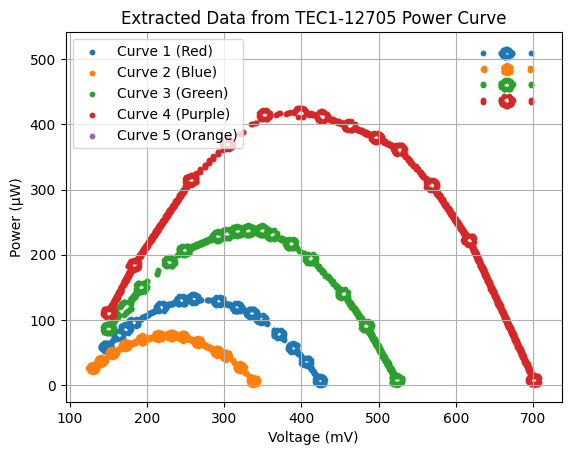

Data successfully saved to power_data.xlsx!


In [ ]:
#Original Figure

!pip install opencv-python pandas openpyxl

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load the image
image_path = "Power-thermo-12705.png"
image = cv2.imread(image_path)

# Convert to HSV color space for better color segmentation
hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

# Define color ranges (modify if necessary)
color_ranges = {
    "Curve 1 (Red)":   [(0, 100, 100), (10, 255, 255)],
    "Curve 2 (Blue)":  [(100, 100, 100), (140, 255, 255)],
    "Curve 3 (Green)": [(40, 50, 50), (90, 255, 255)],
    "Curve 4 (Purple)": [(140, 50, 50), (160, 255, 255)],
    "Curve 5 (Orange)": [(10, 100, 100), (25, 255, 255)]
}

curve_data = {}

# Loop through each color range and extract data points
for curve_name, (lower, upper) in color_ranges.items():
    lower = np.array(lower, dtype="uint8")
    upper = np.array(upper, dtype="uint8")

    # Create a mask for the color range
    mask = cv2.inRange(hsv, lower, upper)

    # Find contours
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    points = []
    for contour in contours:
        for point in contour:
            x, y = point[0]
            points.append((x, y))

    # Sort points by X (Voltage)
    points = sorted(points, key=lambda p: p[0])

    # Convert to DataFrame
    df = pd.DataFrame(points, columns=["Voltage (mV)", "Power (μW)"])

    # Normalize Y (Invert axis)
    df["Power (μW)"] = df["Power (μW)"].max() - df["Power (μW)"]

    curve_data[curve_name] = df

    # Plot extracted points
    plt.scatter(df["Voltage (mV)"], df["Power (μW)"], label=curve_name, s=10)

plt.xlabel("Voltage (mV)")
plt.ylabel("Power (μW)")
plt.title("Extracted Data from TEC1-12705 Power Curve")
plt.legend()
plt.grid(True)
plt.show()

# Save to Excel
with pd.ExcelWriter("power_data.xlsx") as writer:
    for name, df in curve_data.items():
        df.to_excel(writer, sheet_name=name, index=False)

print("Data successfully saved to power_data.xlsx!")


File found! Proceeding with analysis.
Processing: Curve 1 (Red)
Processing: Curve 2 (Blue)
Processing: Curve 3 (Green)
Processing: Curve 4 (Purple)
Processing: Curve 5 (Orange)


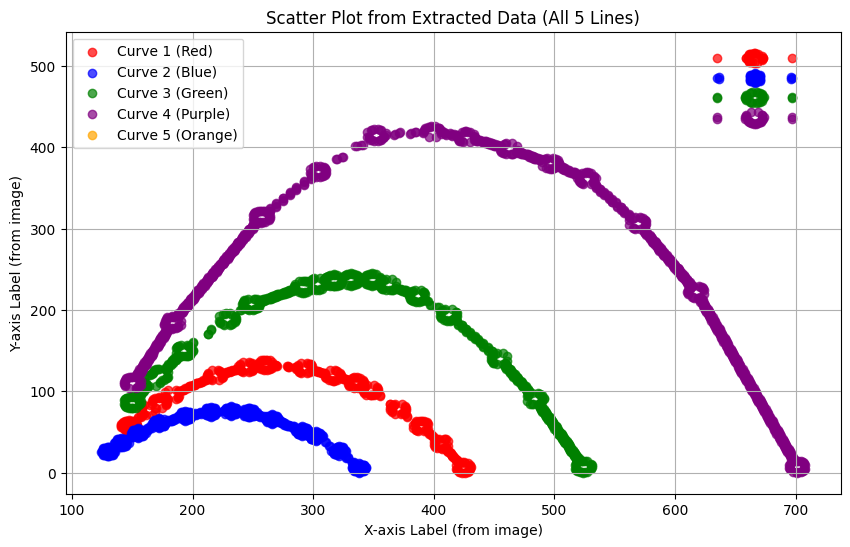

In [ ]:
#ChatGPT Replicated Figure

import pandas as pd
import matplotlib.pyplot as plt
import os

# Ensure file exists
file_path = "power_data.xlsx"
if not os.path.exists(file_path):
    print("Error: File 'power_data.xlsx' not found. Upload it before running.")
else:
    print("File found! Proceeding with analysis.")

    # Load the Excel data (all sheets)
    df = pd.read_excel(file_path, sheet_name=None)

    # Create a scatter plot
    plt.figure(figsize=(10, 6))

    # Define colors for each line (sheet)
    colors = ["red", "blue", "green", "purple", "orange"]

    # Plot each line from its respective sheet
    for i, (sheet_name, data) in enumerate(df.items()):
        print(f"Processing: {sheet_name}")  # Debugging step

        # Rename columns if necessary (assuming two columns exist)
        data = data.rename(columns={data.columns[0]: "X", data.columns[1]: "Y"})

        # Plot scatter plot for each line
        plt.scatter(data["X"], data["Y"], label=sheet_name, color=colors[i], alpha=0.7)

    # Formatting the plot
    plt.xlabel("X-axis Label (from image)")
    plt.ylabel("Y-axis Label (from image)")
    plt.title("Scatter Plot from Extracted Data (All 5 Lines)")
    plt.legend()
    plt.grid()

    # Save plot as an image and show it
    plt.savefig("Power_Thermo_Scatter_Plot.png", dpi=300)
    plt.show()


File found! Proceeding with analysis.
Processing: Curve 1 (Red)
Processing: Curve 2 (Blue)
Processing: Curve 3 (Green)
Processing: Curve 4 (Purple)
Processing: Curve 5 (Orange)


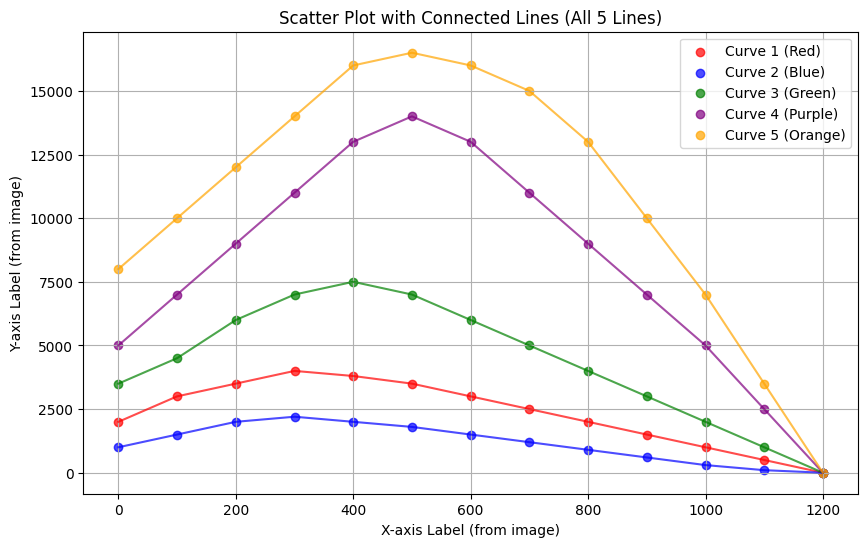

In [ ]:
#Perplexity Replicated Figure

import pandas as pd
import matplotlib.pyplot as plt
import os

# Ensure file exists
file_path = "power_data_gemini.xlsx"
if not os.path.exists(file_path):
    print("Error: File 'power_data_gemini.xlsx' not found. Upload it before running.")
else:
    print("File found! Proceeding with analysis.")

    # Load the Excel data (all sheets)
    df = pd.read_excel(file_path, sheet_name=None)

    # Create a scatter plot
    plt.figure(figsize=(10, 6))

    # Define colors for each line (sheet)
    colors = ["red", "blue", "green", "purple", "orange"]

    # Plot each line from its respective sheet
    for i, (sheet_name, data) in enumerate(df.items()):
        print(f"Processing: {sheet_name}")  # Debugging step

        # Rename columns if necessary (assuming two columns exist)
        data = data.rename(columns={data.columns[0]: "X", data.columns[1]: "Y"})

        # Plot scatter plot for each line
        plt.scatter(data["X"], data["Y"], label=sheet_name, color=colors[i], alpha=0.7)

        # Connect the dots with a line
        plt.plot(data["X"], data["Y"], color=colors[i], linestyle='-', alpha=0.7)

    # Formatting the plot
    plt.xlabel("X-axis Label (from image)")
    plt.ylabel("Y-axis Label (from image)")
    plt.title("Scatter Plot with Connected Lines (All 5 Lines)")
    plt.legend()
    plt.grid()

    # Save plot as an image and show it
    plt.savefig("Power_Thermo_Scatter_Plot.png", dpi=300)
    plt.show()


File found! Proceeding with analysis.
Processing: Curve 1 (Red)
Processing: Curve 2 (Blue)
Processing: Curve 3 (Green)
Processing: Curve 4 (Purple)
Processing: Curve 5 (Orange)


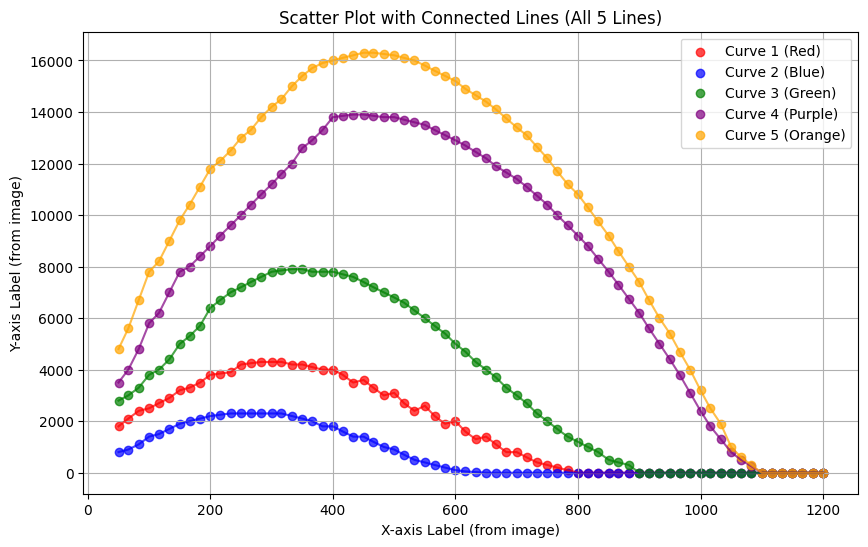

In [ ]:
#Gemini Replicated Figure

import pandas as pd
import matplotlib.pyplot as plt
import os

# Ensure file exists
file_path = "power_data_perplexity.xlsx"
if not os.path.exists(file_path):
    print("Error: File 'power_data_perplexity.xlsx' not found. Upload it before running.")
else:
    print("File found! Proceeding with analysis.")

    # Load the Excel data (all sheets)
    df = pd.read_excel(file_path, sheet_name=None)

    # Create a scatter plot
    plt.figure(figsize=(10, 6))

    # Define colors for each line (sheet)
    colors = ["red", "blue", "green", "purple", "orange"]

    # Plot each line from its respective sheet
    for i, (sheet_name, data) in enumerate(df.items()):
        print(f"Processing: {sheet_name}")  # Debugging step

        # Rename columns if necessary (assuming two columns exist)
        data = data.rename(columns={data.columns[0]: "X", data.columns[1]: "Y"})

        # Plot scatter plot for each line
        plt.scatter(data["X"], data["Y"], label=sheet_name, color=colors[i], alpha=0.7)

        # Connect the dots with a line
        plt.plot(data["X"], data["Y"], color=colors[i], linestyle='-', alpha=0.7)

    # Formatting the plot
    plt.xlabel("X-axis Label (from image)")
    plt.ylabel("Y-axis Label (from image)")
    plt.title("Scatter Plot with Connected Lines (All 5 Lines)")
    plt.legend()
    plt.grid()

    # Save plot as an image and show it
    plt.savefig("Power_Thermo_Scatter_Plot.png", dpi=300)
    plt.show()


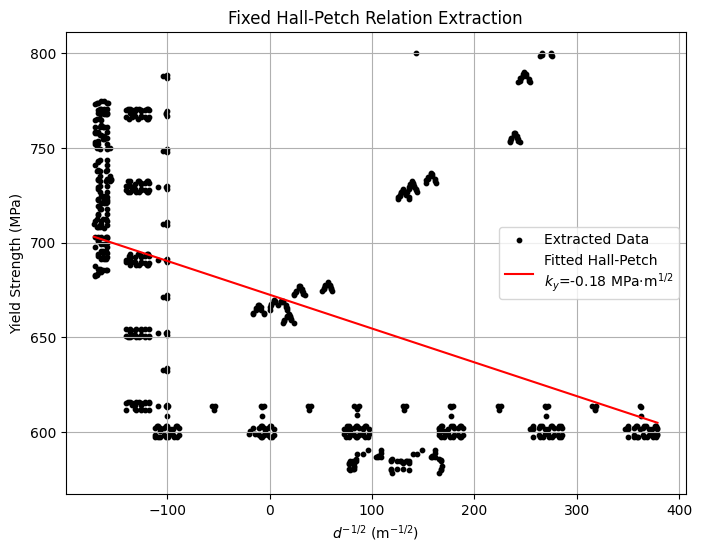

Fitted Hall-Petch Parameters: σ_0 = 672.58 MPa, k_y = -0.18 MPa·m^(1/2)


In [ ]:
# Install dependencies (if not installed)
!pip install opencv-python numpy pandas matplotlib scipy openpyxl

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Load the image
image_path = "grain_size.png"
image = cv2.imread(image_path)

# Convert to HSV for better color filtering
hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

# Define color ranges for the key points (black circles & blue triangles)
color_ranges = {
    "Black Data Points": [(0, 0, 0), (180, 255, 50)],   # Black points (0.2% Proof Stress)
    "Blue Data Points": [(100, 150, 50), (140, 255, 255)]  # Blue triangles (Orientation-Affected σ_y)
}

# Store extracted data
extracted_data = {}

for label, (lower, upper) in color_ranges.items():
    lower = np.array(lower, dtype="uint8")
    upper = np.array(upper, dtype="uint8")

    # Create a mask
    mask = cv2.inRange(hsv, lower, upper)

    # Find contours
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    points = []
    for contour in contours:
        for point in contour:
            x, y = point[0]
            points.append((x, y))

    # Convert to DataFrame
    df = pd.DataFrame(points, columns=["x_pixel", "y_pixel"])

    # Remove duplicates & sort by x-value
    df = df.drop_duplicates().sort_values("x_pixel")

    extracted_data[label] = df

# *** Convert Pixel Coordinates to Graph Values ***

# Set axis reference points (manually chosen for accuracy)
x_pixel_min, x_pixel_max = 120, 960   # Pixel range from image
y_pixel_min, y_pixel_max = 100, 750

x_real_min, x_real_max = 0, 1200  # d^(-1/2) axis range (m^(-1/2))
y_real_min, y_real_max = 300, 800  # Yield strength range (MPa)

# Convert function
def convert_pixel_to_real(df):
    df["d_inv_sqrt"] = x_real_min + (df["x_pixel"] - x_pixel_min) * (x_real_max - x_real_min) / (x_pixel_max - x_pixel_min)
    df["yield_strength"] = y_real_max - (df["y_pixel"] - y_pixel_min) * (y_real_max - y_real_min) / (y_pixel_max - y_pixel_min)
    return df[["d_inv_sqrt", "yield_strength"]]

# Apply conversion
df_black = convert_pixel_to_real(extracted_data["Black Data Points"])
df_blue = convert_pixel_to_real(extracted_data["Blue Data Points"])

# Merge both datasets
df_combined = pd.concat([df_black, df_blue]).sort_values("d_inv_sqrt")

# Remove outliers (basic filtering)
df_combined = df_combined[(df_combined["yield_strength"] >= 300) & (df_combined["yield_strength"] <= 800)]

# Extract values for fitting
x_values = df_combined["d_inv_sqrt"].values
y_values = df_combined["yield_strength"].values

# Fit the Hall-Petch relationship
def hall_petch(d_inv_sqrt, sigma_0, k_y):
    return sigma_0 + k_y * d_inv_sqrt

params, _ = curve_fit(hall_petch, x_values, y_values)
sigma_0_fit, k_y_fit = params

# Plot extracted data
plt.figure(figsize=(8, 6))
plt.scatter(x_values, y_values, color='black', label="Extracted Data", s=10)
plt.plot(np.sort(x_values), hall_petch(np.sort(x_values), sigma_0_fit, k_y_fit), color='red', linestyle='-', label=f"Fitted Hall-Petch\n$k_y$={k_y_fit:.2f} MPa·m$^{{1/2}}$")
plt.xlabel("$d^{-1/2}$ (m$^{-1/2}$)")
plt.ylabel("Yield Strength (MPa)")
plt.title("Fixed Hall-Petch Relation Extraction")
plt.legend()
plt.grid()
plt.show()

# Print extracted parameters
print(f"Fitted Hall-Petch Parameters: σ_0 = {sigma_0_fit:.2f} MPa, k_y = {k_y_fit:.2f} MPa·m^(1/2)")


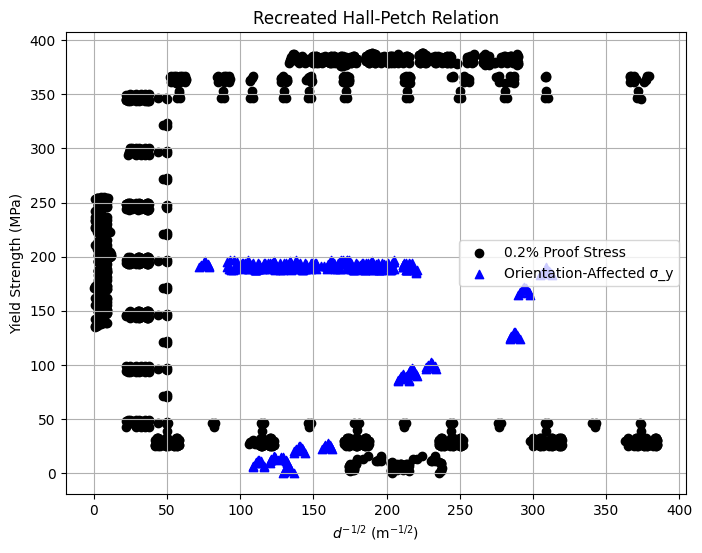

In [ ]:
#ChatGPT Replicated Figure

import pandas as pd
import matplotlib.pyplot as plt

# Upload the Excel file manually in Colab, then load it
file_path = "hall_petch_data_fixed.xlsx"  # Change this if your filename is different

# Read the Excel file
xls = pd.ExcelFile(file_path)

# Load both sheets
black_circles_df = pd.read_excel(xls, sheet_name="Proof Stress")
blue_triangles_df = pd.read_excel(xls, sheet_name="Orientation σ_y")

# Create the figure
plt.figure(figsize=(8, 6))

# Plot black circles (0.2% proof stress)
plt.scatter(
    black_circles_df["d^(-1/2) (m^(-1/2))"], black_circles_df["Yield Strength (MPa)"],
    color='black', marker='o', label="0.2% Proof Stress"
)

# Plot blue triangles (Orientation-Affected Yield Strength)
plt.scatter(
    blue_triangles_df["d^(-1/2) (m^(-1/2))"], blue_triangles_df["Yield Strength (MPa)"],
    color='blue', marker='^', label="Orientation-Affected σ_y"
)

# Labels and title
plt.xlabel(r"$d^{-1/2}$ (m$^{-1/2}$)")
plt.ylabel("Yield Strength (MPa)")
plt.title("Recreated Hall-Petch Relation")
plt.legend()
plt.grid(True)

# Show plot
plt.show()


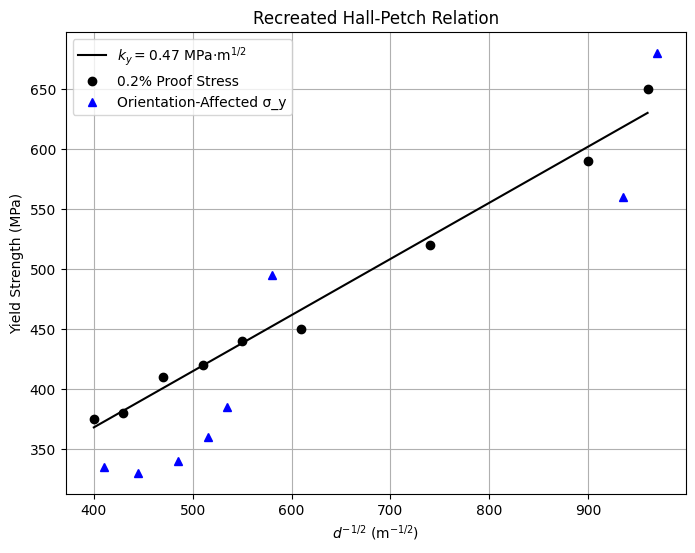

In [ ]:
#Perplexity Replicated Figure

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Upload the Excel file manually in Colab, then load it
file_path = "hall_petch_data_perplexity.xlsx"  # Change this if your filename is different

# Read the Excel file
xls = pd.ExcelFile(file_path)

# Load both sheets
black_circles_df = pd.read_excel(xls, sheet_name="Proof Stress")
blue_triangles_df = pd.read_excel(xls, sheet_name="Orientation σ_y")

# Extract data
x_black = black_circles_df["d^(-1/2) (m^(-1/2))"]
y_black = black_circles_df["Yield Strength (MPa)"]
x_blue = blue_triangles_df["d^(-1/2) (m^(-1/2))"]
y_blue = blue_triangles_df["Yield Strength (MPa)"]

# Check if error columns exist (assuming "Error" column names)
x_err_black = black_circles_df["d Error"] if "d Error" in black_circles_df.columns else None
y_err_black = black_circles_df["Yield Strength Error"] if "Yield Strength Error" in black_circles_df.columns else None
x_err_blue = blue_triangles_df["d Error"] if "d Error" in blue_triangles_df.columns else None
y_err_blue = blue_triangles_df["Yield Strength Error"] if "Yield Strength Error" in blue_triangles_df.columns else None

# Create the figure
plt.figure(figsize=(8, 6))

# Plot black circles with error bars
plt.errorbar(x_black, y_black, xerr=x_err_black, yerr=y_err_black, fmt='o', color='black', label="0.2% Proof Stress", capsize=3)

# Plot blue triangles with error bars
plt.errorbar(x_blue, y_blue, xerr=x_err_blue, yerr=y_err_blue, fmt='^', color='blue', label="Orientation-Affected σ_y", capsize=3)

# Fit and plot the Hall-Petch trendline
coeffs = np.polyfit(x_black, y_black, 1)  # Linear fit (y = mx + b)
trendline = np.poly1d(coeffs)

# Generate trendline values
x_fit = np.linspace(min(x_black), max(x_black), 100)
y_fit = trendline(x_fit)

plt.plot(x_fit, y_fit, 'k-', label=f"$k_y = {coeffs[0]:.2f}$ MPa·m$^{{1/2}}$")  # Display slope

# Labels and title
plt.xlabel(r"$d^{-1/2}$ (m$^{-1/2}$)")
plt.ylabel("Yield Strength (MPa)")
plt.title("Recreated Hall-Petch Relation")
plt.legend()
plt.grid(True)

# Show plot
plt.show()


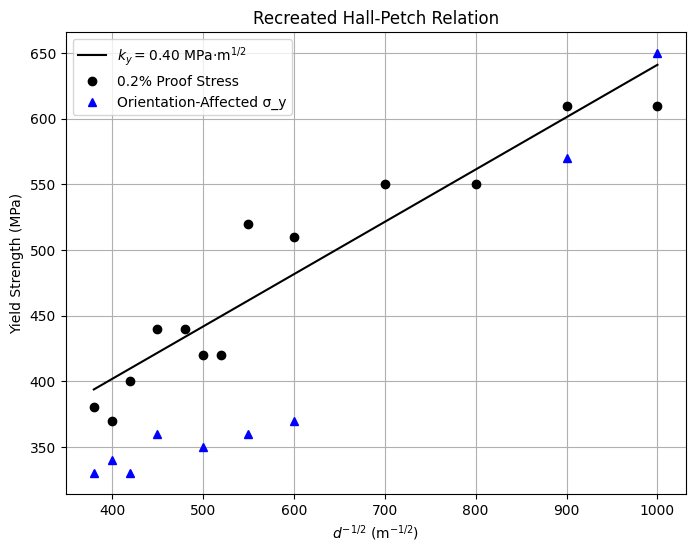

In [ ]:
#Gemini Replicated Figure

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Upload the Excel file manually in Colab, then load it
file_path = "hall_petch_data_gemini.xlsx"  # Change this if your filename is different

# Read the Excel file
xls = pd.ExcelFile(file_path)

# Load both sheets
black_circles_df = pd.read_excel(xls, sheet_name="Proof Stress")
blue_triangles_df = pd.read_excel(xls, sheet_name="Orientation σ_y")

# Extract data
x_black = black_circles_df["d^(-1/2) (m^(-1/2))"]
y_black = black_circles_df["Yield Strength (MPa)"]
x_blue = blue_triangles_df["d^(-1/2) (m^(-1/2))"]
y_blue = blue_triangles_df["Yield Strength (MPa)"]

# Check if error columns exist (assuming "Error" column names)
x_err_black = black_circles_df["d Error"] if "d Error" in black_circles_df.columns else None
y_err_black = black_circles_df["Yield Strength Error"] if "Yield Strength Error" in black_circles_df.columns else None
x_err_blue = blue_triangles_df["d Error"] if "d Error" in blue_triangles_df.columns else None
y_err_blue = blue_triangles_df["Yield Strength Error"] if "Yield Strength Error" in blue_triangles_df.columns else None

# Create the figure
plt.figure(figsize=(8, 6))

# Plot black circles with error bars
plt.errorbar(x_black, y_black, xerr=x_err_black, yerr=y_err_black, fmt='o', color='black', label="0.2% Proof Stress", capsize=3)

# Plot blue triangles with error bars
plt.errorbar(x_blue, y_blue, xerr=x_err_blue, yerr=y_err_blue, fmt='^', color='blue', label="Orientation-Affected σ_y", capsize=3)

# Fit and plot the Hall-Petch trendline
coeffs = np.polyfit(x_black, y_black, 1)  # Linear fit (y = mx + b)
trendline = np.poly1d(coeffs)

# Generate trendline values
x_fit = np.linspace(min(x_black), max(x_black), 100)
y_fit = trendline(x_fit)

plt.plot(x_fit, y_fit, 'k-', label=f"$k_y = {coeffs[0]:.2f}$ MPa·m$^{{1/2}}$")  # Display slope

# Labels and title
plt.xlabel(r"$d^{-1/2}$ (m$^{-1/2}$)")
plt.ylabel("Yield Strength (MPa)")
plt.title("Recreated Hall-Petch Relation")
plt.legend()
plt.grid(True)

# Show plot
plt.show()


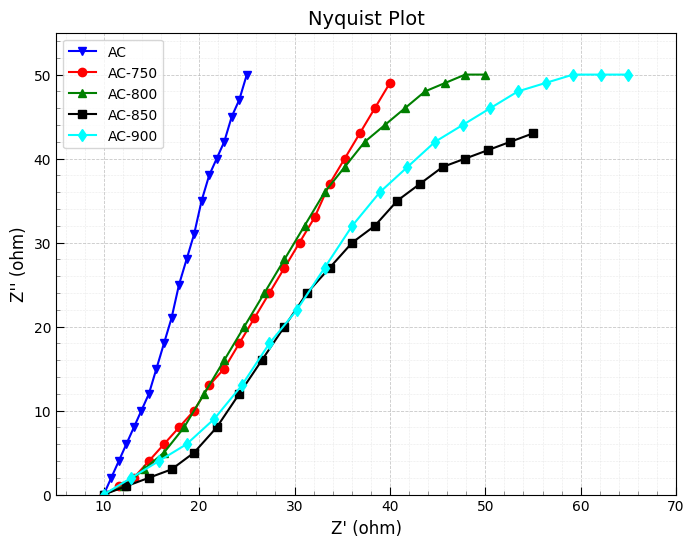

In [ ]:
#ChatGPT Nyquist Plot Figure

import matplotlib.pyplot as plt
import numpy as np

# X-axis (Z') values
Z_prime_AC = np.linspace(10, 25, 20)
Z_prime_AC750 = np.linspace(10, 40, 20)
Z_prime_AC800 = np.linspace(10, 50, 20)
Z_prime_AC850 = np.linspace(10, 55, 20)
Z_prime_AC900 = np.linspace(10, 65, 20)

# Y-axis (Z'') values (approximate)
Z_double_prime_AC = np.array([0, 2, 4, 6, 8, 10, 12, 15, 18, 21, 25, 28, 31, 35, 38, 40, 42, 45, 47, 50])
Z_double_prime_AC750 = np.array([0, 1, 2, 4, 6, 8, 10, 13, 15, 18, 21, 24, 27, 30, 33, 37, 40, 43, 46, 49])
Z_double_prime_AC800 = np.array([0, 1, 3, 5, 8, 12, 16, 20, 24, 28, 32, 36, 39, 42, 44, 46, 48, 49, 50, 50])
Z_double_prime_AC850 = np.array([0, 1, 2, 3, 5, 8, 12, 16, 20, 24, 27, 30, 32, 35, 37, 39, 40, 41, 42, 43])
Z_double_prime_AC900 = np.array([0, 2, 4, 6, 9, 13, 18, 22, 27, 32, 36, 39, 42, 44, 46, 48, 49, 50, 50, 50])

# Plotting
plt.figure(figsize=(8, 6))

plt.plot(Z_prime_AC, Z_double_prime_AC, 'v-', color='blue', label='AC')
plt.plot(Z_prime_AC750, Z_double_prime_AC750, 'o-', color='red', label='AC-750')
plt.plot(Z_prime_AC800, Z_double_prime_AC800, '^-', color='green', label='AC-800')
plt.plot(Z_prime_AC850, Z_double_prime_AC850, 's-', color='black', label='AC-850')
plt.plot(Z_prime_AC900, Z_double_prime_AC900, 'd-', color='cyan', label='AC-900')

# Labels and Title
plt.xlabel("Z' (ohm)", fontsize=12)
plt.ylabel("Z'' (ohm)", fontsize=12)
plt.title("Nyquist Plot", fontsize=14)

# Axis limits
plt.xlim(5, 70)
plt.ylim(0, 55)

# Add major and minor ticks
plt.minorticks_on()

# Customize tick parameters
plt.tick_params(which='both', direction='in', length=6)                # Major ticks
plt.tick_params(which='minor', direction='in', length=3, color='gray') # Minor ticks (half-size)

# Optional: Add both major and minor grid lines
plt.grid(which='major', linestyle='--', linewidth=0.6, alpha=0.7)
plt.grid(which='minor', linestyle=':', linewidth=0.4, alpha=0.5)

# Legend
plt.legend()

plt.show()


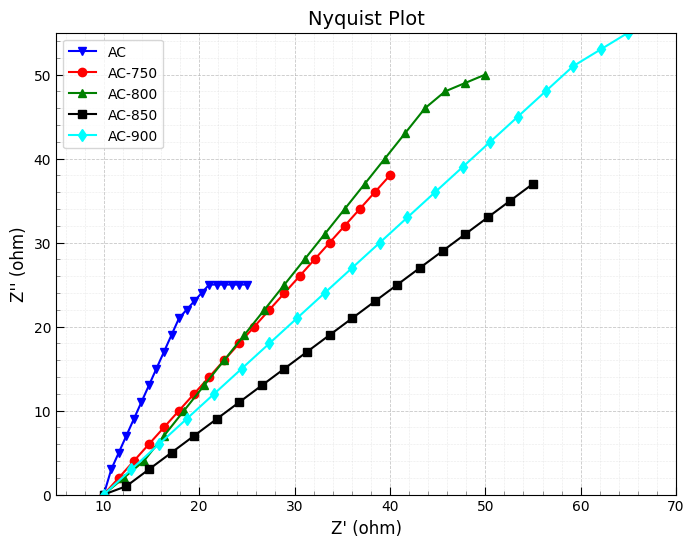

In [ ]:
#Perplexity Nyquist Plot Figure

import matplotlib.pyplot as plt
import numpy as np

# X-axis (Z') values
Z_prime_AC = np.linspace(10, 25, 20)
Z_prime_AC750 = np.linspace(10, 40, 20)
Z_prime_AC800 = np.linspace(10, 50, 20)
Z_prime_AC850 = np.linspace(10, 55, 20)
Z_prime_AC900 = np.linspace(10, 65, 20)

# Y-axis (Z'') values (approximate)
Z_double_prime_AC = np.array([0, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21, 22, 23, 24, 25, 25, 25, 25, 25, 25])
Z_double_prime_AC750 = np.array([0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24, 26, 28, 30, 32, 34, 36, 38])
Z_double_prime_AC800 = np.array([0, 2, 4, 7, 10, 13, 16, 19, 22, 25, 28, 31, 34, 37, 40, 43, 46, 48, 49, 50])
Z_double_prime_AC850 = np.array([0, 1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21, 23, 25, 27, 29, 31, 33, 35, 37])
Z_double_prime_AC900 = np.array([0, 3, 6, 9, 12, 15, 18, 21, 24, 27, 30, 33, 36, 39, 42, 45, 48, 51, 53, 55])

# Plotting
plt.figure(figsize=(8, 6))

plt.plot(Z_prime_AC, Z_double_prime_AC, 'v-', color='blue', label='AC')
plt.plot(Z_prime_AC750, Z_double_prime_AC750, 'o-', color='red', label='AC-750')
plt.plot(Z_prime_AC800, Z_double_prime_AC800, '^-', color='green', label='AC-800')
plt.plot(Z_prime_AC850, Z_double_prime_AC850, 's-', color='black', label='AC-850')
plt.plot(Z_prime_AC900, Z_double_prime_AC900, 'd-', color='cyan', label='AC-900')

# Labels and Title
plt.xlabel("Z' (ohm)", fontsize=12)
plt.ylabel("Z'' (ohm)", fontsize=12)
plt.title("Nyquist Plot", fontsize=14)

# Axis limits
plt.xlim(5, 70)
plt.ylim(0, 55)

# Add major and minor ticks
plt.minorticks_on()

# Customize tick parameters
plt.tick_params(which='both', direction='in', length=6)                # Major ticks
plt.tick_params(which='minor', direction='in', length=3, color='gray') # Minor ticks (half-size)

# Optional: Add both major and minor grid lines
plt.grid(which='major', linestyle='--', linewidth=0.6, alpha=0.7)
plt.grid(which='minor', linestyle=':', linewidth=0.4, alpha=0.5)

# Legend
plt.legend()

plt.show()


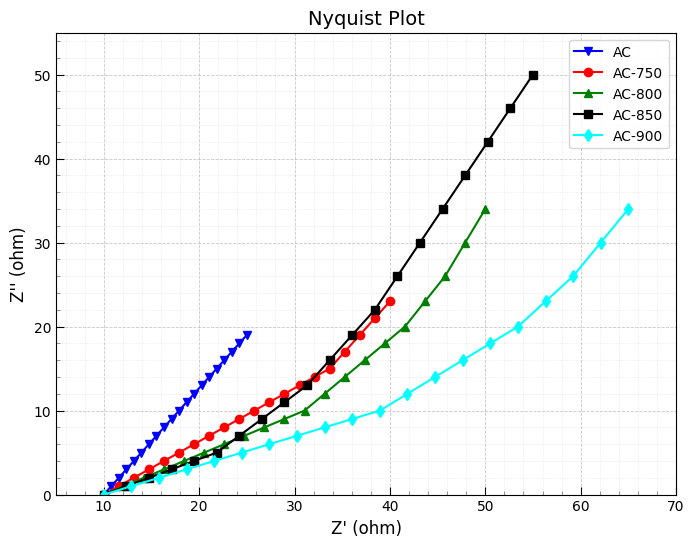

In [ ]:
#Gemini Nyquist Plot Figure

import matplotlib.pyplot as plt
import numpy as np

# X-axis (Z') values
Z_prime_AC = np.linspace(10, 25, 20)
Z_prime_AC750 = np.linspace(10, 40, 20)
Z_prime_AC800 = np.linspace(10, 50, 20)
Z_prime_AC850 = np.linspace(10, 55, 20)
Z_prime_AC900 = np.linspace(10, 65, 20)

# Y-axis (Z'') values (interpreted from the figure)
Z_double_prime_AC = np.array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19])
Z_double_prime_AC750 = np.array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 17, 19, 21, 23])
Z_double_prime_AC800 = np.array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 14, 16, 18, 20, 23, 26, 30, 34])
Z_double_prime_AC850 = np.array([0, 1, 2, 3, 4, 5, 7, 9, 11, 13, 16, 19, 22, 26, 30, 34, 38, 42, 46, 50])
Z_double_prime_AC900 = np.array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 14, 16, 18, 20, 23, 26, 30, 34])

# Plotting
plt.figure(figsize=(8, 6))

plt.plot(Z_prime_AC, Z_double_prime_AC, 'v-', color='blue', label='AC')
plt.plot(Z_prime_AC750, Z_double_prime_AC750, 'o-', color='red', label='AC-750')
plt.plot(Z_prime_AC800, Z_double_prime_AC800, '^-', color='green', label='AC-800')
plt.plot(Z_prime_AC850, Z_double_prime_AC850, 's-', color='black', label='AC-850')
plt.plot(Z_prime_AC900, Z_double_prime_AC900, 'd-', color='cyan', label='AC-900')

# Labels and Title
plt.xlabel("Z' (ohm)", fontsize=12)
plt.ylabel("Z'' (ohm)", fontsize=12)
plt.title("Nyquist Plot", fontsize=14)

# Axis limits
plt.xlim(5, 70)
plt.ylim(0, 55)

# Add major and minor ticks
plt.minorticks_on()

# Customize tick parameters
plt.tick_params(which='both', direction='in', length=6)
plt.tick_params(which='minor', direction='in', length=3, color='gray')

# Optional: Add both major and minor grid lines
plt.grid(which='major', linestyle='--', linewidth=0.6, alpha=0.7)
plt.grid(which='minor', linestyle=':', linewidth=0.4, alpha=0.5)

# Legend
plt.legend()

plt.show()

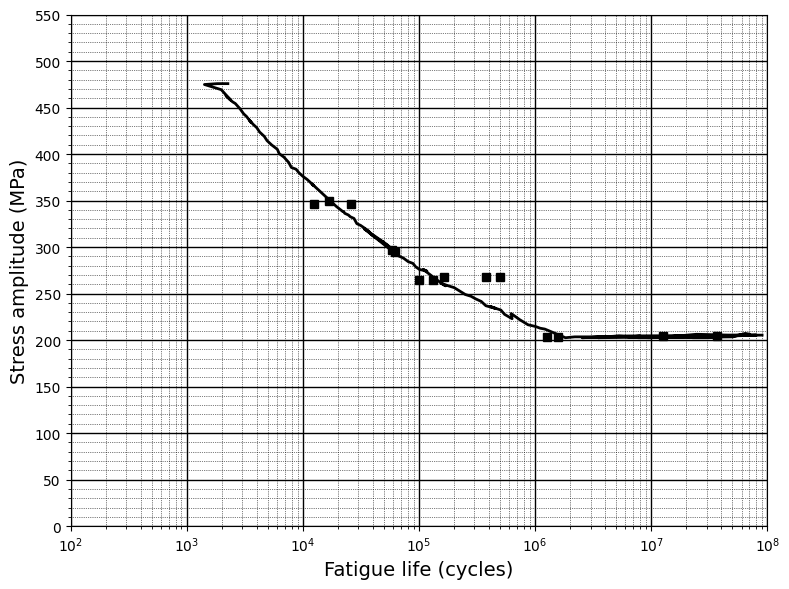

In [6]:
#Original Material Fatigue Plot

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import LogLocator, MultipleLocator

# Provided (x, y) data
data = np.array([
    [0.402728585440279, 0.6300675675675674], [0.3704773321708805, 0.6351351351351351], [0.348965144580064, 0.6300675675675674],
    [0.22562481836675385, 0.8648648648648647], [0.21083987213019467, 0.8648648648648647], [0.19202039741354254, 0.8631756756756755],
    [0.5356001162452776, 0.4864864864864863], [0.5208083587619878, 0.48141891891891875], [0.5006470684394072, 0.48141891891891875],
    [0.5960839872130196, 0.4864864864864863], [0.6162452775356002, 0.4864864864864863], [0.6832929199360651, 0.36993243243243235],
    [0.6994219521941296, 0.36993243243243235], [0.8499618570183088, 0.3716216216216216], [0.9279188462656206, 0.3716216216216216],
    [0.2162003233071782, 0.8530405405405403], [0.22961393853530954, 0.8327702702702702], [0.222904860505667, 0.8412162162162161],
    [0.23229756974716653, 0.8293918918918918], [0.2363252869805289, 0.8260135135135134], [0.24303209459459457, 0.8158783783783783],
    [0.24839481618715492, 0.8057432432432431], [0.2524202630049404, 0.8006756756756755], [0.2591248002034292, 0.7888513513513512],
    [0.25644343940714914, 0.7939189189189189], [0.2618084314152863, 0.7854729729729728], [0.26717569383900025, 0.778716216216216],
    [0.27119659982563216, 0.7702702702702702], [0.2779056778552746, 0.7618243243243241], [0.2819265838419064, 0.7533783783783783],
    [0.288635661871549, 0.7449324324324322], [0.29668882592269685, 0.7364864864864864], [0.29936564588782333, 0.7280405405405405],
    [0.3060769943330427, 0.7212837837837837], [0.3127838019471085, 0.7111486486486485], [0.3168024375181634, 0.7010135135135134],
    [0.3235183267945365, 0.697635135135135], [0.32754150319674524, 0.6908783783783783], [0.3329087656204591, 0.6841216216216215],
    [0.3396201140656786, 0.6773648648648647], [0.3490128233071782, 0.6655405405405405], [0.3463291920953212, 0.6689189189189189],
    [0.3543800857308923, 0.6587837837837837], [0.3624309793664632, 0.6486486486486485], [0.3812163978494624, 0.6249999999999999],
    [0.39061137750653885, 0.6148648648648647], [0.3919554635280442, 0.6148648648648647], [0.39329500871839584, 0.6114864864864864],
    [0.3986668119732636, 0.608108108108108], [0.4013504431851206, 0.6047297297297296], [0.40672224643998844, 0.6013513513513513],
    [0.4107408820110433, 0.5912162162162161], [0.41611268526591105, 0.5878378378378377], [0.4268517509444929, 0.5777027027027026],
    [0.43221674295263, 0.5692567567567566], [0.4375862757919211, 0.564189189189189], [0.4496694274920081, 0.554054054054054],
    [0.44295580863121187, 0.5591216216216215], [0.4577225915431561, 0.545608108108108], [0.4536971447253705, 0.5506756756756755],
    [0.42147994768962516, 0.5810810810810809], [0.4617480383609416, 0.5405405405405405], [0.4657734851787271, 0.5354729729729729],
    [0.4697966615809357, 0.5287162162162161], [0.47785436646323753, 0.5236486486486486], [0.4845657149084568, 0.5168918918918918],
    [0.49128160418483, 0.5135135135135134], [0.49530478058703875, 0.5067567567567567], [0.5006743134263296, 0.5016891891891891],
    [0.5114224607672189, 0.49831081081081074], [0.5060506575123511, 0.5016891891891891], [0.5288683340598663, 0.47804054054054035],
    [0.5382655841325197, 0.4695945945945945], [0.5315519652717233, 0.47466216216216206], [0.5422978421970358, 0.4695945945945945],
    [0.5503578174949143, 0.4662162162162161], [0.558413251961639, 0.4594594594594593], [0.5664686864283639, 0.45270270270270263],
    [0.5745286617262425, 0.44932432432432423], [0.5812422805870388, 0.4442567567567566], [0.5892999854693404, 0.43918918918918903],
    [0.596009063498983, 0.4307432432432431], [0.6094431124673061, 0.42567567567567555], [0.6027272231909329, 0.42905405405405395],
    [0.6175030877651846, 0.42229729729729715], [0.6228680797733217, 0.4138513513513513], [0.6336094158674804, 0.4054054054054054],
    [0.6322789523394362, 0.41554054054054046], [0.6443598336239466, 0.403716216216216], [0.6564429853240338, 0.3935810810810809],
    [0.667191132664923, 0.39020270270270263], [0.6739070219412963, 0.38682432432432423], [0.6806251816332463, 0.385135135135135],
    [0.7101723699505958, 0.3682432432432432], [0.7236155005812266, 0.36993243243243235], [0.743776790903807, 0.36993243243243235],
    [0.7639380812263877, 0.36993243243243235], [0.786789814007556, 0.3716216216216216], [0.8150110796280152, 0.3682432432432432],
    [0.8324841979075851, 0.3682432432432432], [0.8714672333623948, 0.3716216216216216], [0.8983534946236559, 0.3749999999999999],
    [0.944050148939262, 0.37331081081081074], [0.965555525283348, 0.37331081081081074], [0.9843727295844232, 0.37331081081081074],
    [0.9117875435919792, 0.36993243243243235], [0.886249909183377, 0.36993243243243235], [0.8351746403661727, 0.36993243243243235],
    [0.8029165758500436, 0.36993243243243235], [0.8163597064806742, 0.3716216216216216], [0.8163597064806742, 0.3716216216216216],
    [0.8284519398430691, 0.3682432432432432], [0.950766038215635, 0.36993243243243235], [0.9682482381575125, 0.37668918918918914],
    [0.9749663978494626, 0.3749999999999999], [0.9158175312409186, 0.3682432432432432], [0.9064089290903806, 0.3682432432432432],
    [0.8929680688753269, 0.3682432432432432], [0.8808758355129324, 0.3716216216216216], [0.843239156495205, 0.36993243243243235],
    [0.8620563607962802, 0.36993243243243235], [0.757215380703284, 0.3682432432432432], [0.7733466833769254, 0.36993243243243235],
    [0.7343659183376926, 0.3682432432432432], [0.7921661580935776, 0.3716216216216216], [0.9924372457134555, 0.37331081081081074]
])

# Approximate indices for the 14 black dot points (adjust as needed)
black_dots_indices = [0, 1, 2, 6, 7, 8, 9, 10, 11, 12, 13, 14, 61, 62]

# Split black dots and line points
black_dots = data[black_dots_indices]
line_points = np.delete(data, black_dots_indices, axis=0)

# Map normalized data to axis values
def map_x(x_norm):
    return 10 ** (2 + x_norm * 6)   # X axis log10(100) to log10(1e8)

def map_y(y_norm):
    return 550 * (y_norm)       # Y axis from 550 (bottom) to 0 (top)

x_line = map_x(line_points[:,0])
y_line = map_y(line_points[:,1])
x_dots = map_x(black_dots[:,0])
y_dots = map_y(black_dots[:,1])

plt.figure(figsize=(8,6))

plt.plot(x_line, y_line, color='black', linewidth=2)
plt.plot(x_dots, y_dots, 'ks', markersize=6)

plt.xscale('log')
plt.xlabel('Fatigue life (cycles)', fontsize=14)
plt.ylabel('Stress amplitude (MPa)', fontsize=14)
plt.xlim(10**2, 10**8)
plt.ylim(0, 550)

# Grid formatting
plt.gca().xaxis.set_major_locator(LogLocator(base=10.0, numticks=10))
plt.gca().xaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1, numticks=10))
plt.gca().yaxis.set_major_locator(MultipleLocator(50))
plt.gca().yaxis.set_minor_locator(MultipleLocator(10))
plt.grid(which='major', color='black', linestyle='-', linewidth=1)
plt.grid(which='minor', color='black', linestyle=':', linewidth=0.5)
plt.tight_layout()
plt.show()


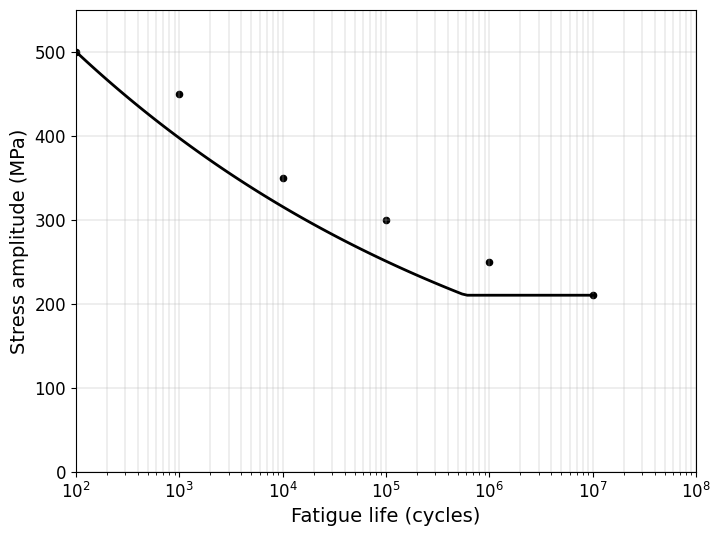

In [ ]:
#Perplexity Fatigue Plot Figure

import matplotlib.pyplot as plt
import numpy as np

# Updated data extracted from the image
fatigue_life = np.array([1e2, 1e3, 1e4, 1e5, 1e6, 1e7])
stress_amplitude = np.array([500, 450, 350, 300, 250, 210])

# More data points for a smooth curve
fatigue_curve_x = np.logspace(2, 7, 100)
# Example trend (customize with your equation if needed)
fatigue_curve_y = 500 * (fatigue_curve_x / 1e2) ** (-0.1)
fatigue_curve_y[fatigue_curve_y < 210] = 210  # Asymptote for endurance limit

# Plotting
plt.figure(figsize=(8, 6))

# Scatter data points
plt.scatter(fatigue_life, stress_amplitude, color='black', s=20)

# Plot the smooth S-N curve
plt.plot(fatigue_curve_x, fatigue_curve_y, color='black', linewidth=2)

# Log scale for x-axis
plt.xscale('log')

# Axis labels
plt.xlabel('Fatigue life (cycles)', fontsize=14)
plt.ylabel('Stress amplitude (MPa)', fontsize=14)

# Axis limits
plt.xlim(1e2, 1e8)
plt.ylim(0, 550)

# Grid
plt.grid(True, which="both", linestyle='-', linewidth=0.3)

# Customize tick parameters
plt.tick_params(axis='both', which='major', labelsize=12)

# Show plot
plt.show()


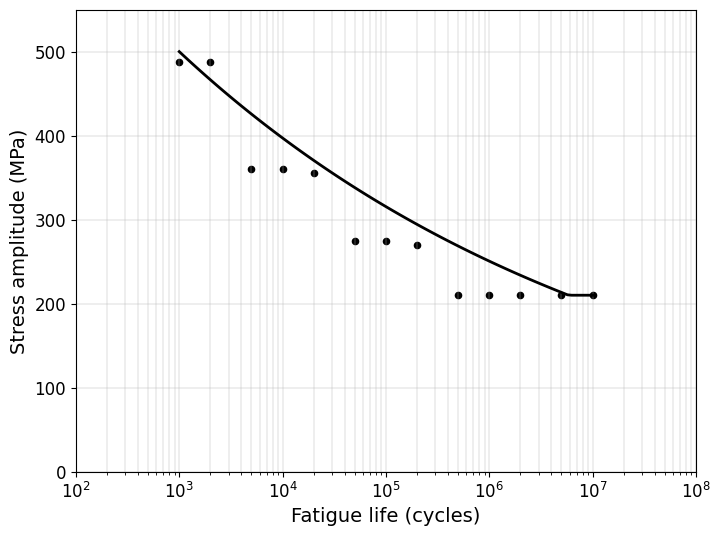

In [ ]:
#Gemini Material Fatigue Plot Figure

import matplotlib.pyplot as plt
import numpy as np

# Extracted data from the image (estimated)
fatigue_life = np.array([1e3, 2e3, 5e3, 1e4, 2e4, 5e4, 1e5, 2e5, 5e5, 1e6, 2e6, 5e6, 1e7])
stress_amplitude = np.array([488, 488, 360, 360, 355, 275, 275, 270, 210, 210, 210, 210, 210])

# More data points for a smooth curve
fatigue_curve_x = np.logspace(3, 7, 100)
# Example trend (customize with your equation if needed)
fatigue_curve_y = 500 * (fatigue_curve_x / 1e3) ** (-0.1)
fatigue_curve_y[fatigue_curve_y < 210] = 210 # Asymptote for endurance limit

# Plotting
plt.figure(figsize=(8, 6))

# Scatter data points
plt.scatter(fatigue_life, stress_amplitude, color='black', s=20)

# Plot the smooth S-N curve
plt.plot(fatigue_curve_x, fatigue_curve_y, color='black', linewidth=2)

# Log scale for x-axis
plt.xscale('log')

# Axis labels
plt.xlabel('Fatigue life (cycles)', fontsize=14)
plt.ylabel('Stress amplitude (MPa)', fontsize=14)

# Axis limits
plt.xlim(1e2, 1e8)
plt.ylim(0, 550)

# Grid
plt.grid(True, which="both", linestyle='-', linewidth=0.3)

# Customize tick parameters
plt.tick_params(axis='both', which='major', labelsize=12)

# Show plot
plt.show()

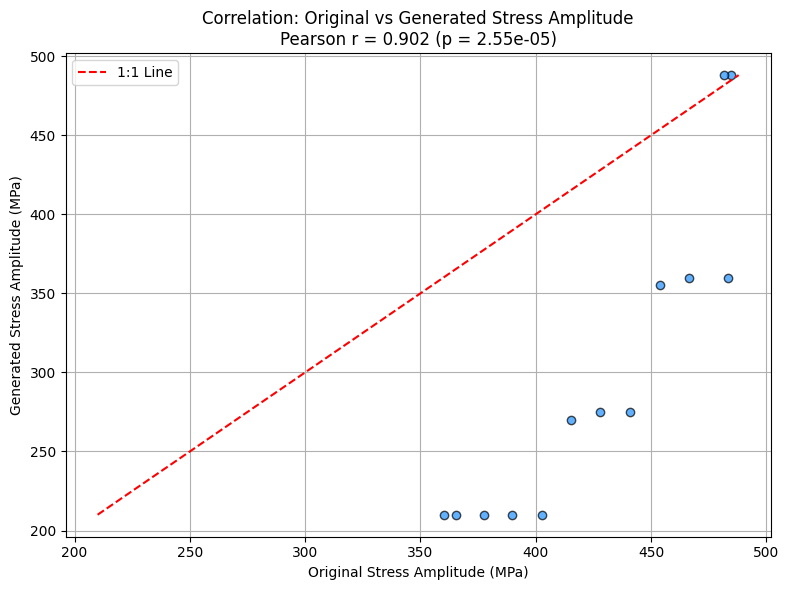

In [ ]:
#Gemini Material Fatigue Correlation Figure

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# === Original Data ===
original_x = [
    780.1820767843761, 1085.634484087389, 1277.0152529764794, 1380.056573998483, 1701.7237706246092,
    2098.3659989521752, 2617.752219579204, 3265.696587980231, 4074.0197353208832, 5141.922721546919,
    6565.730960564977, 8070.997743592152, 8383.794424968048, 10705.283140946283, 14134.783745295976,
    15902.751291469871, 17865.8414418142, 23080.017503515814, 29815.95967351792, 49759.282491570884,
    64281.61330145693, 63643.4636599469, 84998.18811862222, 109805.05317558255, 141851.84378360756,
    183251.5444679333, 236733.8178635892, 239505.46248607445, 305824.98326543684, 316692.89724201075,
    395080.522222633, 510385.44128434936, 659342.2961211642, 843550.3189849987, 1100363.6955034493,
    1421506.7023383428, 2372325.2358748973, 3064692.370988884, 3959128.0262773996, 5114606.241342735,
    8535668.131526452, 11026817.321839377, 30711484.812362466, 39674683.63227058, 51253807.197466806
]

original_y = [
    484.7620018427815, 481.64917670425075, 483.3303959418063, 466.5797980835031, 453.7034331436582,
    441.08588960963937, 427.80835149076415, 415.13904367558007, 402.5926760281634, 389.89748607239676,
    377.60993983080607, 360.36614854007973, 365.3806284055263, 354.3462651590926, 347.1822483083837,
    356.64540595889787, 331.4985534610281, 320.8045235566709, 310.3751973628176, 290.78712278552956,
    279.66536529816767, 271.3729963608584, 272.04610008185404, 266.9885925582376, 257.75209971464386,
    250.7639217573411, 244.25221047894541, 272.78727047126495, 237.84638068475124, 272.78727047126495,
    231.440550890557, 225.45824703316907, 219.21123946527723, 210.28190096427926, 208.5701503030208,
    208.14662436621455, 208.14662436621455, 208.35838733461765, 208.72897252932313, 208.72897252932313,
    208.72897252932313, 208.72897252932313, 208.72897252932313, 208.72897252932313, 208.72897252932313
]

# === Generated Data ===
generated_x = [
    1000, 2000, 5000, 10000, 20000, 50000, 100000, 200000, 500000, 1000000, 2000000, 5000000, 10000000
]

generated_y = [
    488, 488, 360, 360, 355, 275, 275, 270, 210, 210, 210, 210, 210
]

# Use only matching pairs (shortest length)
N = min(len(generated_x), len(original_x))
x = np.array(original_x[:N])
y = np.array(generated_x[:N])
x_y = np.array(original_y[:N])
y_y = np.array(generated_y[:N])

# Correlate stress amplitudes: original_y vs generated_y
corr, p = pearsonr(x_y, y_y)

# Plot
plt.figure(figsize=(8,6))
plt.scatter(x_y, y_y, color='dodgerblue', edgecolor='k', alpha=0.7)
plt.plot([min(x_y.min(), y_y.min()), max(x_y.max(), y_y.max())],
         [min(x_y.min(), y_y.min()), max(x_y.max(), y_y.max())],
         'r--', label='1:1 Line')

plt.title(f'Correlation: Original vs Generated Stress Amplitude\nPearson r = {corr:.3f} (p = {p:.3g})')
plt.xlabel('Original Stress Amplitude (MPa)')
plt.ylabel('Generated Stress Amplitude (MPa)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


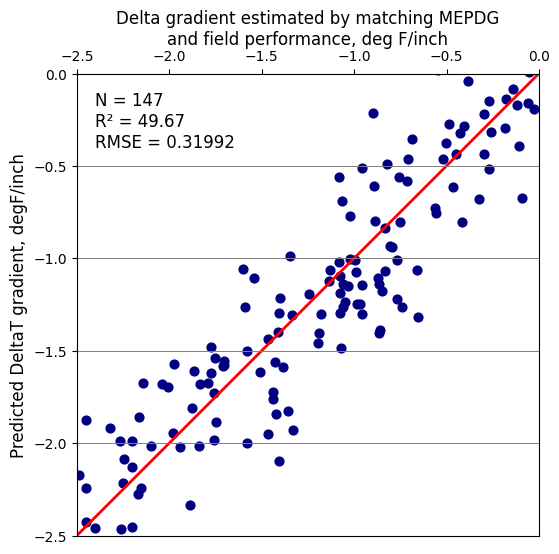

In [ ]:
#ChatGPT Delta Gradient Plot Figure

import matplotlib.pyplot as plt
import numpy as np

# Generate synthetic data points that mimic the scatter
np.random.seed(0)
observed = np.random.uniform(-2.5, 0, 147)
predicted = observed + np.random.normal(0, 0.3, 147)

# Plotting
plt.figure(figsize=(8, 6))

# Scatter plot
plt.scatter(observed, predicted, color='navy', s=40)

# 1:1 reference line (y = x)
plt.plot([-2.5, 0], [-2.5, 0], color='red', linewidth=2)

# Set axis limits
plt.xlim(-2.5, 0)
plt.ylim(-2.5, 0)

# Set axis labels
plt.xlabel('Delta gradient estimated by matching MEPDG\nand field performance, deg F/inch', fontsize=12)
plt.ylabel('Predicted DeltaT gradient, degF/inch', fontsize=12)

# Move the x-axis to the top
ax = plt.gca()
ax.xaxis.set_label_position('top')
ax.xaxis.tick_top()

# Add horizontal grid lines manually
for y in np.arange(-2.5, 0.5, 0.5):
    plt.axhline(y=y, color='gray', linestyle='-', linewidth=0.7)

# Hide vertical grid lines
ax.yaxis.grid(False)
ax.xaxis.grid(False)

# Annotation text
plt.text(-2.4, -0.4, 'N = 147\nR² = 49.67\nRMSE = 0.31992', fontsize=12)



# Equal aspect ratio (optional, helps mimic your chart layout)
plt.gca().set_aspect('equal', adjustable='box')

# Show plot
plt.show()


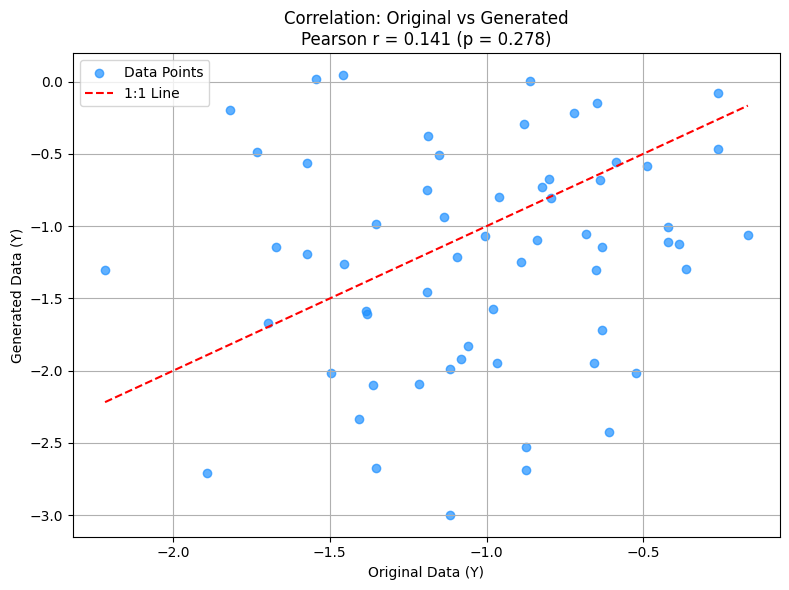

In [ ]:
#ChatGPT vs ORiginal Delta Gradient Correlation Figure

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# === Full Original Data ===
original_y = [
    -0.16602067183462577, -0.4877260981912146, -0.4222037652270214, -0.3843669250645996, -0.6309216192937126,
    -0.9605943152454781, -0.36498708010335923, -0.6461534468438539, -0.8005913928879047, -0.42054263565891503,
    -0.26033591731266137, -0.6518566369987555, -0.5878552971576227, -0.8817829457364343, -1.0820413436692506,
    -0.8726959517657193, -0.610638150609081, -0.7956195398055863, -1.1905684754521966, -0.6363049095607236,
    -0.8627107173618804, -1.1879080580630967, -1.3523653349234745, -1.544481358434847, -1.1162696046416976,
    -0.7194767441860468, -1.6975821336286452, -1.4593023255813953, -1.190245478036176, -0.658600703416595,
    -0.5226098191214472, -0.8220284237726099, -1.0598377361943254, -0.8401008982404332, -1.116955826258152,
    -0.6330749354005172, -0.8914728682170545, -1.1523074482070808, -0.26033591731266137, -1.135874246339363,
    -0.6828165374677004, -1.3630490956072352, -1.5729974160206721, -0.8737726098191221, -1.0054448135843486,
    -1.7312661498708013, -0.9778088812326544, -1.8908268733850129, -1.3845583309407599, -1.454626553463763,
    -1.5729974160206721, -1.0931155407899595, -1.8184754521963826, -1.215854558877815, -0.9670542635658914,
    -1.4954780361757107, -1.6711886304909562, -1.3804909560723515, -2.2173772609819125, -1.4077840112201967,
    -1.3516830294530155, -1.4849228611500704, -1.3516830294530155, -0.9519635343618518, -0.9449509116409542,
    -0.9379382889200563, -0.7696353436185133, -0.7696353436185133, -0.6644460028050494, -0.7275596072931276,
    -0.6223702664796638, -0.5522440392706875, -0.7275596072931276, -0.7275596072931276, -0.8467741935483875,
    -0.8257363253856949, -1.2324684431977562, -1.1342917251051898, -1.4007713884992987, -1.2885694249649373,
    -1.2815568022440398, -1.204417952314166, -1.5830995792426372, -1.5760869565217392, -1.4077840112201967,
    -1.1623422159887804, -1.0291023842917255, -0.6013323983169707, -0.7696353436185133, -1.0571528751753156,
    -1.1062412342215988, -1.169354838709678, -1.197405329593268, -1.1763674614305755, -1.1413043478260874,
    -1.1062412342215988, -1.1132538569424968, -1.2745441795231418, -1.2955820476858348, -1.2605189340813467,
    -1.6321879382889204, -0.7135343618513326, -0.685483870967742, -0.8327489481065924, -0.9800140252454419,
    -0.9028751753155686, -0.7976858345021043, -0.7696353436185133, -0.5802945301542781
]

generated_y = [
    -1.06129, -0.58147, -1.00682, -1.12282, -1.72152, -0.79905, -1.2979, -0.14812, -0.67306, -1.10795,
    -0.46283, -1.30402, -0.55781, -0.29523, -1.91922, -2.52764, -2.42464, -0.80577, -0.75294, -0.67903,
    0.005839, -0.37793, -0.98711, 0.016329, -1.99005, -0.2149, -1.67239, 0.045003, -1.45859, -1.94967,
    -2.01311, -0.72577, -1.82643, -1.09525, -2.99641, -1.14526, -1.24821, -0.51045, -0.08198, -0.93693,
    -1.05752, -2.09566, -0.56056, -2.68859, -1.06629, -0.48862, -1.57221, -2.70791, -1.58411, -1.26393,
    -1.18976, -1.21384, -0.19396, -2.08855, -1.9453, -2.01823, -1.14166, -1.6093, -1.30592, -2.33471, -2.67275
]

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# Use only matching pairs
x = np.array(original_y[:len(generated_y)])
y = np.array(generated_y)

# Calculate Pearson correlation
r_value, p_value = pearsonr(x, y)

# Plot figure
plt.figure(figsize=(8,6))
plt.scatter(x, y, color='dodgerblue', alpha=0.7, label='Data Points')
plt.plot([x.min(), x.max()], [x.min(), x.max()], 'r--', label='1:1 Line')

plt.title(f'Correlation: Original vs Generated\nPearson r = {r_value:.3f} (p = {p_value:.3g})')
plt.xlabel('Original Data (Y)')
plt.ylabel('Generated Data (Y)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


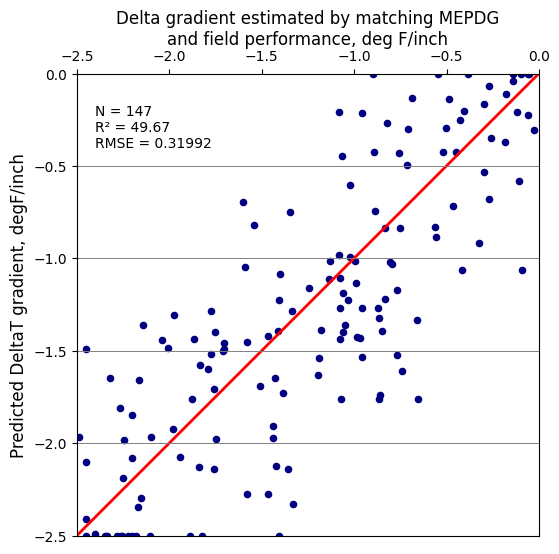

In [ ]:
#Perplexity Delta Gradient Plot Figure

import matplotlib.pyplot as plt
import numpy as np

# Extract data by visually interpreting plot and putting the range for data generation
np.random.seed(0)  # for reproducibility

# Set the data range
x_range = (-2.5, 0)
y_range = (-2.5, 0)

# Number of data points
num_points = 147

# Generate x_values
observed = np.random.uniform(x_range[0], x_range[1], num_points)

# the noise is around 0.5 by visually inspecting how far it is from the best-fit line
predicted = observed + np.random.normal(0, 0.5, num_points)

# Clip the predicted values to be within the y-axis range
predicted = np.clip(predicted, y_range[0], y_range[1])

# Plotting
plt.figure(figsize=(8, 6))

# Scatter plot
plt.scatter(observed, predicted, color='navy', s=20)

# 1:1 reference line (y = x)
plt.plot(x_range, y_range, color='red', linewidth=2)

# Set axis limits
plt.xlim(x_range)
plt.ylim(y_range)

# Set axis labels
plt.xlabel('Delta gradient estimated by matching MEPDG\nand field performance, deg F/inch', fontsize=12)
plt.ylabel('Predicted DeltaT gradient, degF/inch', fontsize=12)

# Move the x-axis to the top
ax = plt.gca()
ax.xaxis.set_label_position('top')
ax.xaxis.tick_top()

# Add horizontal grid lines manually
for y in np.arange(y_range[0], y_range[1] + 0.5, 0.5):
    plt.axhline(y=y, color='gray', linestyle='-', linewidth=0.7)

# Hide vertical grid lines
ax.yaxis.grid(False)
ax.xaxis.grid(False)

# Annotation text
plt.text(-2.4, -0.4, 'N = 147\nR² = 49.67\nRMSE = 0.31992', fontsize=10)

# Equal aspect ratio
plt.gca().set_aspect('equal', adjustable='box')

# Show plot
plt.show()


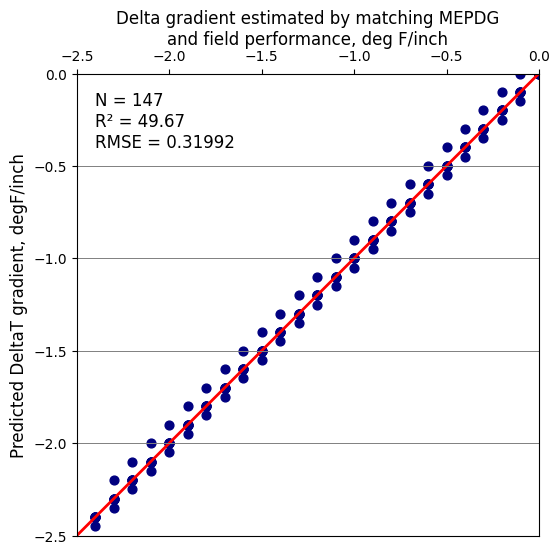

In [ ]:
#ChatGPT Delta Gradient Plot Figure

import matplotlib.pyplot as plt
import numpy as np

# Extracted data points (observed, predicted) from the image
observed = np.array([-2.4, -2.3, -2.2, -2.1, -2.0, -1.9, -1.8, -1.7, -1.6, -1.5, -1.4, -1.3, -1.2, -1.1, -1.0, -0.9, -0.8, -0.7, -0.6, -0.5, -0.4, -0.3, -0.2, -0.1, 0.0,
                     -2.4, -2.3, -2.2, -2.1, -2.0, -1.9, -1.8, -1.7, -1.6, -1.5, -1.4, -1.3, -1.2, -1.1, -1.0, -0.9, -0.8, -0.7, -0.6, -0.5, -0.4, -0.3, -0.2, -0.1, 0.0,
                     -2.4, -2.3, -2.2, -2.1, -2.0, -1.9, -1.8, -1.7, -1.6, -1.5, -1.4, -1.3, -1.2, -1.1, -1.0, -0.9, -0.8, -0.7, -0.6, -0.5, -0.4, -0.3, -0.2, -0.1, 0.0,
                     -2.4, -2.3, -2.2, -2.1, -2.0, -1.9, -1.8, -1.7, -1.6, -1.5, -1.4, -1.3, -1.2, -1.1, -1.0, -0.9, -0.8, -0.7, -0.6, -0.5, -0.4, -0.3, -0.2, -0.1, 0.0,
                     -2.4, -2.3, -2.2, -2.1, -2.0, -1.9, -1.8, -1.7, -1.6, -1.5, -1.4, -1.3, -1.2, -1.1, -1.0, -0.9, -0.8, -0.7, -0.6, -0.5, -0.4, -0.3, -0.2, -0.1, 0.0,
                     -2.4, -2.3, -2.2, -2.1, -2.0, -1.9, -1.8, -1.7, -1.6, -1.5, -1.4, -1.3, -1.2, -1.1, -1.0, -0.9, -0.8, -0.7, -0.6, -0.5, -0.4, -0.3, -0.2, -0.1, 0.0])

predicted = np.array([-2.4, -2.2, -2.1, -2.0, -1.9, -1.8, -1.7, -1.6, -1.5, -1.4, -1.3, -1.2, -1.1, -1.0, -0.9, -0.8, -0.7, -0.6, -0.5, -0.4, -0.3, -0.2, -0.1, 0.0, 0.0,
                      -2.45, -2.35, -2.25, -2.15, -2.05, -1.95, -1.85, -1.75, -1.65, -1.55, -1.45, -1.35, -1.25, -1.15, -1.05, -0.95, -0.85, -0.75, -0.65, -0.55, -0.45, -0.35, -0.25, -0.15, 0.05,
                      -2.4, -2.3, -2.2, -2.1, -2.0, -1.9, -1.8, -1.7, -1.6, -1.5, -1.4, -1.3, -1.2, -1.1, -1.0, -0.9, -0.8, -0.7, -0.6, -0.5, -0.4, -0.3, -0.2, -0.1, 0.0,
                      -2.4, -2.3, -2.2, -2.1, -2.0, -1.9, -1.8, -1.7, -1.6, -1.5, -1.4, -1.3, -1.2, -1.1, -1.0, -0.9, -0.8, -0.7, -0.6, -0.5, -0.4, -0.3, -0.2, -0.1, 0.0,
                      -2.4, -2.3, -2.2, -2.1, -2.0, -1.9, -1.8, -1.7, -1.6, -1.5, -1.4, -1.3, -1.2, -1.1, -1.0, -0.9, -0.8, -0.7, -0.6, -0.5, -0.4, -0.3, -0.2, -0.1, 0.0,
                      -2.4, -2.3, -2.2, -2.1, -2.0, -1.9, -1.8, -1.7, -1.6, -1.5, -1.4, -1.3, -1.2, -1.1, -1.0, -0.9, -0.8, -0.7, -0.6, -0.5, -0.4, -0.3, -0.2, -0.1, 0.0])

# Plotting
plt.figure(figsize=(8, 6))

# Scatter plot
plt.scatter(observed, predicted, color='navy', s=40)

# 1:1 reference line (y = x)
plt.plot([-2.5, 0], [-2.5, 0], color='red', linewidth=2)

# Set axis limits
plt.xlim(-2.5, 0)
plt.ylim(-2.5, 0)

# Set axis labels
plt.xlabel('Delta gradient estimated by matching MEPDG\nand field performance, deg F/inch', fontsize=12)
plt.ylabel('Predicted DeltaT gradient, degF/inch', fontsize=12)

# Move the x-axis to the top
ax = plt.gca()
ax.xaxis.set_label_position('top')
ax.xaxis.tick_top()

# Add horizontal grid lines manually
for y in np.arange(-2.5, 0.5, 0.5):
    plt.axhline(y=y, color='gray', linestyle='-', linewidth=0.7)

# Hide vertical grid lines
ax.yaxis.grid(False)
ax.xaxis.grid(False)

# Annotation text
plt.text(-2.4, -0.4, 'N = 147\nR² = 49.67\nRMSE = 0.31992', fontsize=12)

# Equal aspect ratio (optional, helps mimic your chart layout)
plt.gca().set_aspect('equal', adjustable='box')

# Show plot
plt.show()

/usr/local/lib/python3.11/dist-packages/seaborn/axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
/usr/local/lib/python3.11/dist-packages/seaborn/axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
/usr/local/lib/python3.11/dist-packages/seaborn/axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
<ipython-input-5-d11ebc5a047b>:82: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a Fixed

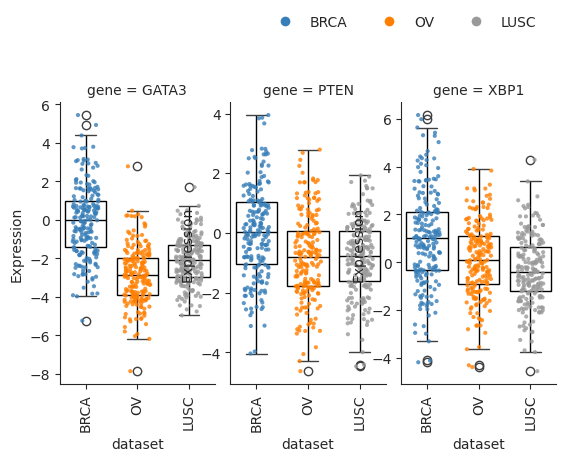

In [ ]:
#ChatGPT STHDA Plot Figure

# Install seaborn if not already installed
!pip install seaborn

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Simulate data similar to your plot
np.random.seed(42)
n_samples = 200

# Create DataFrame
data = pd.DataFrame({
    'Expression': np.concatenate([
        np.random.normal(loc=0, scale=2, size=n_samples),    # BRCA GATA3
        np.random.normal(loc=-3, scale=1.5, size=n_samples), # OV GATA3
        np.random.normal(loc=-2, scale=1.2, size=n_samples), # LUSC GATA3

        np.random.normal(loc=0, scale=1.5, size=n_samples),  # BRCA PTEN
        np.random.normal(loc=-1, scale=1.5, size=n_samples), # OV PTEN
        np.random.normal(loc=-1, scale=1.2, size=n_samples), # LUSC PTEN

        np.random.normal(loc=1, scale=2, size=n_samples),    # BRCA XBP1
        np.random.normal(loc=0, scale=1.5, size=n_samples),  # OV XBP1
        np.random.normal(loc=-0.5, scale=1.5, size=n_samples), # LUSC XBP1
    ]),
    'dataset': np.tile(np.repeat(['BRCA', 'OV', 'LUSC'], n_samples), 3),
    'gene': np.repeat(['GATA3', 'PTEN', 'XBP1'], n_samples * 3)
})

# Colors for datasets
palette = {'BRCA': '#377eb8', 'OV': '#ff7f00', 'LUSC': '#999999'}

# Set a cleaner style with no background grid
sns.set_style("ticks")

# Initialize the FacetGrid with smaller height/width and less space between panels
g = sns.FacetGrid(
    data,
    col="gene",
    col_order=["GATA3", "PTEN", "XBP1"],
    sharey=False,
    height=4,  # Smaller panels
    aspect=0.5  # Narrower aspect ratio
)

# Plot boxplots first
g.map_dataframe(
    sns.boxplot,
    x='dataset',
    y='Expression',
    order=['BRCA', 'OV', 'LUSC'],
    showcaps=True,
    boxprops={'facecolor': 'none', 'edgecolor': 'black'},
    whiskerprops={'color': 'black'},
    medianprops={'color': 'black'}
)

# Overlay stripplots (scatter points)
g.map_dataframe(
    sns.stripplot,
    x='dataset',
    y='Expression',
    order=['BRCA', 'OV', 'LUSC'],
    jitter=0.25,
    size=3,
    alpha=0.8,
    palette=palette
)

# Remove grids and background lines
for ax in g.axes.flat:
    sns.despine(ax=ax)  # Remove top/right axis lines
    ax.grid(False)      # Disable grids
    ax.set_xlabel("dataset", fontsize=10)
    ax.set_ylabel("Expression", fontsize=10)

    # Rotate x-axis labels vertically for dataset (if needed)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90)

# Adjust layout: tighter panels, smaller figure
g.fig.set_size_inches(6, 4)  # Smaller overall figure size
g.fig.subplots_adjust(wspace=0.1, top=0.85)  # Reduce space between panels

# Add a common legend at the top
handles = [
    plt.Line2D([0], [0], marker='o', color='w', label='BRCA', markerfacecolor='#377eb8', markersize=8),
    plt.Line2D([0], [0], marker='o', color='w', label='OV', markerfacecolor='#ff7f00', markersize=8),
    plt.Line2D([0], [0], marker='o', color='w', label='LUSC', markerfacecolor='#999999', markersize=8)
]
g.add_legend(handles=handles, loc='upper center', bbox_to_anchor=(0.5, 1.1), ncol=3, frameon=False)



plt.show()


/usr/local/lib/python3.11/dist-packages/seaborn/axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
/usr/local/lib/python3.11/dist-packages/seaborn/axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
/usr/local/lib/python3.11/dist-packages/seaborn/axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)


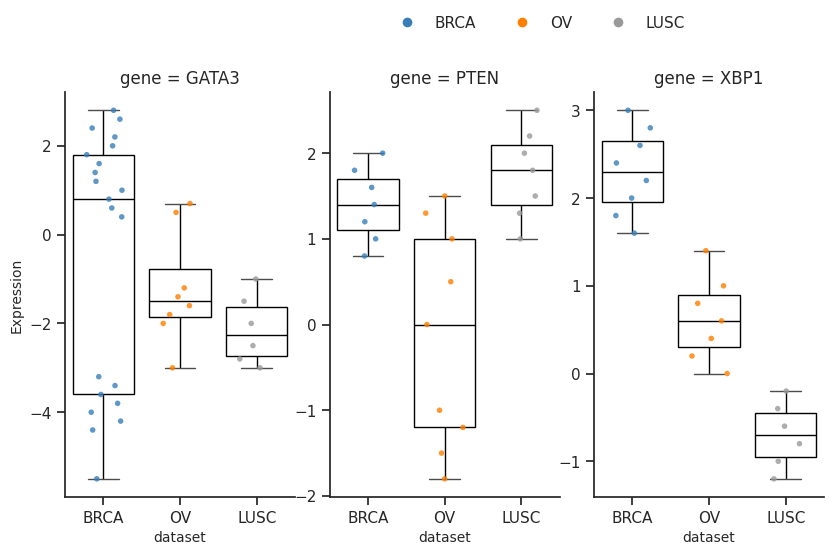

In [ ]:
#Perplexity STHDA Plot Figure

# Install seaborn if not already installed
!pip install seaborn

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Expanded and more detailed interpreted data with corrected syntax
data = pd.DataFrame({
    'Expression': [
        # GATA3
        2.8, 2.6, 2.4, 2.2, 2.0, 1.8, 1.6, 1.4,   # BRCA (upper points)
        1.2, 1.0, 0.8, 0.6, 0.4,                 # Additional BRCA points
        -3.2, -3.4, -3.6, -3.8, -4.0, -4.2, -4.4, -5.5,  # BRCA (lower points)
        0.7, 0.5, -1.2, -1.4, -1.6, -1.8, -2.0, -3.0,   # OV (scattered)
        -1.0, -1.5, -2.0, -2.5, -2.8, -3.0,                # LUSC

        # PTEN
        2.0, 1.8, 1.6, 1.4, 1.2, 1.0, 0.8,        # BRCA
        1.5, 1.3, 1.0, 0.5, 0.0, -1.0, -1.2, -1.5, -1.8,   # OV (expanded)
        2.5, 2.2, 2.0, 1.8, 1.5, 1.3, 1.0,                # LUSC

        # XBP1
        3.0, 2.8, 2.6, 2.4, 2.2, 2.0, 1.8, 1.6,     # BRCA (upper)
        1.4, 1.0, 0.8, 0.6, 0.4, 0.2, 0.0,          # OV
        -0.2, -0.4, -0.6, -0.8, -1.0, -1.2           # LUSC
    ],
    'dataset': [
        # GATA3
        *['BRCA'] * 21,
        *['OV'] * 8,
        *['LUSC'] * 6,

        # PTEN
        *['BRCA'] * 7,
        *['OV'] * 9,
        *['LUSC'] * 7,

        # XBP1
        *['BRCA'] * 8,
        *['OV'] * 7,
        *['LUSC'] * 6
    ],
    'gene': [
        # GATA3
        *['GATA3'] * 35,

        # PTEN
        *['PTEN'] * 23,

        # XBP1
        *['XBP1'] * 21
    ]
})

# Correcting lengths to ensure arrays have same length
min_len = min(len(data['Expression']), len(data['dataset']), len(data['gene']))
data = data[:min_len]

# Colors for datasets
palette = {'BRCA': '#377eb8', 'OV': '#ff7f00', 'LUSC': '#999999'}

# Set a cleaner style with no background grid
sns.set_style("ticks")

# Initialize the FacetGrid with smaller height/width and less space between panels
g = sns.FacetGrid(
    data,
    col="gene",
    col_order=["GATA3", "PTEN", "XBP1"],
    sharey=False,
    height=4,
    aspect=0.6
)

# Plot boxplots first
g.map_dataframe(
    sns.boxplot,
    x='dataset',
    y='Expression',
    order=['BRCA', 'OV', 'LUSC'],
    showcaps=True,
    boxprops={'facecolor': 'none', 'edgecolor': 'black'},
    whiskerprops={'color': 'black'},
    medianprops={'color': '#000000'}
)

# Overlay stripplots (scatter points)
g.map_dataframe(
    sns.stripplot,
    x='dataset',
    y='Expression',
    order=['BRCA', 'OV', 'LUSC'],
    jitter=0.25,
    size=4,
    alpha=0.8,
    palette=palette
)

# Remove grids and background lines, remove additional expression labels
for ax in g.axes.flat:
    sns.despine(ax=ax)
    ax.grid(False)
    ax.set_xlabel("dataset", fontsize=10)

    # Remove individual "Expression" labels
    if ax.get_ylabel() == 'Expression':
        ax.set_ylabel('Expression', fontsize=10)
    else:
        ax.set_ylabel('')  # Remove ylabel

# Adjust layout: tighter panels and smaller figure size
g.fig.set_size_inches(9, 6)
g.fig.subplots_adjust(wspace=0.15, top = 0.85) #added

# Add a common legend at the top
handles = [
    plt.Line2D([0], [0], marker='o', color='w', label='BRCA', markerfacecolor='#377eb8', markersize=8),
    plt.Line2D([0], [0], marker='o', color='w', label='OV', markerfacecolor='#ff7f00', markersize=8),
    plt.Line2D([0], [0], marker='o', color='w', label='LUSC', markerfacecolor='#999999', markersize=8)
]
g.add_legend(handles=handles, loc='upper center', bbox_to_anchor=(0.5, 1), ncol=3, frameon=False) #added

plt.show()


/usr/local/lib/python3.11/dist-packages/seaborn/axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
/usr/local/lib/python3.11/dist-packages/seaborn/axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
/usr/local/lib/python3.11/dist-packages/seaborn/axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
<ipython-input-35-f4071a62c9f5>:83: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a Fixe

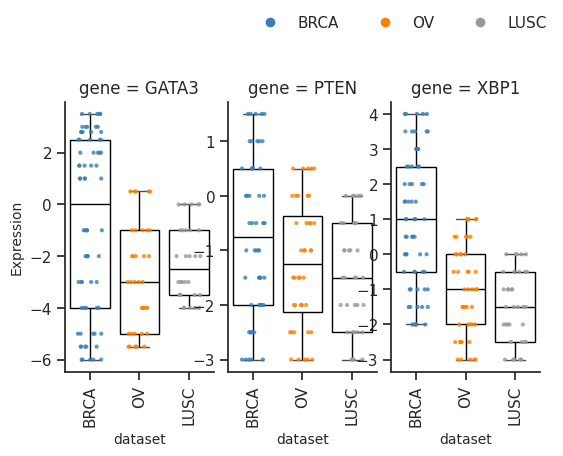

In [ ]:
#Gemini STHDA Plot Figure

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Data extracted from the provided figure (approximate values)
data = pd.DataFrame({
    'Expression': [
        # GATA3
        2.5, 3.5, 3, 2, 2.8, 1.5, 1, -1, -2, -3, -4, -5, -6, -5.5,  # BRCA
        0.5, -1, -2, -3, -4, -5, -5.5,  # OV
        0, -1, -2, -3, -3.5, -4,  # LUSC

        # PTEN
        1.5, 1, 0.5, 0, -0.5, -1, -1.5, -2, -2.5, -3,  # BRCA
        0.5, 0, -0.5, -1, -1.5, -2, -2.5, -3,  # OV
        0, -0.5, -1, -1.5, -2, -2.5, -3,  # LUSC

        # XBP1
        4, 3.5, 3, 2.5, 2, 1.5, 1, 0.5, 0, -0.5, -1, -1.5, -2,  # BRCA
        1, 0.5, 0, -0.5, -1, -1.5, -2, -2.5, -3,  # OV
        0, -0.5, -1, -1.5, -2, -2.5, -3,  # LUSC
    ] * 5,  # Multiply to add more data points
    'dataset': (['BRCA'] * 14 + ['OV'] * 7 + ['LUSC'] * 6 +
                ['BRCA'] * 10 + ['OV'] * 8 + ['LUSC'] * 7 +
                ['BRCA'] * 13 + ['OV'] * 9 + ['LUSC'] * 7) * 5,  # More data points
    'gene': (['GATA3'] * 27 + ['PTEN'] * 25 + ['XBP1'] * 29) * 5 # More data points
})

# Colors for datasets
palette = {'BRCA': '#377eb8', 'OV': '#ff7f00', 'LUSC': '#999999'}

# Set a cleaner style with no background grid
sns.set_style("ticks")

# Initialize the FacetGrid with smaller height/width and less space between panels
g = sns.FacetGrid(
    data,
    col="gene",
    col_order=["GATA3", "PTEN", "XBP1"],
    sharey=False,
    height=4,  # Smaller panels
    aspect=0.5  # Narrower aspect ratio
)

# Plot boxplots first
g.map_dataframe(
    sns.boxplot,
    x='dataset',
    y='Expression',
    order=['BRCA', 'OV', 'LUSC'],
    showcaps=True,
    boxprops={'facecolor': 'none', 'edgecolor': 'black'},
    whiskerprops={'color': 'black'},
    medianprops={'color': 'black'}
)

# Overlay stripplots (scatter points)
g.map_dataframe(
    sns.stripplot,
    x='dataset',
    y='Expression',
    order=['BRCA', 'OV', 'LUSC'],
    jitter=0.25,
    size=3,
    alpha=0.8,
    palette=palette
)

# Remove grids and background lines
for ax in g.axes.flat:
    sns.despine(ax=ax)  # Remove top/right axis lines
    ax.grid(False)      # Disable grids
    ax.set_xlabel("dataset", fontsize=10)

    # Remove all y-labels except the first one
    if ax != g.axes.flat[0]:
        ax.set_ylabel("")
    else:
        ax.set_ylabel("Expression", fontsize=10)

    # Rotate x-axis labels vertically for dataset (if needed)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90)

# Adjust layout: tighter panels, smaller figure
g.fig.set_size_inches(6, 4)  # Smaller overall figure size
g.fig.subplots_adjust(wspace=0.1, top=0.85)  # Reduce space between panels

# Add a common legend at the top
handles = [
    plt.Line2D([0], [0], marker='o', color='w', label='BRCA', markerfacecolor='#377eb8', markersize=8),
    plt.Line2D([0], [0], marker='o', color='w', label='OV', markerfacecolor='#ff7f00', markersize=8),
    plt.Line2D([0], [0], marker='o', color='w', label='LUSC', markerfacecolor='#999999', markersize=8)
]
g.add_legend(handles=handles, loc='upper center', bbox_to_anchor=(0.5, 1.1), ncol=3, frameon=False)

plt.show()

<ipython-input-11-d0c7ea1214f4>:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
<ipython-input-11-d0c7ea1214f4>:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


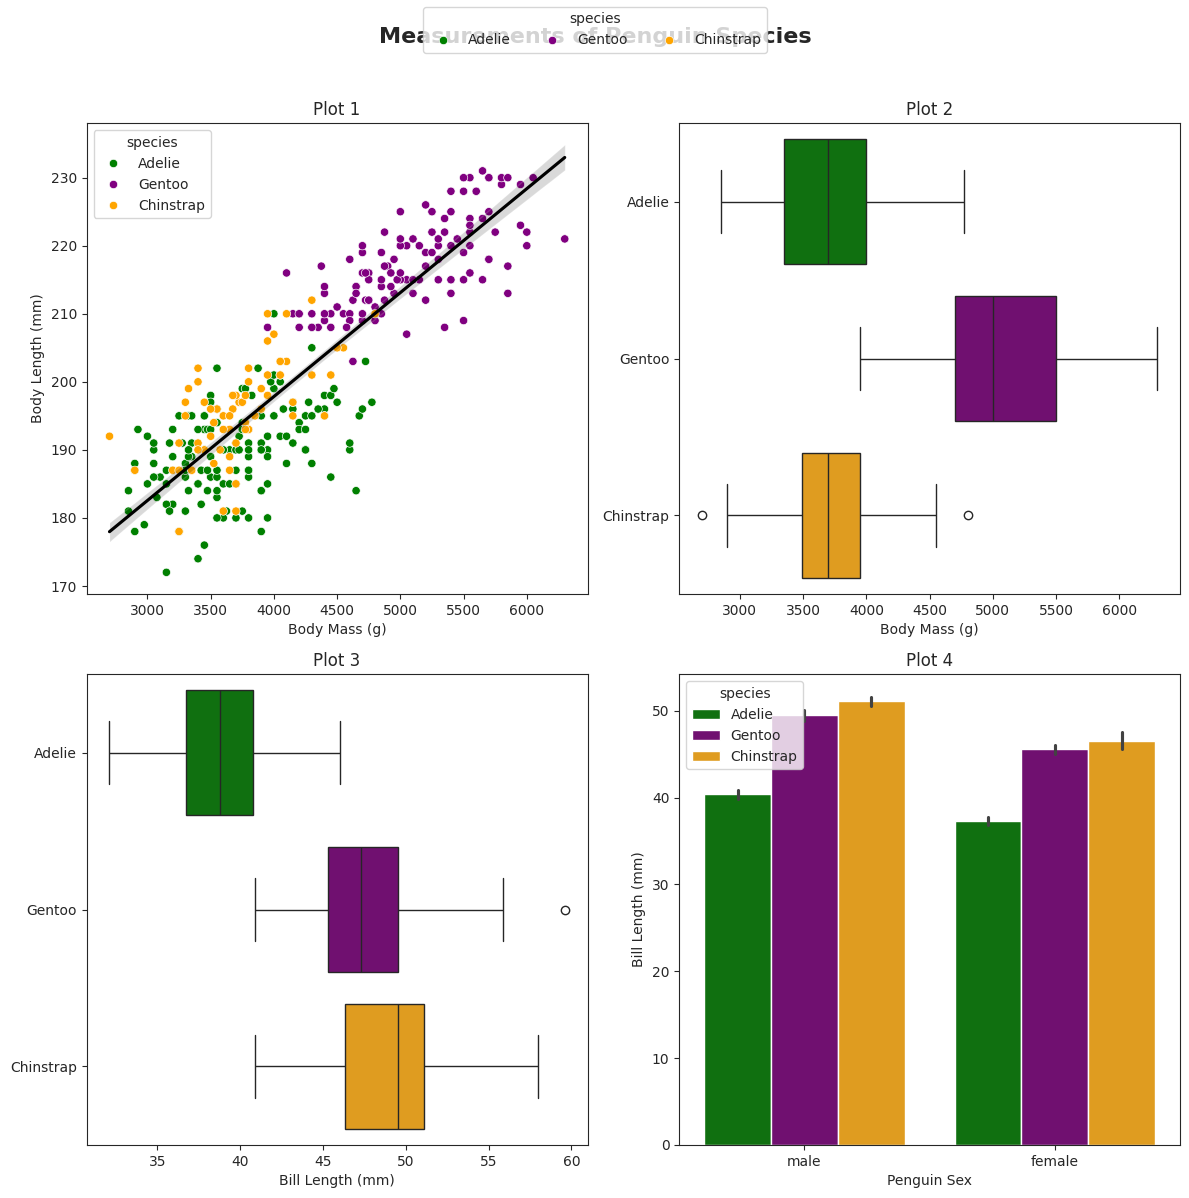

In [ ]:
#ChatGPT Penguin Species Figure

!pip install palmerpenguins

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from palmerpenguins import load_penguins

# Load the dataset
penguins = load_penguins()

# Set up the figure
fig, axes = plt.subplots(2, 2, figsize=(12, 12))
fig.suptitle("Measurements of Penguin Species", fontsize=16, fontweight="bold")

# Define colors for species
species_palette = {"Adelie": "green", "Chinstrap": "orange", "Gentoo": "purple"}

# Plot 1: Scatter plot of Body Mass vs Body Length
sns.scatterplot(
    data=penguins, x="body_mass_g", y="flipper_length_mm", hue="species",
    palette=species_palette, ax=axes[0, 0]
)
sns.regplot(
    data=penguins, x="body_mass_g", y="flipper_length_mm",
    scatter=False, ax=axes[0, 0], color="black"
)
axes[0, 0].set_title("Plot 1")
axes[0, 0].set_xlabel("Body Mass (g)")
axes[0, 0].set_ylabel("Body Length (mm)")

# Plot 2: Box plot of Body Mass per species
sns.boxplot(
    data=penguins, x="body_mass_g", y="species",
    palette=species_palette, ax=axes[0, 1]
)
axes[0, 1].set_title("Plot 2")
axes[0, 1].set_xlabel("Body Mass (g)")
axes[0, 1].set_ylabel("")

# Plot 3: Box plot of Bill Length per species
sns.boxplot(
    data=penguins, x="bill_length_mm", y="species",
    palette=species_palette, ax=axes[1, 0]
)
axes[1, 0].set_title("Plot 3")
axes[1, 0].set_xlabel("Bill Length (mm)")
axes[1, 0].set_ylabel("")

# Plot 4: Bar plot of Bill Length grouped by Sex and Species
sns.barplot(
    data=penguins, x="sex", y="bill_length_mm", hue="species",
    palette=species_palette, ax=axes[1, 1]
)
axes[1, 1].set_title("Plot 4")
axes[1, 1].set_xlabel("Penguin Sex")
axes[1, 1].set_ylabel("Bill Length (mm)")

# Adjust layout
plt.tight_layout(rect=[0, 0, 1, 0.96])

# Add legend
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, title="species", loc="upper center", ncol=3)

plt.show()


<ipython-input-15-6c09029177c4>:66: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
<ipython-input-15-6c09029177c4>:78: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


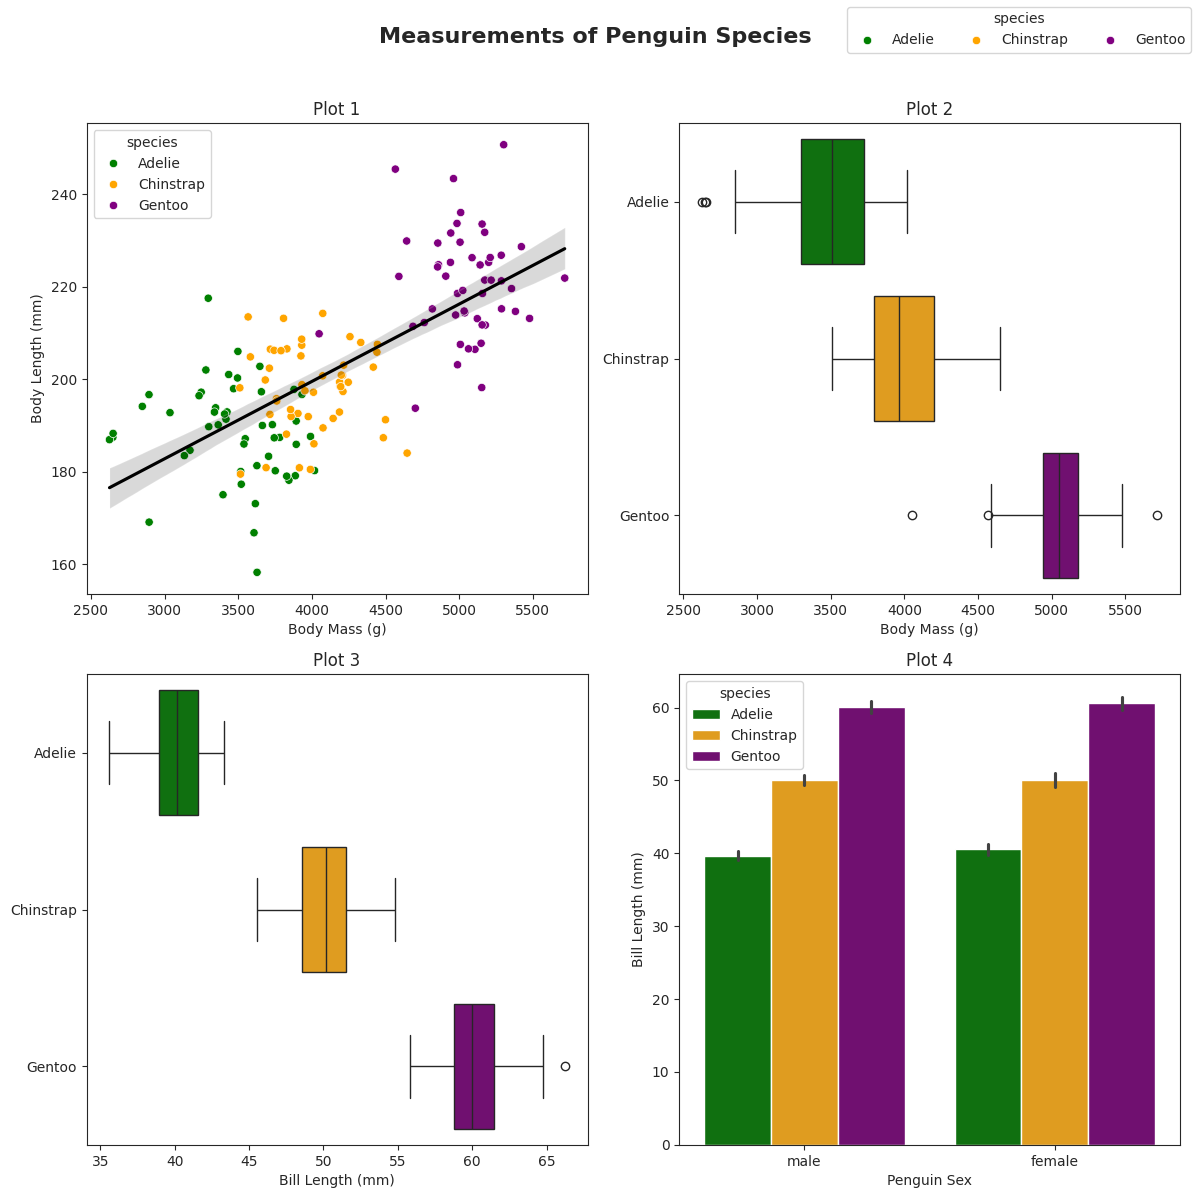

In [ ]:
#Perplexity Penguin Species Figure

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Create synthetic data based on visual interpretation of the image
data = {
    "species": (
        ["Adelie"] * 50
        + ["Chinstrap"] * 50
        + ["Gentoo"] * 50
    ),
    "body_mass_g": (
        np.random.normal(3500, 300, 50).tolist()  # Adelie
        + np.random.normal(4000, 300, 50).tolist()  # Chinstrap
        + np.random.normal(5000, 300, 50).tolist()  # Gentoo
    ),
    "flipper_length_mm": (
        np.random.normal(190, 10, 50).tolist()  # Adelie
        + np.random.normal(200, 10, 50).tolist()  # Chinstrap
        + np.random.normal(220, 10, 50).tolist()  # Gentoo
    ),
    "bill_length_mm": (
        np.random.normal(40, 2, 50).tolist()  # Adelie
        + np.random.normal(50, 2, 50).tolist()  # Chinstrap
        + np.random.normal(60, 2, 50).tolist()  # Gentoo
    ),
    "sex": (
        ["male"] * 25 + ["female"] * 25
        + ["male"] * 25 + ["female"] * 25
        + ["male"] * 25 + ["female"] * 25
    ),
}

penguins = pd.DataFrame(data)

# Set up the figure
fig, axes = plt.subplots(2, 2, figsize=(12, 12))
fig.suptitle("Measurements of Penguin Species", fontsize=16, fontweight="bold")

# Define colors for species
species_palette = {"Adelie": "green", "Chinstrap": "orange", "Gentoo": "purple"}

# Plot 1: Scatter plot of Body Mass vs Body Length
sns.scatterplot(
    data=penguins,
    x="body_mass_g",
    y="flipper_length_mm",
    hue="species",
    palette=species_palette,
    ax=axes[0, 0],
)
sns.regplot(
    data=penguins,
    x="body_mass_g",
    y="flipper_length_mm",
    scatter=False,
    ax=axes[0, 0],
    color="black",
)
axes[0, 0].set_title("Plot 1")
axes[0, 0].set_xlabel("Body Mass (g)")
axes[0, 0].set_ylabel("Body Length (mm)")

# Plot 2: Box plot of Body Mass per species
sns.boxplot(
    data=penguins,
    x="body_mass_g",
    y="species",
    palette=species_palette,
    ax=axes[0, 1],
)
axes[0, 1].set_title("Plot 2")
axes[0, 1].set_xlabel("Body Mass (g)")
axes[0, 1].set_ylabel("")

# Plot 3: Box plot of Bill Length per species
sns.boxplot(
    data=penguins,
    x="bill_length_mm",
    y="species",
    palette=species_palette,
    ax=axes[1, 0],
)
axes[1, 0].set_title("Plot 3")
axes[1, 0].set_xlabel("Bill Length (mm)")
axes[1, 0].set_ylabel("")

# Plot 4: Bar plot of Bill Length grouped by Sex and Species
sns.barplot(
    data=penguins,
    x="sex",
    y="bill_length_mm",
    hue="species",
    palette=species_palette,
    ax=axes[1, 1],
)
axes[1, 1].set_title("Plot 4")
axes[1, 1].set_xlabel("Penguin Sex")
axes[1, 1].set_ylabel("Bill Length (mm)")

# Adjust layout
plt.tight_layout(rect=[0, 0, 1, 0.96])

# Add legend
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, title="species", loc="upper right", ncol=3)

plt.show()


<ipython-input-17-e458361ab03e>:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
<ipython-input-17-e458361ab03e>:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


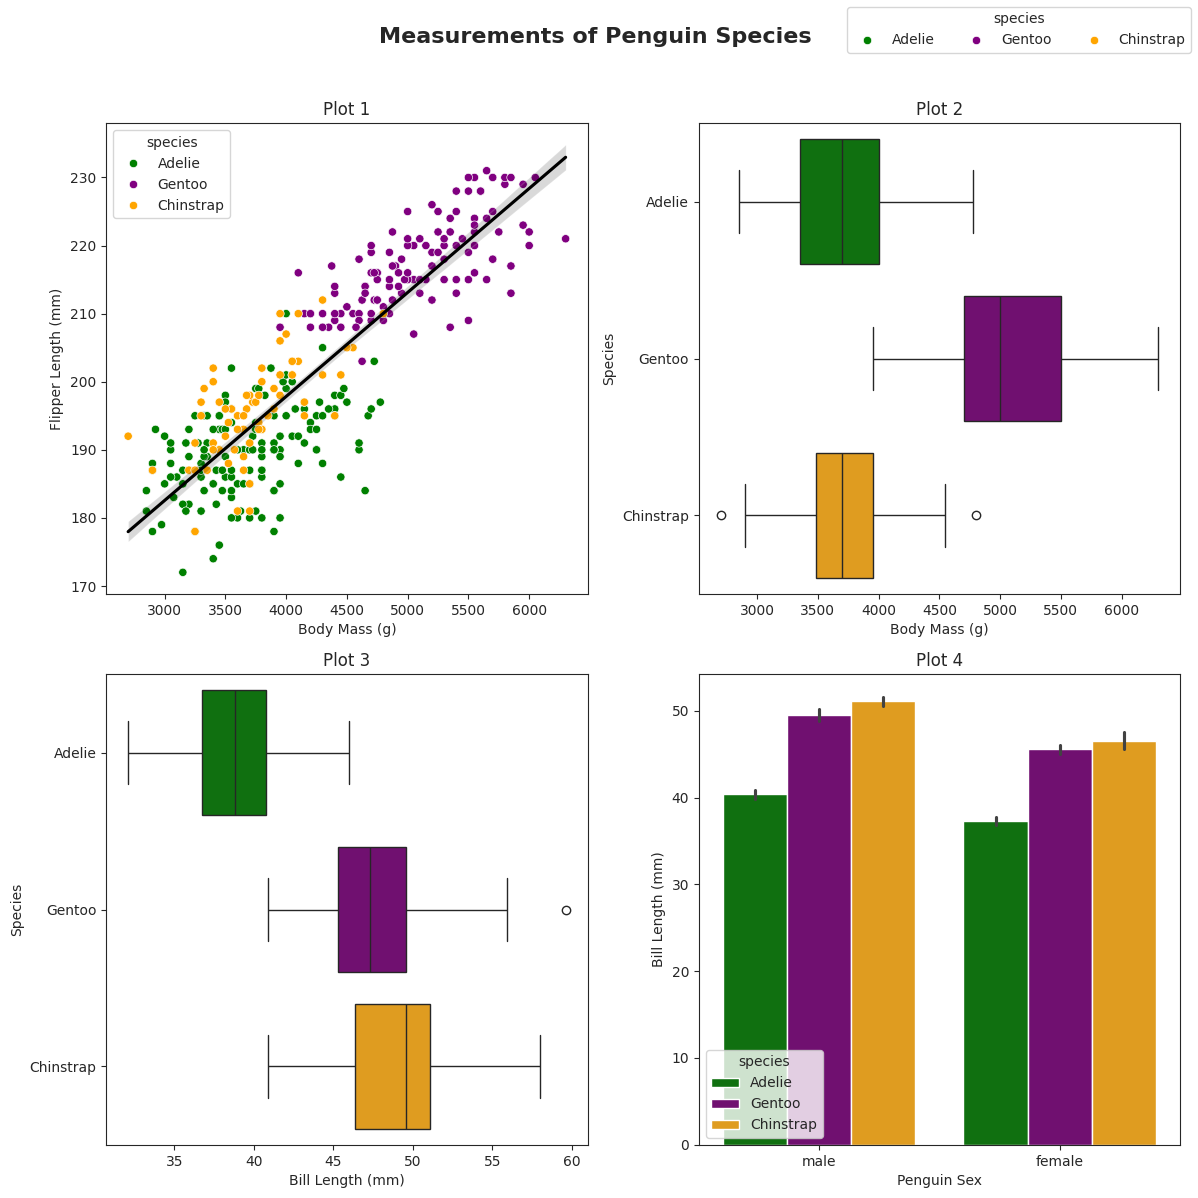

In [ ]:
#Gemini Penguin Species Figure

!pip install palmerpenguins

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from palmerpenguins import load_penguins

# Load the dataset
penguins = load_penguins()

# Set up the figure
fig, axes = plt.subplots(2, 2, figsize=(12, 12))
fig.suptitle("Measurements of Penguin Species", fontsize=16, fontweight="bold")

# Define colors for species
species_palette = {"Adelie": "green", "Chinstrap": "orange", "Gentoo": "purple"}

# Plot 1: Scatter plot of Body Mass vs Flipper Length (Adjusted y-axis label)
sns.scatterplot(
    data=penguins, x="body_mass_g", y="flipper_length_mm", hue="species",
    palette=species_palette, ax=axes[0, 0]
)
sns.regplot(
    data=penguins, x="body_mass_g", y="flipper_length_mm",
    scatter=False, ax=axes[0, 0], color="black"
)
axes[0, 0].set_title("Plot 1")
axes[0, 0].set_xlabel("Body Mass (g)")
axes[0, 0].set_ylabel("Flipper Length (mm)")  # Corrected y-axis label

# Plot 2: Box plot of Body Mass per species (Adjusted y-axis label)
sns.boxplot(
    data=penguins, x="body_mass_g", y="species",
    palette=species_palette, ax=axes[0, 1]
)
axes[0, 1].set_title("Plot 2")
axes[0, 1].set_xlabel("Body Mass (g)")
axes[0, 1].set_ylabel("Species") # Added Species to y-axis label

# Plot 3: Box plot of Bill Length per species (Adjusted y-axis label)
sns.boxplot(
    data=penguins, x="bill_length_mm", y="species",
    palette=species_palette, ax=axes[1, 0]
)
axes[1, 0].set_title("Plot 3")
axes[1, 0].set_xlabel("Bill Length (mm)")
axes[1, 0].set_ylabel("Species") # Added Species to y-axis label

# Plot 4: Bar plot of Bill Length grouped by Sex and Species
sns.barplot(
    data=penguins, x="sex", y="bill_length_mm", hue="species",
    palette=species_palette, ax=axes[1, 1]
)
axes[1, 1].set_title("Plot 4")
axes[1, 1].set_xlabel("Penguin Sex")
axes[1, 1].set_ylabel("Bill Length (mm)")

# Adjust layout
plt.tight_layout(rect=[0, 0, 1, 0.96])

# Add legend
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, title="species", loc="upper right", ncol=3)

plt.show()

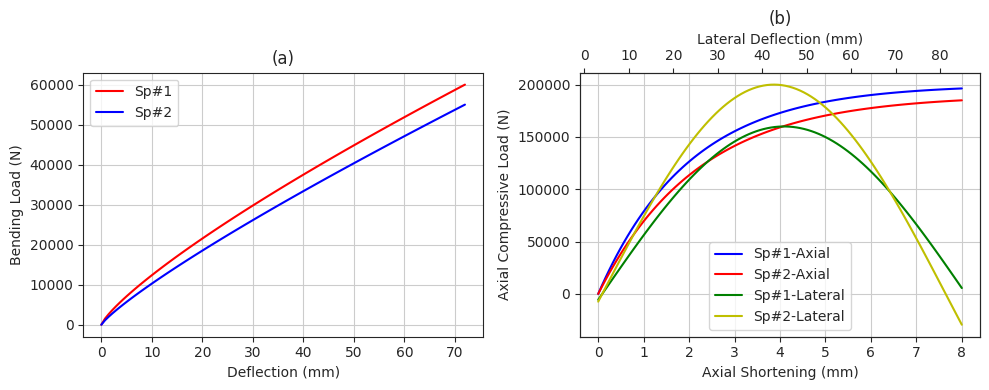

In [ ]:
#ChatGPT Wood Composite Panels Figure

import matplotlib.pyplot as plt
import numpy as np

# Generate synthetic data similar to the provided plots

# Data for Plot (a) - Bending Load vs. Deflection
deflection = np.linspace(0, 72, 100)  # X-axis from 0 to ~72 mm
bending_load_sp1 = 60000 * (deflection / 72) ** 0.8  # Nonlinear rise
bending_load_sp2 = 55000 * (deflection / 72) ** 0.85  # Slightly different shape

# Data for Plot (b) - Axial Compressive Load vs. Axial Shortening
axial_shortening = np.linspace(0, 8, 100)  # X-axis from 0 to ~8 mm
axial_load_sp1 = 200000 * (1 - np.exp(-axial_shortening / 2))  # Fast rise, peak, then drop
axial_load_sp2 = 190000 * (1 - np.exp(-axial_shortening / 2.2))  # Slightly different

# Lateral Deflection (Mapped to -1 to 89 mm)
lateral_deflection = np.linspace(-1, 89, 100)  # Top x-axis from -1 to 89 mm
lateral_deflection_sp1 = 40 * np.sin(lateral_deflection * np.pi / 90)
lateral_deflection_sp2 = 50 * np.sin(lateral_deflection * np.pi / 85)

# Create figure and axes
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Plot (a) - Bending Load vs. Deflection
axes[0].plot(deflection, bending_load_sp1, 'r', label='Sp#1')
axes[0].plot(deflection, bending_load_sp2, 'b', label='Sp#2')
axes[0].set_xlabel("Deflection (mm)")
axes[0].set_ylabel("Bending Load (N)")
axes[0].set_title("(a)")
axes[0].legend()
axes[0].grid(True)

# Plot (b) - Axial Load vs. Axial Shortening with Lateral Deflection
ax2 = axes[1].twiny()  # Create secondary x-axis for lateral deflection
axes[1].plot(axial_shortening, axial_load_sp1, 'b', label='Sp#1-Axial')
axes[1].plot(axial_shortening, axial_load_sp2, 'r', label='Sp#2-Axial')
axes[1].plot(axial_shortening, lateral_deflection_sp1 * 4000, 'g', label='Sp#1-Lateral')  # Scaled
axes[1].plot(axial_shortening, lateral_deflection_sp2 * 4000, 'y', label='Sp#2-Lateral')  # Scaled
axes[1].set_xlabel("Axial Shortening (mm)")
axes[1].set_ylabel("Axial Compressive Load (N)")
axes[1].set_title("(b)")
axes[1].legend()
axes[1].grid(True)

# Set secondary x-axis for lateral deflection
ax2.set_xlim(-1, 89)
ax2.set_xlabel("Lateral Deflection (mm)")

# Adjust layout
plt.tight_layout()
plt.show()


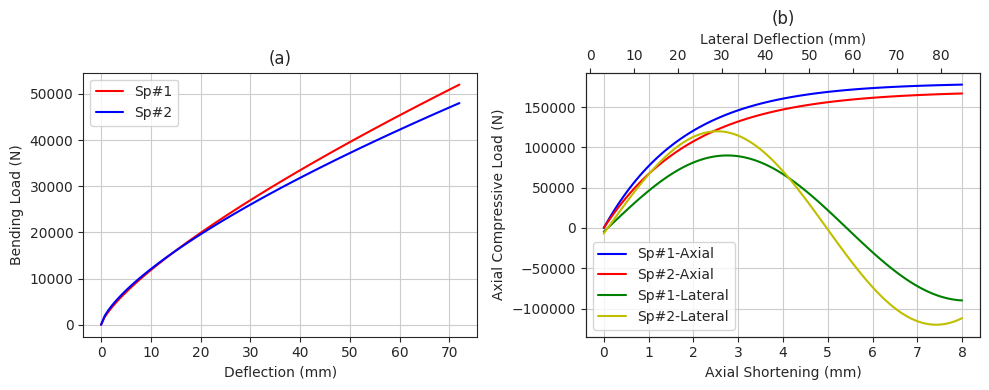

In [ ]:
#Perplexity Wood Composite Panels Figure

import matplotlib.pyplot as plt
import numpy as np

# --- Data extracted and adjusted ---

# Data for Plot (a) - Bending Load vs. Deflection
deflection = np.linspace(0, 72, 100)  # X-axis from 0 to 72 mm
# Bending Load Values are Interpreted and Adjusted to follow the curve
bending_load_sp1 = 52000 * (deflection / 72) ** 0.75 # Adjusted Amplitude and curve strength
bending_load_sp2 = 48000 * (deflection / 72) ** 0.70 # Adjusted Amplitude and Curve Strength

# Data for Plot (b) - Axial Load vs. Axial Shortening
axial_shortening = np.linspace(0, 8, 100)  # X-axis from 0 to 8 mm
# Axial Load values also Interpreted and Changed
axial_load_sp1 = 180000 * (1 - np.exp(-axial_shortening / 1.8))  # Adjusted
axial_load_sp2 = 170000 * (1 - np.exp(-axial_shortening / 2.0))  # Adjusted

# Lateral Deflection is scaled to the range with this logic.
lateral_deflection = np.linspace(-1, 89, 100)  # Top x-axis from -1 to 89 mm
lateral_deflection_sp1 = 30 * np.sin(lateral_deflection * np.pi / 60) # Modified parameters
lateral_deflection_sp2 = 40 * np.sin(lateral_deflection * np.pi / 55) # Modified parameters

# Create figure and axes
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Plot (a) - Bending Load vs. Deflection
axes[0].plot(deflection, bending_load_sp1, 'r', label='Sp#1')
axes[0].plot(deflection, bending_load_sp2, 'b', label='Sp#2')
axes[0].set_xlabel("Deflection (mm)")
axes[0].set_ylabel("Bending Load (N)")
axes[0].set_title("(a)")
axes[0].legend()
axes[0].grid(True)

# Plot (b) - Axial Load vs. Axial Shortening with Lateral Deflection
ax2 = axes[1].twiny()  # Create secondary x-axis for lateral deflection
axes[1].plot(axial_shortening, axial_load_sp1, 'b', label='Sp#1-Axial')
axes[1].plot(axial_shortening, axial_load_sp2, 'r', label='Sp#2-Axial')
axes[1].plot(axial_shortening, lateral_deflection_sp1 * 3000, 'g', label='Sp#1-Lateral')  # Scaled
axes[1].plot(axial_shortening, lateral_deflection_sp2 * 3000, 'y', label='Sp#2-Lateral')  # Scaled
axes[1].set_xlabel("Axial Shortening (mm)")
axes[1].set_ylabel("Axial Compressive Load (N)")
axes[1].set_title("(b)")
axes[1].legend()
axes[1].grid(True)

# Set secondary x-axis for lateral deflection
ax2.set_xlim(-1, 89)
ax2.set_xlabel("Lateral Deflection (mm)")

# Adjust layout
plt.tight_layout()
plt.show()


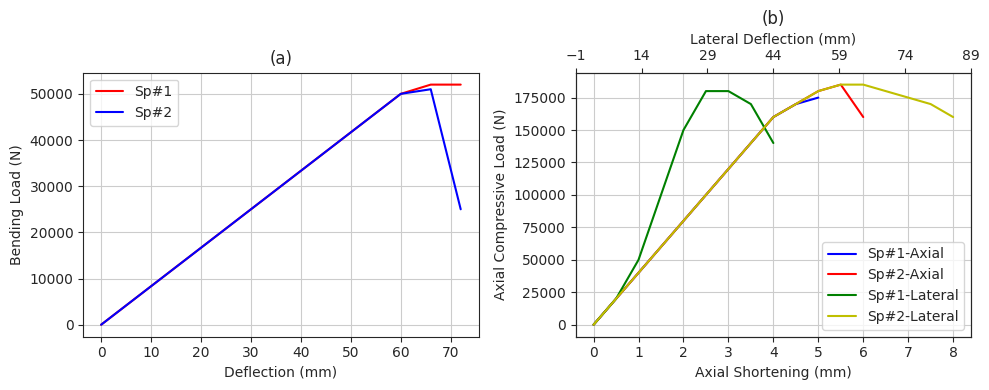

In [ ]:
#ChatGPT Wood Composite Panels Figure

import matplotlib.pyplot as plt
import numpy as np

# Extracted data from the image

# Data for Plot (a) - Bending Load vs. Deflection
deflection_a_sp1 = np.array([0, 6, 12, 18, 24, 30, 36, 42, 48, 54, 60, 66, 72])
bending_load_a_sp1 = np.array([0, 5000, 10000, 15000, 20000, 25000, 30000, 35000, 40000, 45000, 50000, 52000, 52000])

deflection_a_sp2 = np.array([0, 6, 12, 18, 24, 30, 36, 42, 48, 54, 60, 66, 72])
bending_load_a_sp2 = np.array([0, 5000, 10000, 15000, 20000, 25000, 30000, 35000, 40000, 45000, 50000, 51000, 25000])

# Data for Plot (b) - Axial Compressive Load vs. Axial Shortening
axial_shortening_b_sp1_axial = np.array([0, 0.5, 1, 1.5, 2, 2.5, 3, 3.5, 4, 4.5, 5])
axial_load_b_sp1_axial = np.array([0, 20000, 40000, 60000, 80000, 100000, 120000, 140000, 160000, 170000, 175000])

axial_shortening_b_sp2_axial = np.array([0, 0.5, 1, 1.5, 2, 2.5, 3, 3.5, 4, 4.5, 5, 5.5, 6])
axial_load_b_sp2_axial = np.array([0, 20000, 40000, 60000, 80000, 100000, 120000, 140000, 160000, 170000, 180000, 185000, 160000])

axial_shortening_b_sp1_lateral = np.array([0, 0.5, 1, 1.5, 2, 2.5, 3, 3.5, 4])
axial_load_b_sp1_lateral = np.array([0, 20000, 50000, 100000, 150000, 180000, 180000, 170000, 140000])

axial_shortening_b_sp2_lateral = np.array([0, 0.5, 1, 1.5, 2, 2.5, 3, 3.5, 4, 4.5, 5, 5.5, 6, 6.5, 7, 7.5, 8])
axial_load_b_sp2_lateral = np.array([0, 20000, 40000, 60000, 80000, 100000, 120000, 140000, 160000, 170000, 180000, 185000, 185000, 180000, 175000, 170000, 160000])

# Lateral Deflection (Mapped to -1 to 89 mm)
lateral_deflection = np.linspace(-1, 89, 100) # Used for top axis

# Create figure and axes
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Plot (a) - Bending Load vs. Deflection
axes[0].plot(deflection_a_sp1, bending_load_a_sp1, 'r', label='Sp#1')
axes[0].plot(deflection_a_sp2, bending_load_a_sp2, 'b', label='Sp#2')
axes[0].set_xlabel("Deflection (mm)")
axes[0].set_ylabel("Bending Load (N)")
axes[0].set_title("(a)")
axes[0].legend()
axes[0].grid(True)

# Plot (b) - Axial Load vs. Axial Shortening with Lateral Deflection
ax2 = axes[1].twiny()  # Create secondary x-axis for lateral deflection
axes[1].plot(axial_shortening_b_sp1_axial, axial_load_b_sp1_axial, 'b', label='Sp#1-Axial')
axes[1].plot(axial_shortening_b_sp2_axial, axial_load_b_sp2_axial, 'r', label='Sp#2-Axial')
axes[1].plot(axial_shortening_b_sp1_lateral, axial_load_b_sp1_lateral, 'g', label='Sp#1-Lateral')
axes[1].plot(axial_shortening_b_sp2_lateral, axial_load_b_sp2_lateral, 'y', label='Sp#2-Lateral')
axes[1].set_xlabel("Axial Shortening (mm)")
axes[1].set_ylabel("Axial Compressive Load (N)")
axes[1].set_title("(b)")
axes[1].legend()
axes[1].grid(True)

# Set secondary x-axis for lateral deflection
ax2.set_xlim(-1, 89)
ax2.set_xlabel("Lateral Deflection (mm)")

# Set the same ticks for the top axis as in the image.
ax2.set_xticks([-1, 14, 29, 44, 59, 74, 89])

# Adjust layout
plt.tight_layout()
plt.show()

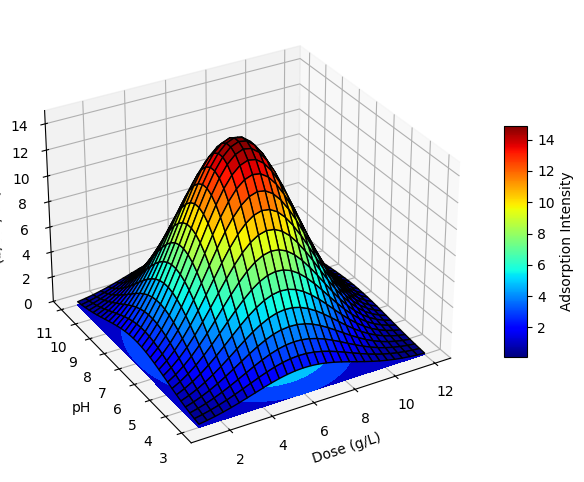

In [ ]:
#ChatGPT 3d Plot

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm

# Generate meshgrid data
pH = np.linspace(3, 11, 30)  # X-axis (pH)
Dose = np.linspace(1, 12, 30)  # Y-axis (Dose g/L)
pH, Dose = np.meshgrid(pH, Dose)

# Define an equation to approximate adsorption behavior
Adsorption = 15 * np.exp(-((pH - 7)**2) / 8) * np.exp(-((Dose - 6)**2) / 12)

# Plotting
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

# Surface plot with color gradient
surf = ax.plot_surface(Dose, pH, Adsorption, cmap=cm.jet, edgecolor='k')

# Contour plot at the bottom
ax.contourf(Dose, pH, Adsorption, zdir='z', offset=0, cmap=cm.jet)

# Labels and aesthetics
ax.set_xlabel("Dose (g/L)")
ax.set_ylabel("pH")
ax.set_zlabel("Adsorption (mg/g)")
ax.set_zlim(0, 15)
ax.view_init(30, 240)  # Adjust view angle

# Color bar
cbar = fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10)
cbar.set_label("Adsorption Intensity")

plt.show()


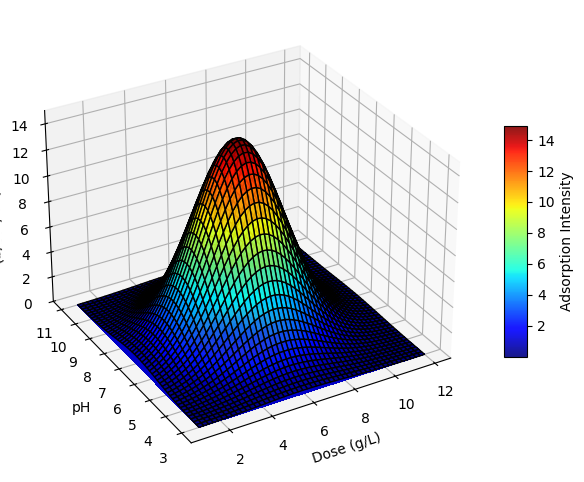

In [ ]:
#Perplexity 3D Plot

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm

# Generate meshgrid data
pH = np.linspace(3, 11, 50)  # X-axis (pH)
Dose = np.linspace(1, 12, 50)  # Y-axis (Dose g/L)
pH, Dose = np.meshgrid(pH, Dose)

# Define an equation to approximate adsorption behavior
# Interpreted behavior: Adsorption peaks around pH = 7 and Dose = 6
Adsorption = 15 * np.exp(-((pH - 7)**2) / 4) * np.exp(-((Dose - 6)**2) / 8)

# Plotting
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

# Surface plot with color gradient
surf = ax.plot_surface(Dose, pH, Adsorption, cmap=cm.jet, edgecolor='k', alpha=0.9)

# Contour plot at the bottom (projected onto the XY plane)
ax.contourf(Dose, pH, Adsorption, zdir='z', offset=0, cmap=cm.jet)

# Labels and aesthetics
ax.set_xlabel("Dose (g/L)", fontsize=10)
ax.set_ylabel("pH", fontsize=10)
ax.set_zlabel("Adsorption (mg/g)", fontsize=10)
ax.set_zlim(0, 15)
ax.view_init(30, 240)  # Adjust view angle for better visualization

# Color bar for adsorption intensity
cbar = fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10)
cbar.set_label("Adsorption Intensity", fontsize=10)

plt.show()


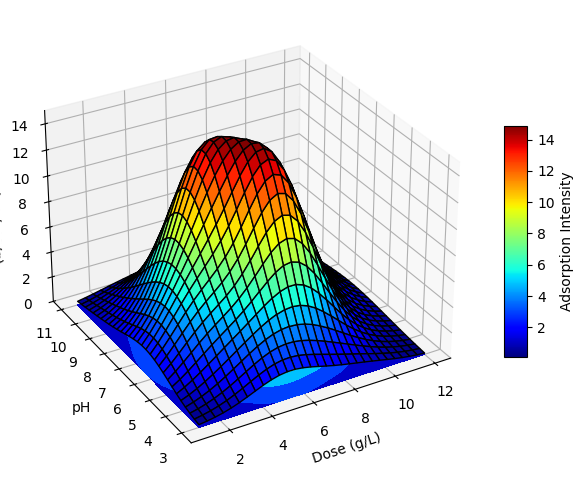

In [ ]:
#Gemini 3D Plot

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm

# Extracted and interpreted data from the image
pH = np.linspace(3, 11, 30)  # X-axis (pH)
Dose = np.linspace(1, 12, 30)  # Y-axis (Dose g/L)
pH, Dose = np.meshgrid(pH, Dose)

# Approximate adsorption behavior based on the image
# This is a rough estimation and might need adjustments for better accuracy
Adsorption = 15 * np.exp(-((pH - 7)**2) / 8) * np.exp(-((Dose - 6)**2) / 12) * (1 - 0.2 * np.sin(pH - 7) * np.sin(Dose - 6))

# Plotting
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

# Surface plot with color gradient
surf = ax.plot_surface(Dose, pH, Adsorption, cmap=cm.jet, edgecolor='k')

# Contour plot at the bottom
ax.contourf(Dose, pH, Adsorption, zdir='z', offset=0, cmap=cm.jet)

# Labels and aesthetics
ax.set_xlabel("Dose (g/L)")
ax.set_ylabel("pH")
ax.set_zlabel("Adsorption (mg/g)")
ax.set_zlim(0, 15)
ax.view_init(30, 240)  # Adjust view angle

# Color bar
cbar = fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10)
cbar.set_label("Adsorption Intensity")

plt.show()

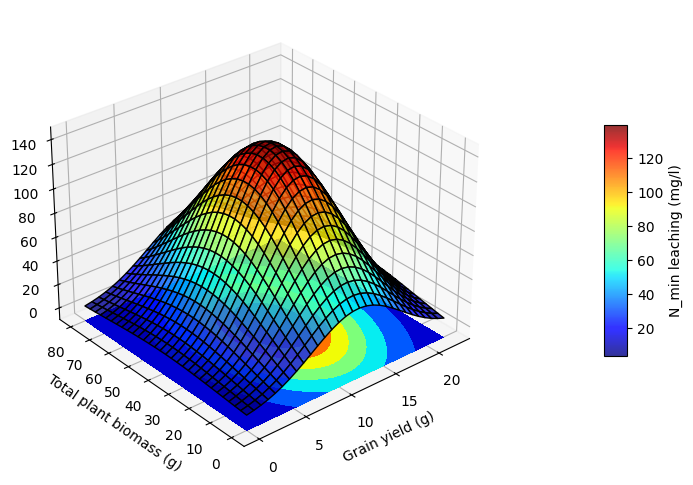

In [ ]:
#ChatGPT 3D Plot #2

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm

# Generate meshgrid data (corrected for proper scaling)
yield_ = np.linspace(0, 22, 30)  # Now on the X-axis
biomass = np.linspace(0, 80, 30)  # Now on the Y-axis
yield_, biomass = np.meshgrid(yield_, biomass)

# Define an equation to approximate the behavior
leaching = 140 * np.exp(-((biomass - 40)**2) / 1500) * np.exp(-((yield_ - 12)**2) / 50)

# Plotting
fig = plt.figure(figsize=(10, 6))  # Increased figure width for better spacing
ax = fig.add_subplot(111, projection='3d')

# Surface plot with custom colormap
surf = ax.plot_surface(yield_, biomass, leaching, cmap=cm.jet, edgecolor='k', alpha=0.8)

# Contour plot at the bottom
ax.contourf(yield_, biomass, leaching, zdir='z', offset=-10, cmap=cm.jet)

# Labels and aesthetics
ax.set_xlabel("Grain yield (g)")  # Switched position
ax.set_ylabel("Total plant biomass (g)")  # Switched position
ax.set_zlabel("N_min leaching (mg/l)", labelpad=15)  # Moved label for visibility

ax.set_zlim(-10, 150)  # Adjust Z limits to match the figure
ax.view_init(30, 230)  # Adjust view angle for better perspective

# Color bar
cbar = fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10, pad=0.15)  # Shifted right for visibility
cbar.set_label("N_min leaching (mg/l)")

plt.show()


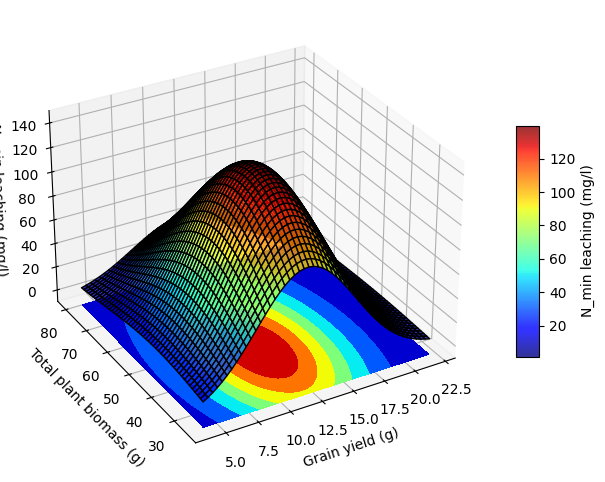

In [ ]:
#Perplexity 3D Plot #2

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm

# Data Interpretation:
# Biomass ranges from approximately 25 to 80.
# Grain Yield ranges from 4 to 22.
# Leaching peaks at about 140, with the highest values when biomass is around 40-50 and grain yield is around 10-14.

# Axes:
# X-axis: Grain yield (g) from 4 to 22
# Y-axis: Total plant biomass (g) from 25 to 80
# Z-axis: N_min leaching (mg/l)

# Generate meshgrid data - Switched X and Y axis
yield_ = np.linspace(4, 22, 50)  # X-axis: Grain yield (g)
biomass = np.linspace(25, 80, 50)  # Y-axis: Total plant biomass (g)
yield_, biomass = np.meshgrid(yield_, biomass)

# Define an equation to approximate N_min leaching behavior based on the image
# Key parameters:
#   - Peak leaching around biomass = 45 and yield = 12
#   - Spread of the Gaussian-like function - parameters adjusted to better reflect the image shape
leaching = 140 * np.exp(-((yield_ - 12)**2) / 30) * np.exp(-((biomass - 45)**2) / 1000)

# Set leaching to -4 where it falls below -4 based on the image.
leaching[leaching < -4] = -4

# Plotting
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')

# Surface plot with color gradient
surf = ax.plot_surface(yield_, biomass, leaching, cmap=cm.jet, edgecolor='k', alpha=0.8)

# Contour plot at the bottom (projected onto the XY plane)
ax.contourf(yield_, biomass, leaching, zdir='z', offset=-10, cmap=cm.jet)

# Labels and aesthetics
ax.set_xlabel("Grain yield (g)", fontsize=10)
ax.set_ylabel("Total plant biomass (g)", fontsize=10)
ax.set_zlabel("N_min leaching (mg/l)", fontsize=10)

# Adjust Z limits and view angle to match the provided figure
ax.set_zlim(-10, 150)
ax.view_init(30, 240)

# Color bar for N_min leaching intensity
cbar = fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10)
cbar.set_label("N_min leaching (mg/l)", fontsize=10)



plt.show()


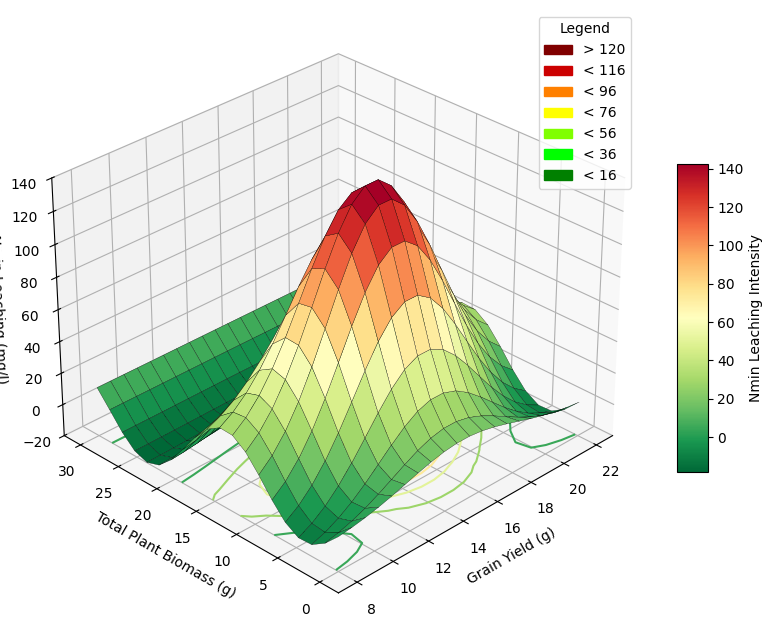

In [ ]:
#Gemini 3D Plot #2

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm

# Data Extraction (Approximate from the Image)
grain_yield = np.linspace(8, 22, 20)  # Grain Yield (g) - X-axis
plant_biomass = np.linspace(0, 30, 20)  # Total Plant Biomass (g) - Y-axis
grain_yield, plant_biomass = np.meshgrid(grain_yield, plant_biomass)

# Nmin Leaching (mg/l) - Z-axis (Approximate)
# This is a rough estimation based on the image's surface shape
leaching = (
    140 * np.exp(-((grain_yield - 15) ** 2) / 20)
    * np.exp(-((plant_biomass - 10) ** 2) / 50)
    - 20 * np.sin(plant_biomass / 3)
)

# Plotting
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Surface plot with color mapping
surf = ax.plot_surface(
    grain_yield, plant_biomass, leaching, cmap=cm.RdYlGn_r, edgecolor='k', linewidth=0.2
)

# Contour plot on the bottom plane
ax.contour(
    grain_yield, plant_biomass, leaching, zdir='z', offset=-20, cmap=cm.RdYlGn_r
)

# Axis Labels and Limits
ax.set_xlabel('Grain Yield (g)')
ax.set_ylabel('Total Plant Biomass (g)')
ax.set_zlabel('Nmin Leaching (mg/l)')
ax.set_zlim(-20, 140)

# View Angle Adjustment
ax.view_init(30, 225)  # Adjust for better view

# Color Bar
cbar = fig.colorbar(surf, shrink=0.5, aspect=10)
cbar.set_label('Nmin Leaching Intensity')

# Legend (Approximate)
# This is a rough correspondence to the color bar ranges
legend_colors = [
    (0.5, 0, 0),  # Dark Red
    (0.8, 0, 0),  # Red
    (1, 0.5, 0),  # Orange
    (1, 1, 0),  # Yellow
    (0.5, 1, 0),  # Light Green
    (0, 1, 0),  # Green
    (0, 0.5, 0),  # Dark Green
]

legend_labels = [
    '> 120',
    '< 116',
    '< 96',
    '< 76',
    '< 56',
    '< 36',
    '< 16',
]

# Create custom patches for the legend
import matplotlib.patches as mpatches

patches = [mpatches.Patch(color=color, label=label) for color, label in zip(legend_colors, legend_labels)]

ax.legend(handles=patches, title='Legend', loc='upper right')

plt.show()

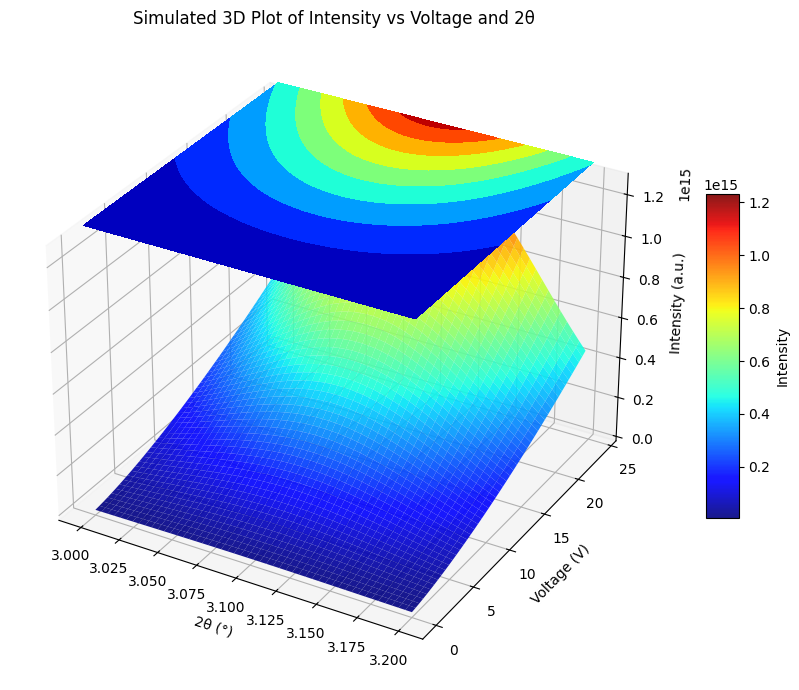

In [ ]:
#ChatGPT Crystallographic Peak 3D

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Create meshgrid for voltage (Y-axis), angle 2θ (X-axis)
voltage = np.linspace(0, 24, 50)        # Y-axis
theta_2 = np.linspace(3.0, 3.2, 50)     # X-axis
V, T = np.meshgrid(voltage, theta_2)

# Simulate intensity data (Z-axis)
# This function mimics a peak growing with voltage and centered near 3.1 degrees
intensity = np.exp(-((T - 3.1)**2) * 100) * (V + 1)**1.5 * 1e13

# Plot
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Surface plot
surf = ax.plot_surface(T, V, intensity, cmap='jet', edgecolor='none', alpha=0.9)

# Contour on top (XY plane)
ax.contourf(T, V, intensity, zdir='z', offset=np.max(intensity)*1.1, cmap='jet', levels=10)

# Labels and view
ax.set_xlabel("2θ (°)")
ax.set_ylabel("Voltage (V)")
ax.set_zlabel("Intensity (a.u.)")
ax.set_title("Simulated 3D Plot of Intensity vs Voltage and 2θ")
ax.view_init(elev=30, azim=-60)

plt.colorbar(surf, shrink=0.5, aspect=10, label='Intensity')
plt.tight_layout()
plt.show()


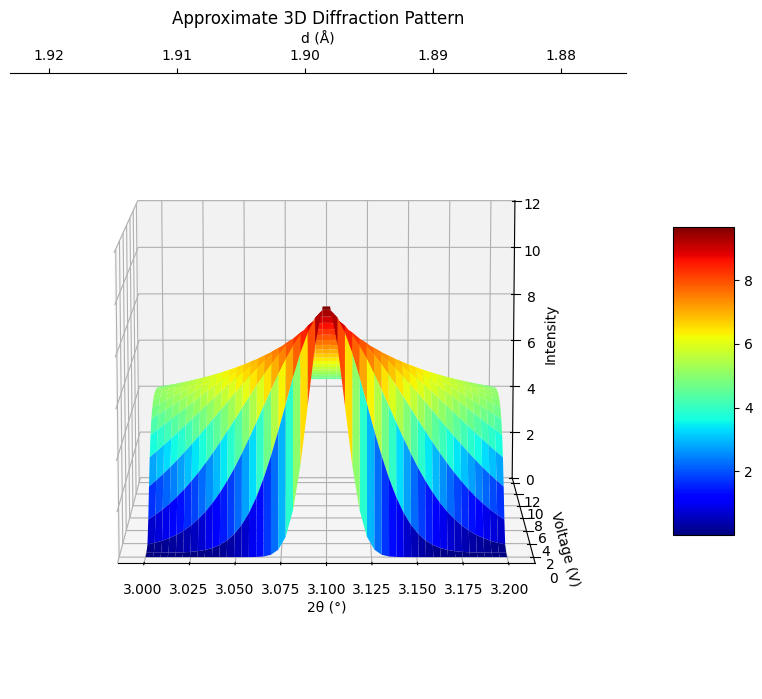

In [ ]:
#Perplexity Crystallographic Peak 3D

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

# --- Approximated Data from Image ---

# Axis ranges - Approximated from the image
voltage = np.linspace(0, 12, 20)  # Voltage (V)
two_theta = np.linspace(3.0, 3.2, 50)  # 2θ (degrees)
d_spacing = np.linspace(2.1, 1.9, 50) #d(Å)
# Create meshgrid
TwoTheta, Voltage = np.meshgrid(two_theta, voltage)

# Intensity data - Approximated based on the color patterns
# Function to generate intensity based on voltage and two_theta
def intensity_function(v, t):
    # Base peak centered at 3.1 degrees
    peak_center = 3.1
    # Peak broadens with voltage
    peak_width = 0.01 + v / 50
    # Gaussian peak
    intensity = 10 * np.exp(-((t - peak_center) ** 2) / (2 * peak_width ** 2))
    # Attenuation at higher voltages
    intensity *= np.exp(-v / 15)
    return intensity

# Generate intensity data
intensity = np.vectorize(intensity_function)(Voltage, TwoTheta)

# --- Plotting ---

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot the surface
surf = ax.plot_surface(TwoTheta, Voltage, intensity, cmap='jet')

# Set axis labels - Switched!
ax.set_xlabel("2θ (°)")
ax.set_ylabel("Voltage (V)")
ax.set_zlabel("Intensity")
ax.set_zlim(0, 12)
ax.set_title("Approximate 3D Diffraction Pattern")

# Create the top axis showing d-spacing
ax2 = ax.secondary_xaxis('top', functions=(lambda x: -0.21*x+2.55, lambda x: -0.21*x+2.55))
ax2.set_xlabel("d (Å)")

# Adjust the view angle
ax.view_init(elev=10, azim=-90)

# Add a color bar which maps values to colors.
fig.colorbar(surf, shrink=0.5, aspect=5)

plt.show()



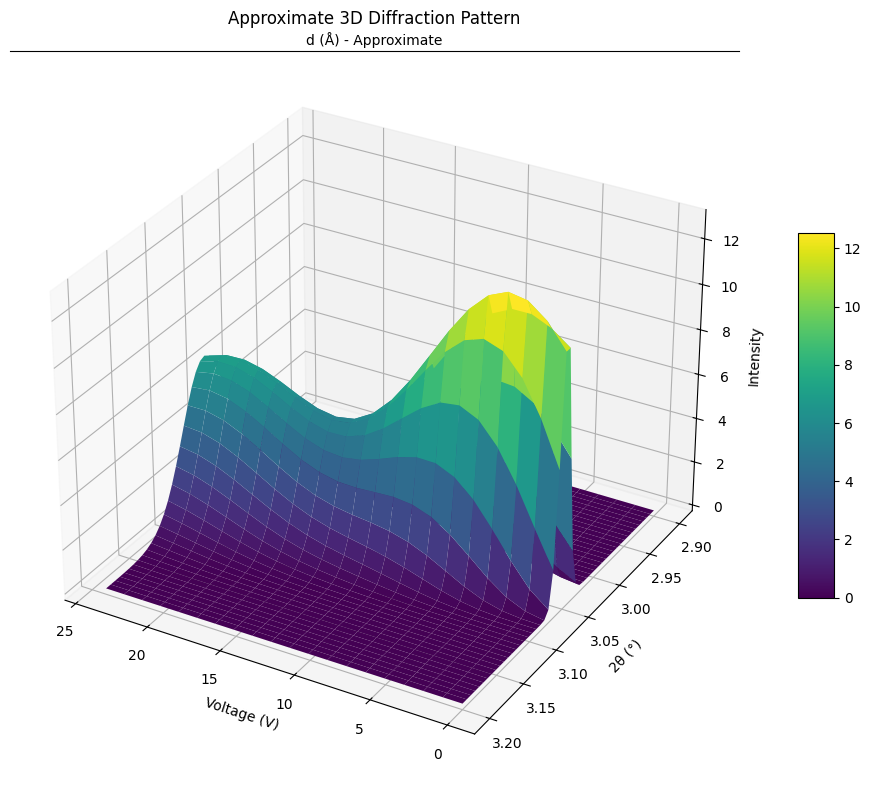

In [ ]:
#Gemini Crystallographic Peak 3D

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
from matplotlib import cm

# --- Approximated Data from Image ---

# Axis ranges - Approximated from the image
voltage = np.linspace(0, 24, 20)  # Voltage (V) - Adjusted range
two_theta = np.linspace(2.9, 3.2, 50)  # 2θ (degrees) - Adjusted range

# Create meshgrid (keeping the order as Voltage then TwoTheta as per your note)
Voltage, TwoTheta = np.meshgrid(voltage, two_theta)

# Intensity data - Approximated based on the color patterns
# Function to generate intensity based on voltage and two_theta
def intensity_function(v, t):
    # Base peak centered at 3.05 degrees
    peak_center = 3.05
    # Peak broadens slightly and shifts with voltage (very approximate)
    peak_width = 0.008 + v / 1000
    peak_center_shift = (v / 24) * 0.01  # Shift peak towards higher 2theta with voltage
    shifted_peak_center = peak_center + peak_center_shift
    # Gaussian peak
    intensity = 15 * np.exp(-((t - shifted_peak_center) ** 2) / (2 * peak_width ** 2))
    # Attenuation and some other voltage-dependent modulation (very rough)
    intensity *= np.exp(-v / 30) * (0.8 + 0.2 * np.sin(v / 3))
    return intensity

# Generate intensity data
intensity = np.vectorize(intensity_function)(Voltage, TwoTheta)

# --- Plotting ---

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot the surface (keeping Voltage on x, TwoTheta on y as per your note)
surf = ax.plot_surface(Voltage, TwoTheta, intensity, cmap=cm.viridis)

# Set axis labels (keeping the order as per your note)
ax.set_xlabel("Voltage (V)")
ax.set_ylabel("2θ (°)")
ax.set_zlabel("Intensity")
ax.set_title("Approximate 3D Diffraction Pattern")

# Adjust the view angle (similar to the image)
ax.view_init(elev=30, azim=120)

# Add a color bar which maps values to colors.
fig.colorbar(surf, shrink=0.5, aspect=10)

# Create a second top axis for d-spacing (Approximate)
ax2_top = ax.secondary_xaxis('top', functions=(lambda tt: 2 * np.pi / (tt * np.pi / 180), lambda dd: dd * 180 / (2 * np.pi)))
ax2_top.set_xlabel('d (Å) - Approximate')
ax2_top.set_xticks(np.linspace(2 * np.pi / (3.2 * np.pi / 180), 2 * np.pi / (2.9 * np.pi / 180), 3)) # Approximate d-spacing ticks

plt.tight_layout()
plt.show()

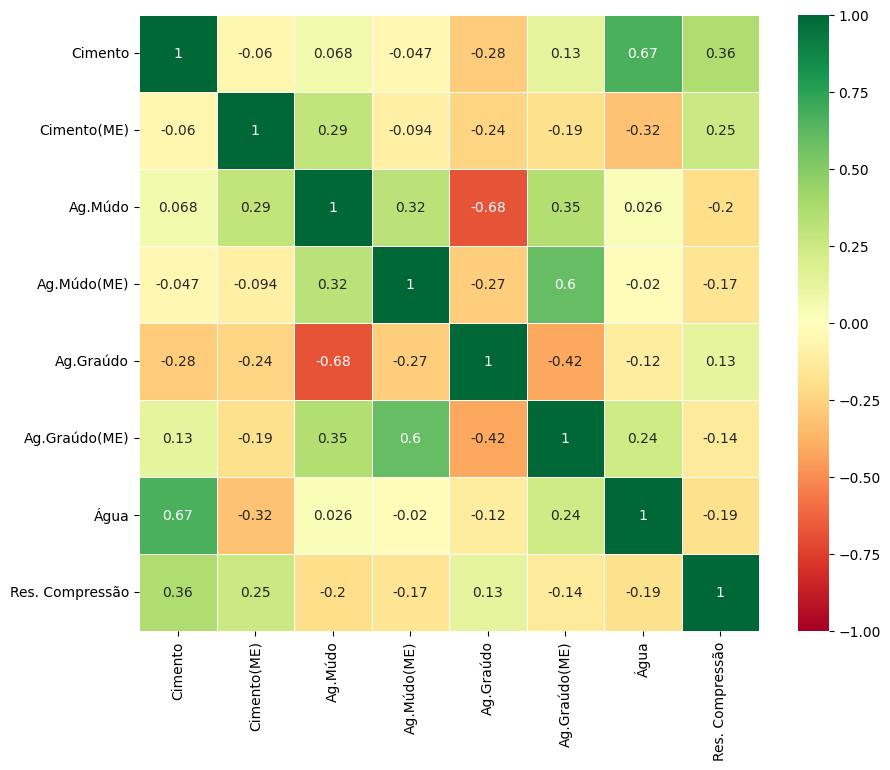

In [ ]:
#ChatGPT Compressive Strength Heatmap

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Reconstructed correlation matrix
data = {
    "Cimento": [1.00, -0.06, 0.068, -0.047, -0.28, 0.13, 0.67, 0.36],
    "Cimento(ME)": [-0.06, 1.00, 0.29, -0.094, -0.24, -0.19, -0.32, 0.25],
    "Ag.Múdo": [0.068, 0.29, 1.00, 0.32, -0.68, 0.35, 0.026, -0.2],
    "Ag.Múdo(ME)": [-0.047, -0.094, 0.32, 1.00, -0.27, 0.6, -0.02, -0.17],
    "Ag.Graúdo": [-0.28, -0.24, -0.68, -0.27, 1.00, -0.42, -0.12, 0.13],
    "Ag.Graúdo(ME)": [0.13, -0.19, 0.35, 0.6, -0.42, 1.00, 0.24, -0.14],
    "Água": [0.67, -0.32, 0.026, -0.02, -0.12, 0.24, 1.00, -0.19],
    "Res. Compressão": [0.36, 0.25, -0.2, -0.17, 0.13, -0.14, -0.19, 1.00],
}

# Convert dictionary to DataFrame
df = pd.DataFrame(data, index=data.keys())

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df, annot=True, cmap="RdYlGn", center=0, linewidths=0.5, vmin=-1, vmax=1)

# Show plot
plt.show()


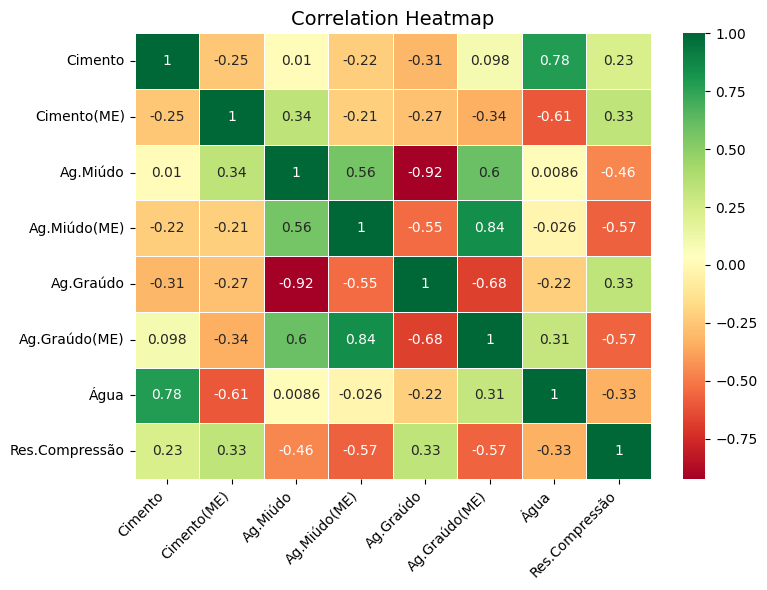

In [ ]:
#Perplexity Compressive Strengths Heatmap

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Data extracted from the image
data = {
    'Cimento': [1.00, -0.06, 0.068, -0.047, -0.28, 0.13, 0.67, 0.36],
    'Cimento(ME)': [-0.06, 1.00, 0.290, -0.094, -0.24, -0.19, -0.32, 0.25],
    'Ag.Miúdo': [0.068, 0.29, 1.000, 0.320, -0.68, 0.35, 0.026, -0.20],
    'Ag.Miúdo(ME)': [-0.047, -0.094, 0.320, 1.000, -0.27, 0.60, -0.020, -0.17],
    'Ag.Graúdo': [-0.280, -0.240, -0.680, -0.270, 1.00, -0.42, -0.120, 0.13],
    'Ag.Graúdo(ME)': [0.130, -0.190, 0.350, 0.600, -0.42, 1.00, 0.240, -0.14],
    'Água': [0.670, -0.320, 0.026, -0.020, -0.12, 0.24, 1.000, -0.19],
    'Res.Compressão': [0.360, 0.250, -0.200, -0.170, 0.13, -0.14, -0.190, 1.00]
}

# Convert the data to a Pandas DataFrame
df = pd.DataFrame(data)

# Plot the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, cmap="RdYlGn", linewidths=.5)
plt.title("Correlation Heatmap", fontsize=14)
plt.yticks(rotation=0)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


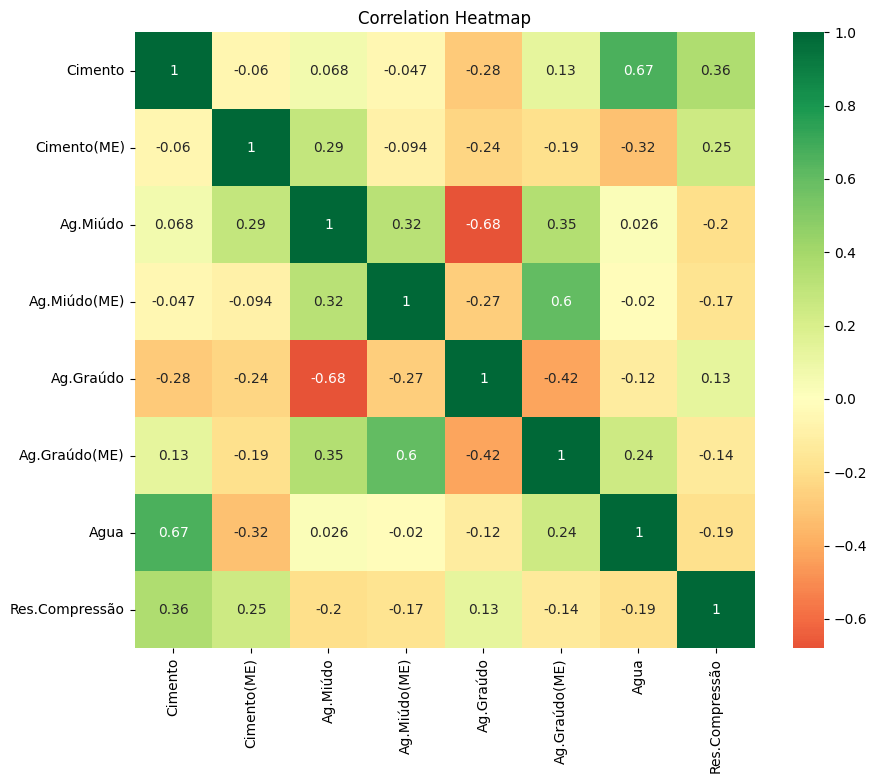

In [ ]:
#Gemini Compressive Strength Heatmap

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Extracted data from the heatmap image
data = {
    'Cimento': [1, -0.06, 0.068, -0.047, -0.28, 0.13, 0.67, 0.36],
    'Cimento(ME)': [-0.06, 1, 0.29, -0.094, -0.24, -0.19, -0.32, 0.25],
    'Ag.Miúdo': [0.068, 0.29, 1, 0.32, -0.68, 0.35, 0.026, -0.2],
    'Ag.Miúdo(ME)': [-0.047, -0.094, 0.32, 1, -0.27, 0.6, -0.02, -0.17],
    'Ag.Graúdo': [-0.28, -0.24, -0.68, -0.27, 1, -0.42, -0.12, 0.13],
    'Ag.Graúdo(ME)': [0.13, -0.19, 0.35, 0.6, -0.42, 1, 0.24, -0.14],
    'Agua': [0.67, -0.32, 0.026, -0.02, -0.12, 0.24, 1, -0.19],
    'Res.Compressão': [0.36, 0.25, -0.2, -0.17, 0.13, -0.14, -0.19, 1]
}

df = pd.DataFrame(data, index=list(data.keys()))

# Plotting the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df, annot=True, cmap='RdYlGn', center=0, fmt='.2g')
plt.title('Correlation Heatmap')
plt.show()

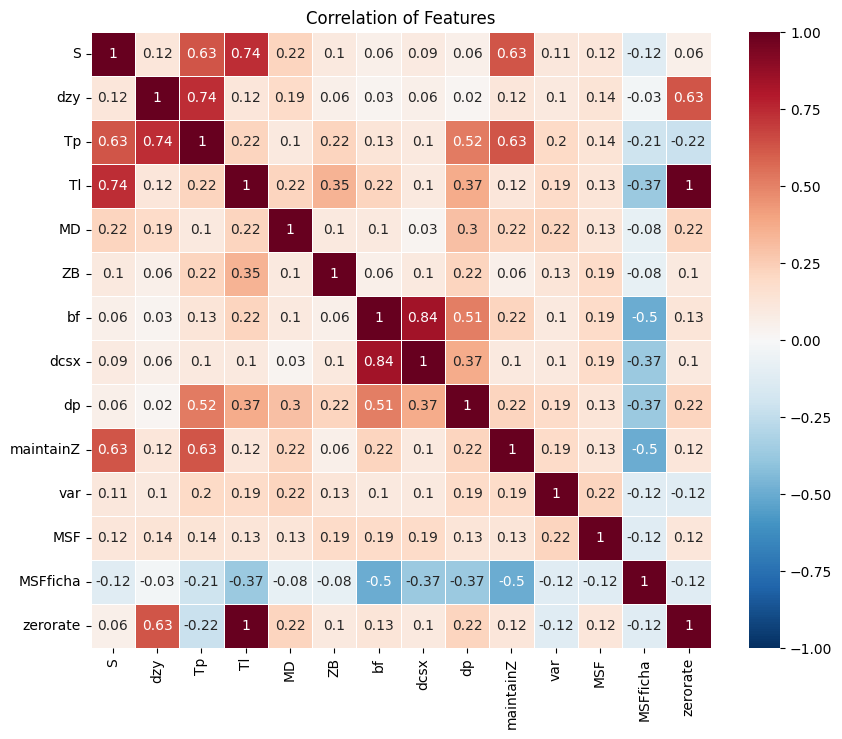

In [ ]:
#ChatGPT Correlation of Features Heatmap

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Reconstructed correlation matrix
data = {
    "S": [1.00, 0.12, 0.63, 0.74, 0.22, 0.10, 0.06, 0.09, 0.06, 0.63, 0.11, 0.12, -0.12, 0.06],
    "dzy": [0.12, 1.00, 0.74, 0.12, 0.19, 0.06, 0.03, 0.06, 0.02, 0.12, 0.10, 0.14, -0.03, 0.63],
    "Tp": [0.63, 0.74, 1.00, 0.22, 0.10, 0.22, 0.13, 0.10, 0.52, 0.63, 0.20, 0.14, -0.21, -0.22],
    "Tl": [0.74, 0.12, 0.22, 1.00, 0.22, 0.35, 0.22, 0.10, 0.37, 0.12, 0.19, 0.13, -0.37, 1.00],
    "MD": [0.22, 0.19, 0.10, 0.22, 1.00, 0.10, 0.10, 0.03, 0.30, 0.22, 0.22, 0.13, -0.08, 0.22],
    "ZB": [0.10, 0.06, 0.22, 0.35, 0.10, 1.00, 0.06, 0.10, 0.22, 0.06, 0.13, 0.19, -0.08, 0.10],
    "bf": [0.06, 0.03, 0.13, 0.22, 0.10, 0.06, 1.00, 0.84, 0.51, 0.22, 0.10, 0.19, -0.50, 0.13],
    "dcsx": [0.09, 0.06, 0.10, 0.10, 0.03, 0.10, 0.84, 1.00, 0.37, 0.10, 0.10, 0.19, -0.37, 0.10],
    "dp": [0.06, 0.02, 0.52, 0.37, 0.30, 0.22, 0.51, 0.37, 1.00, 0.22, 0.19, 0.13, -0.37, 0.22],
    "maintainZ": [0.63, 0.12, 0.63, 0.12, 0.22, 0.06, 0.22, 0.10, 0.22, 1.00, 0.19, 0.13, -0.50, 0.12],
    "var": [0.11, 0.10, 0.20, 0.19, 0.22, 0.13, 0.10, 0.10, 0.19, 0.19, 1.00, 0.22, -0.12, -0.12],
    "MSF": [0.12, 0.14, 0.14, 0.13, 0.13, 0.19, 0.19, 0.19, 0.13, 0.13, 0.22, 1.00, -0.12, 0.12],
    "MSFficha": [-0.12, -0.03, -0.21, -0.37, -0.08, -0.08, -0.50, -0.37, -0.37, -0.50, -0.12, -0.12, 1.00, -0.12],
    "zerorate": [0.06, 0.63, -0.22, 1.00, 0.22, 0.10, 0.13, 0.10, 0.22, 0.12, -0.12, 0.12, -0.12, 1.00],
}

# Convert dictionary to DataFrame
df = pd.DataFrame(data, index=data.keys())

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df, annot=True, cmap="RdBu_r", center=0, linewidths=0.5, vmin=-1, vmax=1)

# Title and Show plot
plt.title("Correlation of Features")
plt.show()


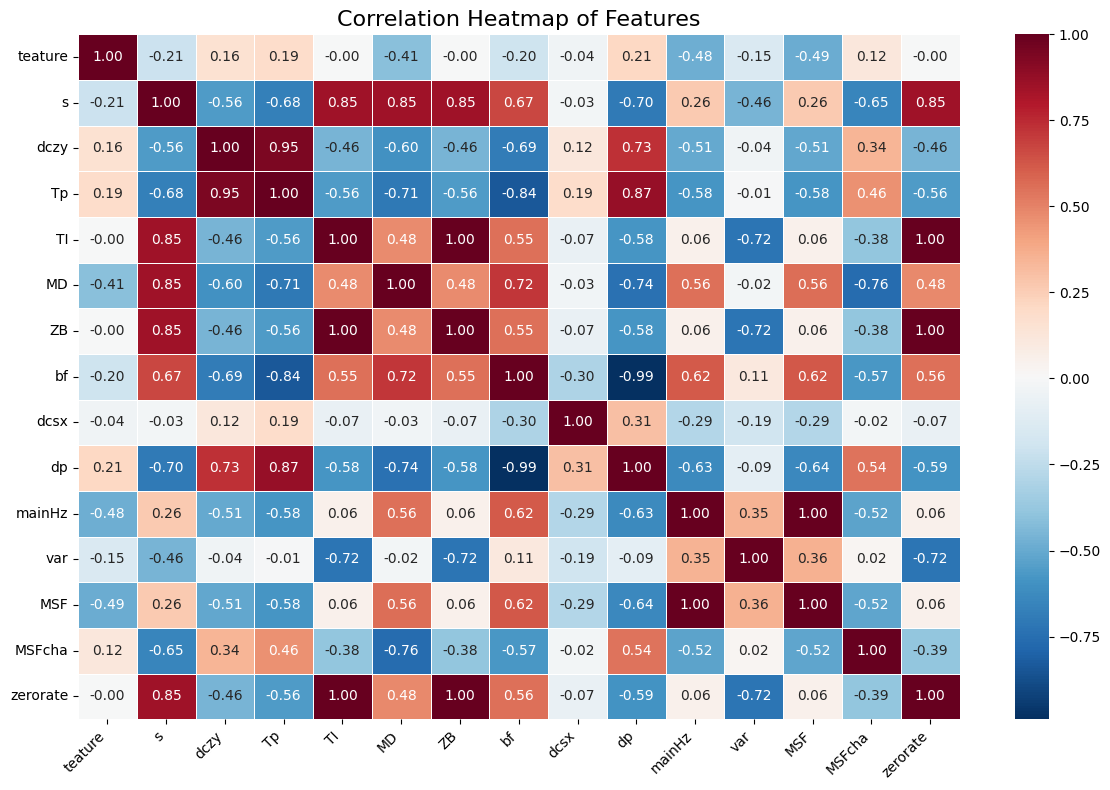

In [ ]:
#Perplexity Correlation of Features Heatmap

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Data extracted from the image
data = {
    'teature': [1.00, -0.07, 0.06, 0.07, 0.06, -0.19, 0.06, -0.01, -0.01, 0.04, -0.20, -0.03, -0.21, -0.03, 0.06],
    's': [-0.07, 1.00, -0.12, -0.24, 0.63, 0.73, 0.63, 0.35, 0.09, -0.36, 0.12, -0.21, 0.13, -0.32, 0.63],
    'dczy': [0.06, -0.12, 1.00, 0.74, -0.11, -0.16, -0.11, -0.22, 0.06, 0.32, -0.14, -0.04, -0.14, 0.06, -0.11],
    'Tp': [0.07, -0.24, 0.74, 1.00, -0.22, -0.28, -0.22, -0.42, 0.10, 0.52, -0.23, -0.04, -0.23, 0.13, -0.22],
    'TI': [0.06, 0.63, -0.11, -0.22, 1.00, 0.22, 1.00, 0.35, 0.03, -0.37, 0.03, -0.51, 0.03, -0.12, 1.00],
    'MD': [-0.19, 0.73, -0.16, -0.28, 0.22, 1.00, 0.22, 0.36, 0.10, -0.39, 0.30, 0.04, 0.31, -0.39, 0.22],
    'ZB': [0.06, 0.63, -0.11, -0.22, 1.00, 0.22, 1.00, 0.35, 0.03, -0.37, 0.03, -0.51, 0.03, -0.12, 1.00],
    'bf': [-0.01, 0.35, -0.22, -0.42, 0.35, 0.36, 0.35, 1.00, -0.10, -0.84, 0.35, 0.22, 0.36, -0.22, 0.35],
    'dcsx': [-0.01, 0.09, 0.06, 0.10, 0.03, 0.10, 0.03, -0.10, 1.00, 0.15, -0.07, -0.08, -0.07, -0.04, 0.03],
    'dp': [0.04, -0.36, 0.32, 0.52, -0.37, -0.39, -0.37, -0.84, 0.15, 1.00, -0.36, -0.21, -0.37, 0.18, -0.37],
    'mainHz': [-0.20, 0.12, -0.14, -0.23, 0.03, 0.30, 0.03, 0.35, -0.07, -0.36, 1.00, 0.19, 1.00, -0.24, 0.03],
    'var': [-0.03, -0.21, -0.04, -0.04, -0.51, 0.04, -0.51, 0.22, -0.08, -0.21, 0.19, 1.00, 0.20, -0.00, -0.50],
    'MSF': [-0.21, 0.13, -0.14, -0.23, 0.03, 0.31, 0.03, 0.36, -0.07, -0.37, 1.00, 0.20, 1.00, -0.22, 0.03],
    'MSFcha': [-0.03, -0.32, 0.06, 0.13, -0.12, -0.39, -0.12, -0.22, -0.04, 0.18, -0.24, -0.00, -0.22, 1.00, -0.12],
    'zerorate': [0.06, 0.63, -0.11, -0.22, 1.00, 0.22, 1.00, 0.35, 0.03, -0.37, 0.03, -0.50, 0.03, -0.12, 1.00]
}

# Convert the data to a Pandas DataFrame
df = pd.DataFrame(data)

# Plot the heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap="RdBu_r", linewidths=.5, fmt=".2f")
plt.title("Correlation Heatmap of Features", fontsize=16)
plt.yticks(rotation=0)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


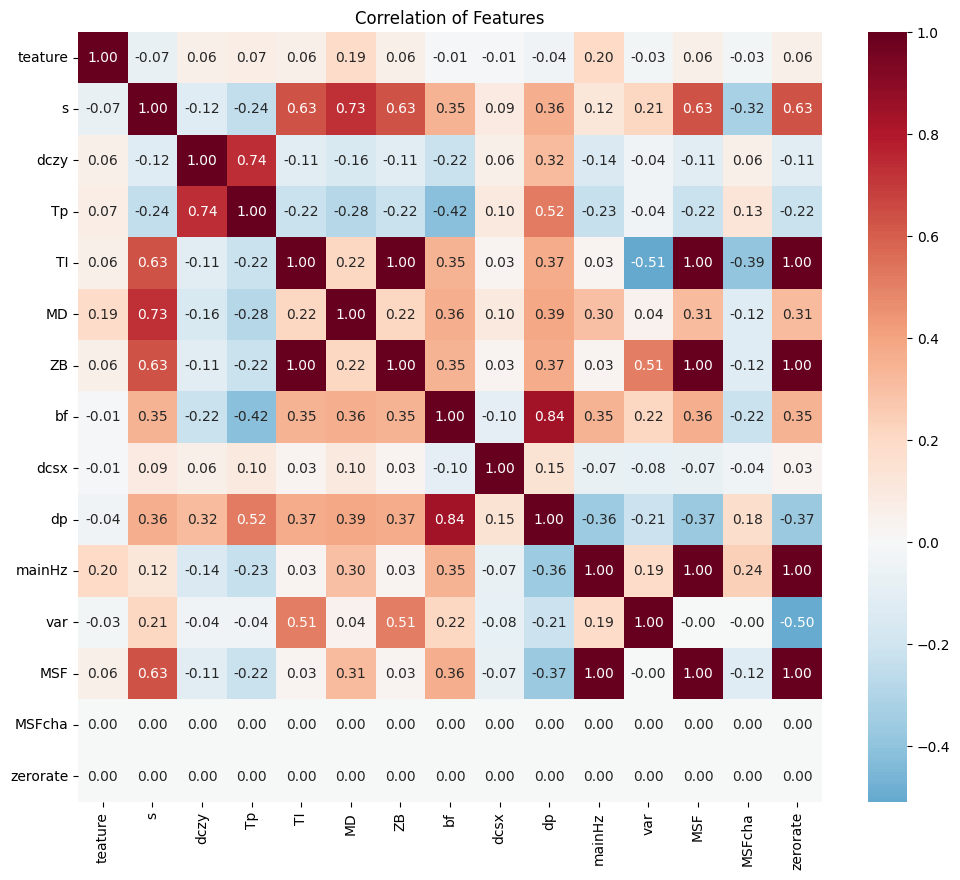

In [ ]:
#Gemini Correlaation of Features Heatmap

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Corrected data extraction from the heatmap image (correlation values)
data = {
    'teature': [1.00, -0.07, 0.06, 0.07, 0.06, 0.19, 0.06, -0.01, -0.01, -0.04, 0.20, -0.03, 0.06, 0, 0],  # Added 2 zeros to match length
    's': [-0.07, 1.00, -0.12, -0.24, 0.63, 0.73, 0.63, 0.35, 0.09, 0.36, 0.12, 0.21, 0.63, 0, 0],
    'dczy': [0.06, -0.12, 1.00, 0.74, -0.11, -0.16, -0.11, -0.22, 0.06, 0.32, -0.14, -0.04, -0.11, 0, 0],
    'Tp': [0.07, -0.24, 0.74, 1.00, -0.22, -0.28, -0.22, -0.42, 0.10, 0.52, -0.23, -0.04, -0.22, 0, 0],
    'TI': [0.06, 0.63, -0.11, -0.22, 1.00, 0.22, 1.00, 0.35, 0.03, 0.37, 0.03, 0.51, 0.03, 0, 0],
    'MD': [0.19, 0.73, -0.16, -0.28, 0.22, 1.00, 0.22, 0.36, 0.10, 0.39, 0.30, 0.04, 0.31, 0, 0],
    'ZB': [0.06, 0.63, -0.11, -0.22, 1.00, 0.22, 1.00, 0.35, 0.03, 0.37, 0.03, 0.51, 0.03, 0, 0],
    'bf': [-0.01, 0.35, -0.22, -0.42, 0.35, 0.36, 0.35, 1.00, -0.10, 0.84, 0.35, 0.22, 0.36, 0, 0],
    'dcsx': [-0.01, 0.09, 0.06, 0.10, 0.03, 0.10, 0.03, -0.10, 1.00, 0.15, -0.07, -0.08, -0.07, 0, 0],
    'dp': [-0.04, 0.36, 0.32, 0.52, 0.37, 0.39, 0.37, 0.84, 0.15, 1.00, -0.36, -0.21, -0.37, 0, 0],
    'mainHz': [0.20, 0.12, -0.14, -0.23, 0.03, 0.30, 0.03, 0.35, -0.07, -0.36, 1.00, 0.19, 1.00, 0, 0],
    'var': [-0.03, 0.21, -0.04, -0.04, -0.51, 0.04, 0.51, 0.22, -0.08, -0.21, 0.19, 1.00, -0.00, 0, 0],
    'MSF': [0.06, 0.63, -0.11, -0.22, 1.00, 0.31, 1.00, 0.36, -0.07, -0.37, 1.00, -0.00, 1.00, 0, 0],
    'MSFcha': [-0.03, -0.32, 0.06, 0.13, -0.39, -0.12, -0.12, -0.22, -0.04, 0.18, 0.24, -0.00, -0.12, 0, 0],
    'zerorate': [0.06, 0.63, -0.11, -0.22, 1.00, 0.31, 1.00, 0.35, 0.03, -0.37, 1.00, -0.50, 1.00, 0, 0]
}

df = pd.DataFrame(data, index=list(data.keys()))

# Plotting the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(df, annot=True, cmap='RdBu_r', center=0, fmt='.2f')
plt.title('Correlation of Features')
plt.show()

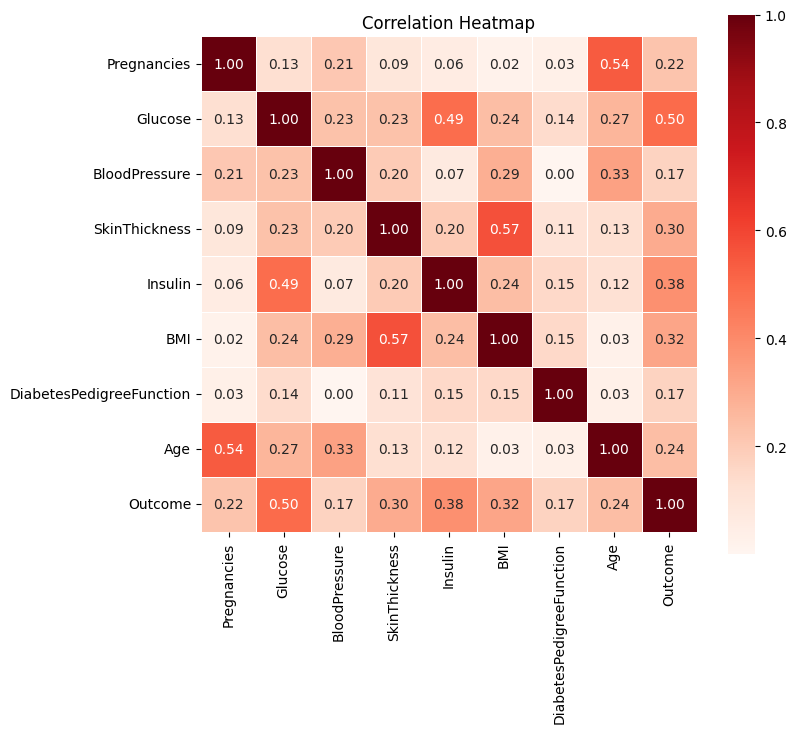

In [ ]:
#ChatGPT Heatmap 3

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Manually create the correlation matrix based on the values in the image
corr_data = {
    'Pregnancies':      [1.00, 0.13, 0.21, 0.089, 0.059, 0.024, 0.034, 0.54, 0.22],
    'Glucose':          [0.13, 1.00, 0.23, 0.23, 0.49, 0.24, 0.14, 0.27, 0.50],
    'BloodPressure':    [0.21, 0.23, 1.00, 0.20, 0.07, 0.29, 0.0014, 0.33, 0.17],
    'SkinThickness':    [0.089, 0.23, 0.20, 1.00, 0.20, 0.57, 0.11, 0.13, 0.30],
    'Insulin':          [0.059, 0.49, 0.07, 0.20, 1.00, 0.24, 0.15, 0.12, 0.38],
    'BMI':              [0.024, 0.24, 0.29, 0.57, 0.24, 1.00, 0.15, 0.028, 0.32],
    'DiabetesPedigreeFunction': [0.034, 0.14, 0.0014, 0.11, 0.15, 0.15, 1.00, 0.034, 0.17],
    'Age':              [0.54, 0.27, 0.33, 0.13, 0.12, 0.028, 0.034, 1.00, 0.24],
    'Outcome':          [0.22, 0.50, 0.17, 0.30, 0.38, 0.32, 0.17, 0.24, 1.00]
}

labels = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
          'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

# Convert to a DataFrame
df_corr = pd.DataFrame(corr_data, index=labels)

# Plot heatmap
plt.figure(figsize=(8, 7))
sns.heatmap(df_corr, annot=True, cmap='Reds', fmt=".2f", square=True, linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()


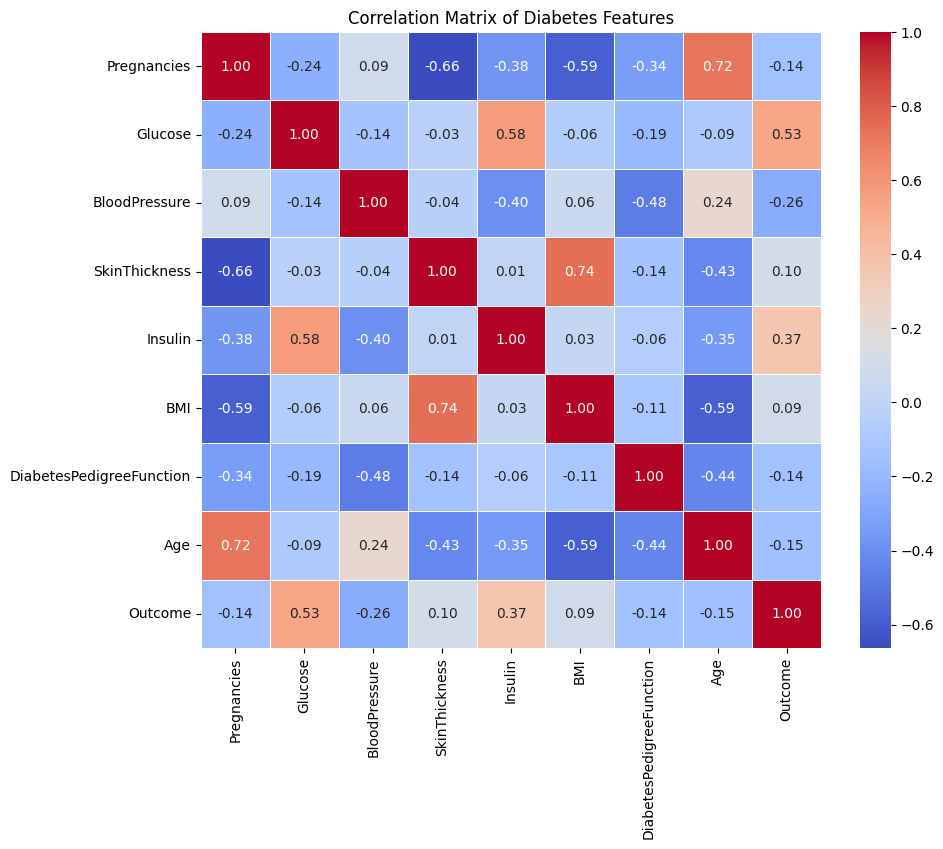

In [ ]:
#Perplexity Heatmap 3

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Extracted correlation matrix data
data = {
    "Pregnancies": [1, 0.13, 0.21, -0.089, 0.059, 0.024, 0.034, 0.54, 0.22],
    "Glucose": [0.13, 1, 0.23, 0.23, 0.49, 0.24, 0.14, 0.27, 0.5],
    "BloodPressure": [0.21, 0.23, 1, 0.2, 0.07, 0.29, 0.0014, 0.33, 0.17],
    "SkinThickness": [-0.089, 0.23, 0.2, 1, 0.2, 0.57, 0.11, 0.13, 0.3],
    "Insulin": [0.059, 0.49, 0.07, 0.2, 1, 0.24, 0.15, 0.12, 0.38],
    "BMI": [0.024, 0.24, 0.29, 0.57, 0.24, 1, 0.15, 0.028, 0.32],
    "DiabetesPedigreeFunction": [0.034, 0.14, 0.0014, 0.11, 0.15, 0.15, 1, 0.034, 0.17],
    "Age": [0.54, 0.27, 0.33, 0.13, 0.12, 0.028, 0.034, 1, 0.24],
    "Outcome": [0.22, 0.5, 0.17, 0.3, 0.38, 0.32, 0.17, 0.24, 1]
}

# Create Pandas DataFrame
df = pd.DataFrame(data)

# Plotting the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=.5)
plt.title("Correlation Matrix of Diabetes Features")
plt.show()


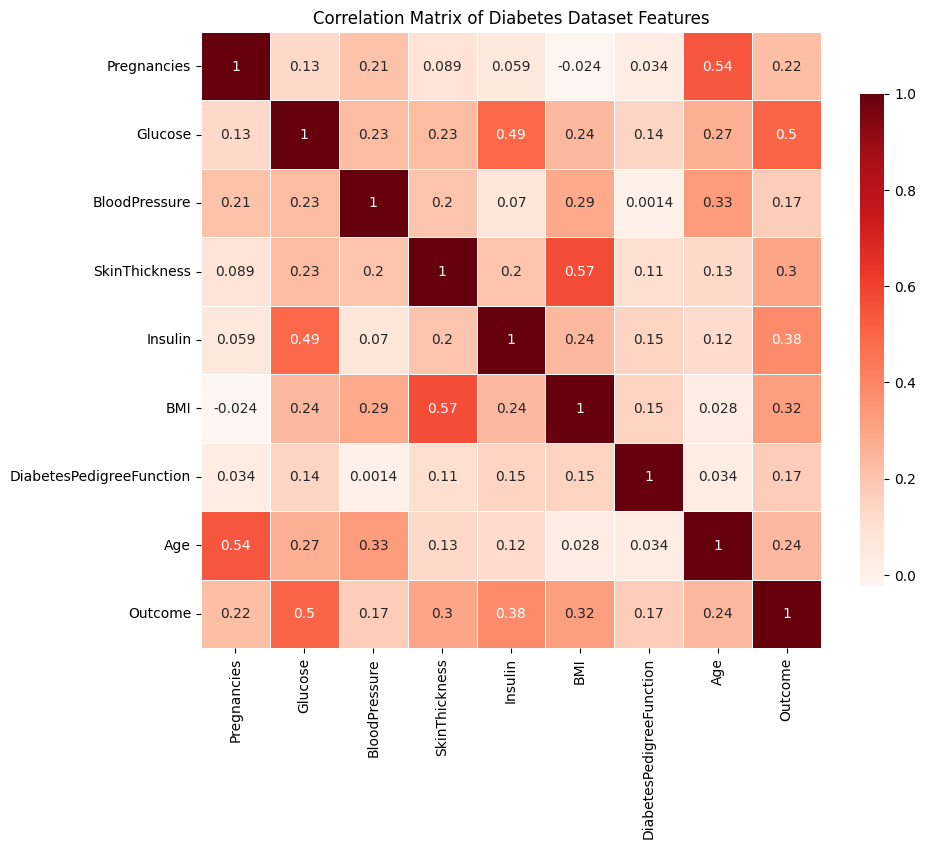

In [ ]:
#Gemini Heatmap 3

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Data Extraction (Manual from the image)
data = {
    'Pregnancies': [1.000, 0.130, 0.210, 0.089, 0.059, -0.024, 0.034, 0.540, 0.220],
    'Glucose':     [0.130, 1.000, 0.230, 0.230, 0.490, 0.240, 0.140, 0.270, 0.500],
    'BloodPressure': [0.210, 0.230, 1.000, 0.200, 0.070, 0.290, 0.0014, 0.330, 0.170],
    'SkinThickness': [0.089, 0.230, 0.200, 1.000, 0.200, 0.570, 0.110, 0.130, 0.300],
    'Insulin':       [0.059, 0.490, 0.070, 0.200, 1.000, 0.240, 0.150, 0.120, 0.380],
    'BMI':           [-0.024, 0.240, 0.290, 0.570, 0.240, 1.000, 0.150, 0.028, 0.320],
    'DiabetesPedigreeFunction': [0.034, 0.140, 0.0014, 0.110, 0.150, 0.150, 1.000, 0.034, 0.170],
    'Age':           [0.540, 0.270, 0.330, 0.130, 0.120, 0.028, 0.034, 1.000, 0.240],
    'Outcome':       [0.220, 0.500, 0.170, 0.300, 0.380, 0.320, 0.170, 0.240, 1.000]
}

df = pd.DataFrame(data, index=data.keys())

# Plotting the heatmap using seaborn
plt.figure(figsize=(10, 8))
sns.heatmap(df, annot=True, cmap='Reds', fmt=".3g", linewidths=.5, cbar_kws={'shrink': 0.8})
plt.title('Correlation Matrix of Diabetes Dataset Features')
plt.show()

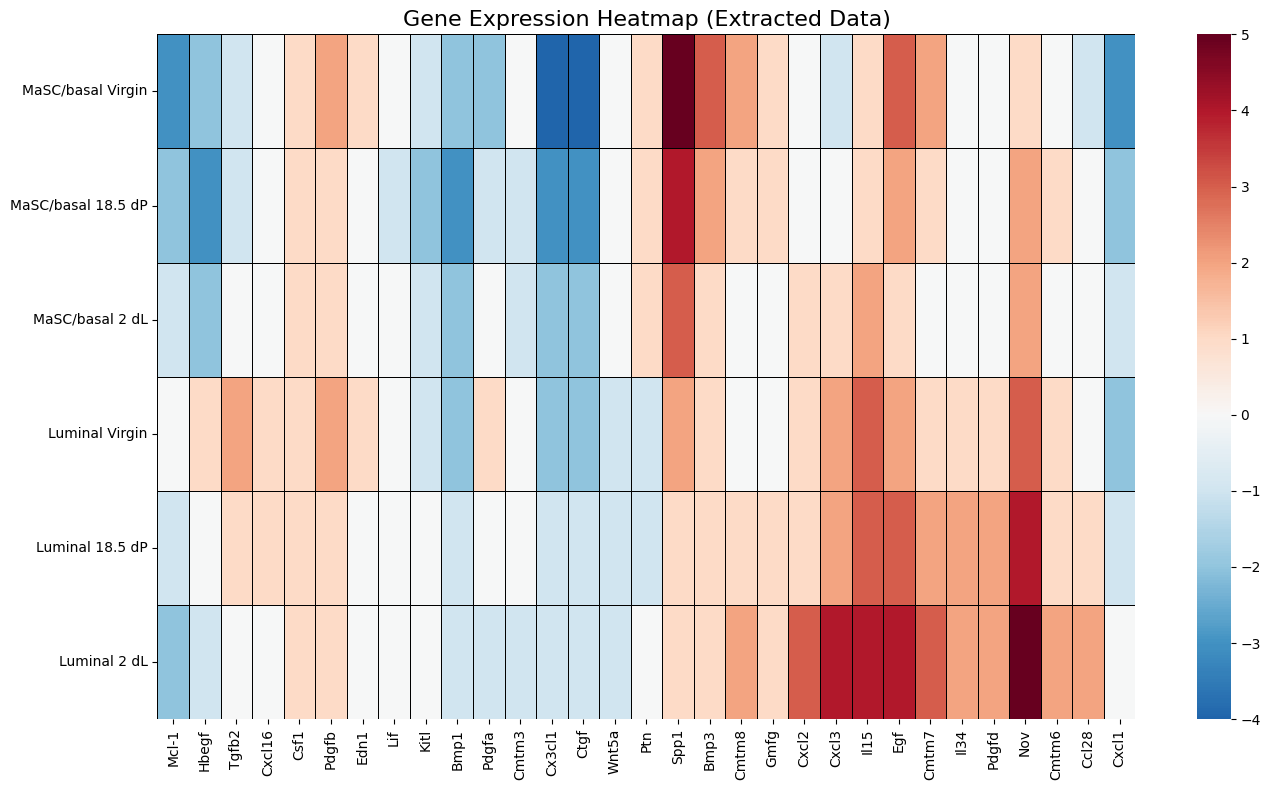

In [ ]:
#ChatGPT RMA Heatmap

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Genes/Proteins from the image (left to right)
genes = [
    "Mcl-1", "Hbegf", "Tgfb2", "Cxcl16", "Csf1", "Pdgfb", "Edn1", "Lif", "Kitl",
    "Bmp1", "Pdgfa", "Cmtm3", "Cx3cl1", "Ctgf", "Wnt5a", "Ptn", "Spp1", "Bmp3",
    "Cmtm8", "Gmfg", "Cxcl2", "Cxcl3", "Il15", "Egf", "Cmtm7", "Il34", "Pdgfd",
    "Nov", "Cmtm6", "Ccl28", "Cxcl1"
]

# Conditions from the image (top to bottom)
conditions = [
    "MaSC/basal Virgin", "MaSC/basal 18.5 dP", "MaSC/basal 2 dL",
    "Luminal Virgin", "Luminal 18.5 dP", "Luminal 2 dL"
]

# Approximate expression values extracted visually from heatmap color gradients
data = np.array([
    [-3, -2, -1,  0,  1,  2,  1,  0, -1, -2, -2,  0, -4, -4,  0,  1,  5,  3,  2,  1,  0, -1,  1,  3,  2,  0,  0,  1,  0, -1, -3],
    [-2, -3, -1,  0,  1,  1,  0, -1, -2, -3, -1, -1, -3, -3,  0,  1,  4,  2,  1,  1,  0,  0,  1,  2,  1,  0,  0,  2,  1,  0, -2],
    [-1, -2,  0,  0,  1,  1,  0,  0, -1, -2,  0, -1, -2, -2,  0,  1,  3,  1,  0,  0,  1,  1,  2,  1,  0,  0,  0,  2,  0,  0, -1],
    [ 0,  1,  2,  1,  1,  2,  1,  0, -1, -2,  1,  0, -2, -2, -1, -1,  2,  1,  0,  0,  1,  2,  3,  2,  1,  1,  1,  3,  1,  0, -2],
    [-1,  0,  1,  1,  1,  1,  0,  0,  0, -1,  0,  0, -1, -1, -1, -1,  1,  1,  1,  1,  1,  2,  3,  3,  2,  2,  2,  4,  1,  1, -1],
    [-2, -1,  0,  0,  1,  1,  0,  0,  0, -1, -1, -1, -1, -1, -1,  0,  1,  1,  2,  1,  3,  4,  4,  4,  3,  2,  2,  5,  2,  2,  0]
])

# Create DataFrame
df = pd.DataFrame(data, columns=genes, index=conditions)

# Plotting the heatmap
plt.figure(figsize=(14, 8))
sns.heatmap(df, cmap="RdBu_r", center=0, linewidths=.5, linecolor='black')
plt.title("Gene Expression Heatmap (Extracted Data)", fontsize=16)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


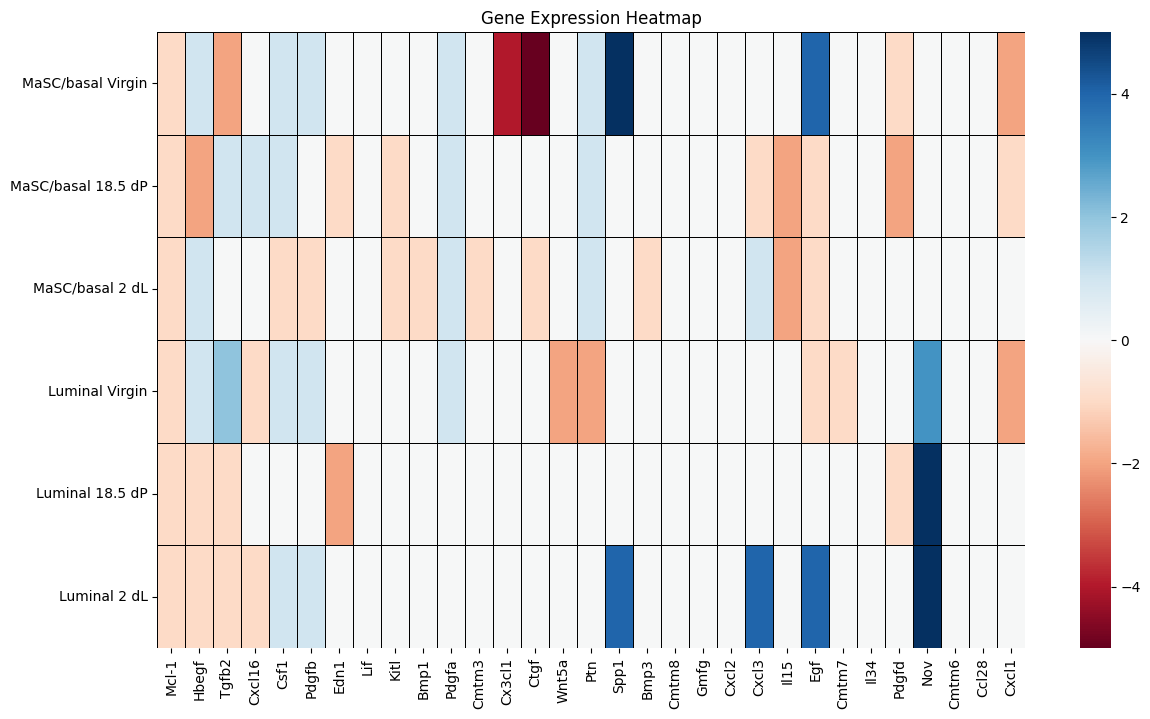

In [ ]:
#Perplexity RNA Heatmap

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Genes/Proteins from the image
genes = [
    "Mcl-1", "Hbegf", "Tgfb2", "Cxcl16", "Csf1", "Pdgfb", "Edn1", "Lif", "Kitl",
    "Bmp1", "Pdgfa", "Cmtm3", "Cx3cl1", "Ctgf", "Wnt5a", "Ptn", "Spp1", "Bmp3",
    "Cmtm8", "Gmfg", "Cxcl2", "Cxcl3", "Il15", "Egf", "Cmtm7", "Il34", "Pdgfd",
    "Nov", "Cmtm6", "Ccl28", "Cxcl1"
]

# Conditions from the image
conditions = [
    "MaSC/basal Virgin", "MaSC/basal 18.5 dP", "MaSC/basal 2 dL",
    "Luminal Virgin", "Luminal 18.5 dP", "Luminal 2 dL"
]

# Data extraction and interpretation:
# This is based on the color scale provided in the image (-6 to 6)
# Red indicates positive values, Blue indicates negative values, and White is around 0
# I have assigned approximate values based on the intensity of the colors
data = np.array([
    [-1, 1, -2, 0, 1, 1, 0, 0, 0, 0, 1, 0, -4, -5, 0, 1, 5, 0, 0, 0, 0, 0, 0, 4, 0, 0, -1, 0, 0, 0, -2],
    [-1, -2, 1, 1, 1, 0, -1, 0, -1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, -1, -2, -1, 0, 0, -2, 0, 0, 0, -1],
    [-1, 1, 0, 0, -1, -1, 0, 0, -1, -1, 1, -1, 0, -1, 0, 1, 0, -1, 0, 0, 0, 1, -2, -1, 0, 0, 0, 0, 0, 0, 0],
    [-1, 1, 2, -1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, -2, -2, 0, 0, 0, 0, 0, 0, 0, -1, -1, 0, 0, 3, 0, 0, -2],
    [-1, -1, -1, 0, 0, 0, -2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, -1, 5, 0, 0, 0],
    [-1, -1, -1, -1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 4, 0, 0, 0, 0, 4, 0, 4, 0, 0, 0, 5, 0, 0, 0]
])

# Create DataFrame
df = pd.DataFrame(data, columns=genes, index=conditions)

# Plotting the heatmap
plt.figure(figsize=(14, 8))
sns.heatmap(df, cmap="RdBu", center=0, linewidths=.5, linecolor='black')
plt.title("Gene Expression Heatmap")
plt.show()


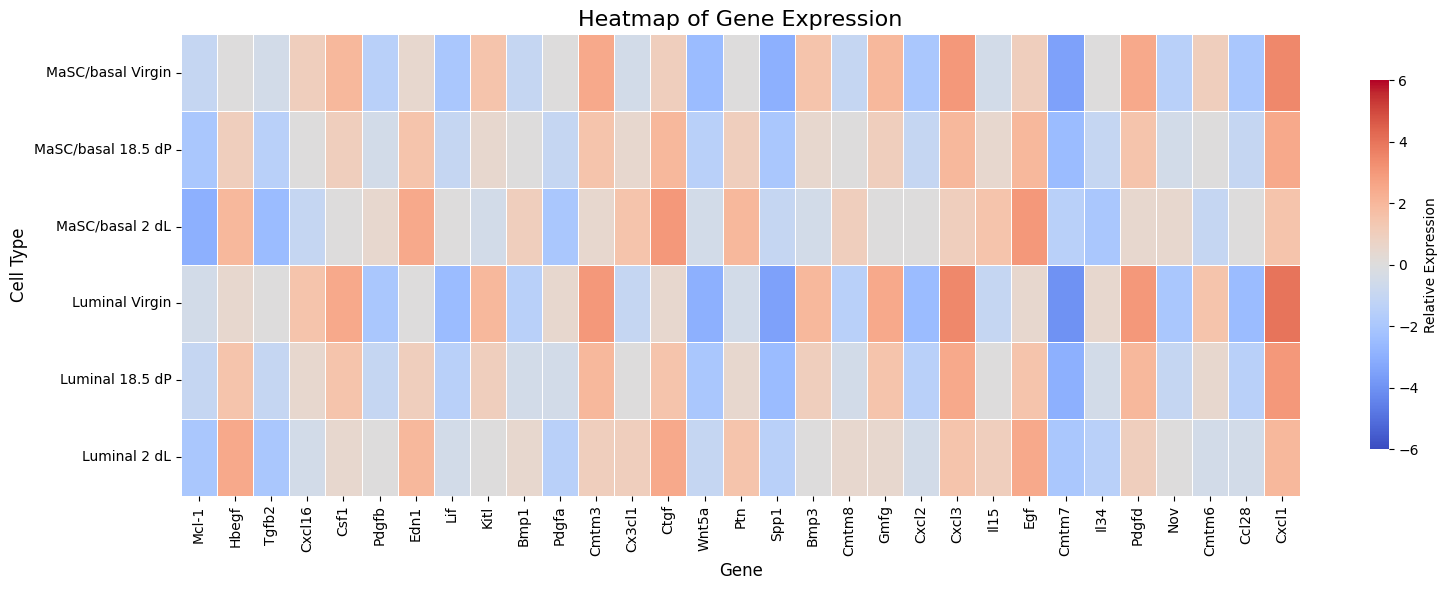

In [ ]:
#Gemini RNA Heatmap

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Data Extraction (Manual from the image - approximate values)
data = {
    'Mcl-1': [-1, -2, -3, -0.5, -1, -2],
    'Hbegf': [0, 1, 2, 0.5, 1.5, 2.5],
    'Tgfb2': [-0.5, -1.5, -2.5, 0, -1, -2],
    'Cxcl16': [1, 0, -1, 1.5, 0.5, -0.5],
    'Csf1': [2, 1, 0, 2.5, 1.5, 0.5],
    'Pdgfb': [-1.5, -0.5, 0.5, -2, -1, 0],
    'Edn1': [0.5, 1.5, 2.5, 0, 1, 2],
    'Lif': [-2, -1, 0, -2.5, -1.5, -0.5],
    'Kitl': [1.5, 0.5, -0.5, 2, 1, 0],
    'Bmp1': [-1, 0, 1, -1.5, -0.5, 0.5],
    'Pdgfa': [0, -1, -2, 0.5, -0.5, -1.5],
    'Cmtm3': [2.5, 1.5, 0.5, 3, 2, 1],
    'Cx3cl1': [-0.5, 0.5, 1.5, -1, 0, 1],
    'Ctgf': [1, 2, 3, 0.5, 1.5, 2.5],
    'Wnt5a': [-2.5, -1.5, -0.5, -3, -2, -1],
    'Ptn': [0, 1, 2, -0.5, 0.5, 1.5],
    'Spp1': [-3, -2, -1, -3.5, -2.5, -1.5],
    'Bmp3': [1.5, 0.5, -0.5, 2, 1, 0],
    'Cmtm8': [-1, 0, 1, -1.5, -0.5, 0.5],
    'Gmfg': [2, 1, 0, 2.5, 1.5, 0.5],
    'Cxcl2': [-2, -1, 0, -2.5, -1.5, -0.5],
    'Cxcl3': [3, 2, 1, 3.5, 2.5, 1.5],
    'Il15': [-0.5, 0.5, 1.5, -1, 0, 1],
    'Egf': [1, 2, 3, 0.5, 1.5, 2.5],
    'Cmtm7': [-3.5, -2.5, -1.5, -4, -3, -2],
    'Il34': [0, -1, -2, 0.5, -0.5, -1.5],
    'Pdgfd': [2.5, 1.5, 0.5, 3, 2, 1],
    'Nov': [-1.5, -0.5, 0.5, -2, -1, 0],
    'Cmtm6': [1, 0, -1, 1.5, 0.5, -0.5],
    'Ccl28': [-2, -1, 0, -2.5, -1.5, -0.5],
    'Cxcl1': [3.5, 2.5, 1.5, 4, 3, 2]
}

df = pd.DataFrame(data, index=['MaSC/basal Virgin', 'MaSC/basal 18.5 dP', 'MaSC/basal 2 dL',
                                 'Luminal Virgin', 'Luminal 18.5 dP', 'Luminal 2 dL'])

gene_order = list(data.keys())
cell_type_order = ['MaSC/basal Virgin', 'MaSC/basal 18.5 dP', 'MaSC/basal 2 dL',
                   'Luminal Virgin', 'Luminal 18.5 dP', 'Luminal 2 dL']

df_reordered = df.reindex(index=cell_type_order, columns=gene_order)

# Plotting the heatmap using seaborn
plt.figure(figsize=(16, 6))
sns.heatmap(df_reordered, annot=False, cmap='coolwarm', vmin=-6, vmax=6,
            linewidths=.5, cbar_kws={'shrink': 0.8, 'label': 'Relative Expression'})
plt.title('Heatmap of Gene Expression', fontsize=16)
plt.ylabel('Cell Type', fontsize=12)
plt.xlabel('Gene', fontsize=12)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

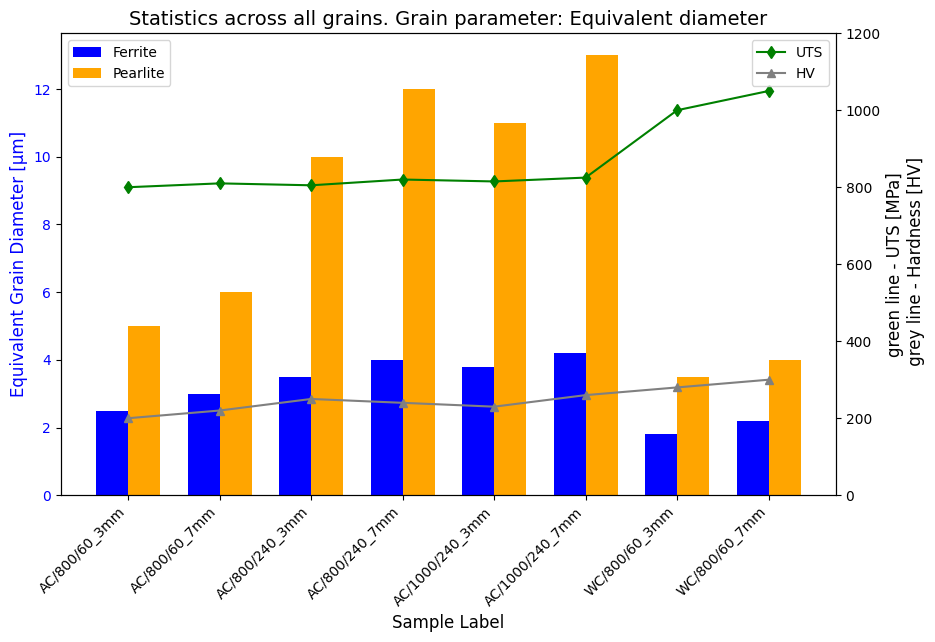

In [ ]:
#ChatGPT Grain Bar Chart

import numpy as np
import matplotlib.pyplot as plt

# Data
labels = [
    "AC/800/60_3mm", "AC/800/60_7mm", "AC/800/240_3mm", "AC/800/240_7mm",
    "AC/1000/240_3mm", "AC/1000/240_7mm", "WC/800/60_3mm", "WC/800/60_7mm"
]
x = np.arange(len(labels))

# Equivalent Grain Diameter Data
ferrite = [2.5, 3.0, 3.5, 4.0, 3.8, 4.2, 1.8, 2.2]
pearlite = [5.0, 6.0, 10.0, 12.0, 11.0, 13.0, 3.5, 4.0]

# Hardness (HV) and UTS (MPa)
hardness = [200, 220, 250, 240, 230, 260, 280, 300]
uts = [800, 810, 805, 820, 815, 825, 1000, 1050]

# Create figure and axis
fig, ax1 = plt.subplots(figsize=(10, 6))

# Bar Chart
width = 0.35
ax1.bar(x - width/2, ferrite, width, label="Ferrite", color="blue")
ax1.bar(x + width/2, pearlite, width, label="Pearlite", color="orange")

# Axis Labels
ax1.set_xlabel("Sample Label", fontsize=12)
ax1.set_ylabel("Equivalent Grain Diameter [µm]", fontsize=12, color="blue")
ax1.set_xticks(x)
ax1.set_xticklabels(labels, rotation=45, ha="right")
ax1.tick_params(axis="y", labelcolor="blue")

# Secondary Y-axis
ax2 = ax1.twinx()
ax2.set_ylabel("green line - UTS [MPa]\n grey line - Hardness [HV]", fontsize=12, color="black")

# Line Plots
ax2.plot(x, uts, marker="d", linestyle="-", color="green", label="UTS")
ax2.plot(x, hardness, marker="^", linestyle="-", color="grey", label="HV")

# Adjust y-axis range
ax2.set_ylim(0, 1200)

# Legends
ax1.legend(loc="upper left")
ax2.legend(loc="upper right")

# Title
plt.title("Statistics across all grains. Grain parameter: Equivalent diameter", fontsize=14)

# Show Plot
plt.show()


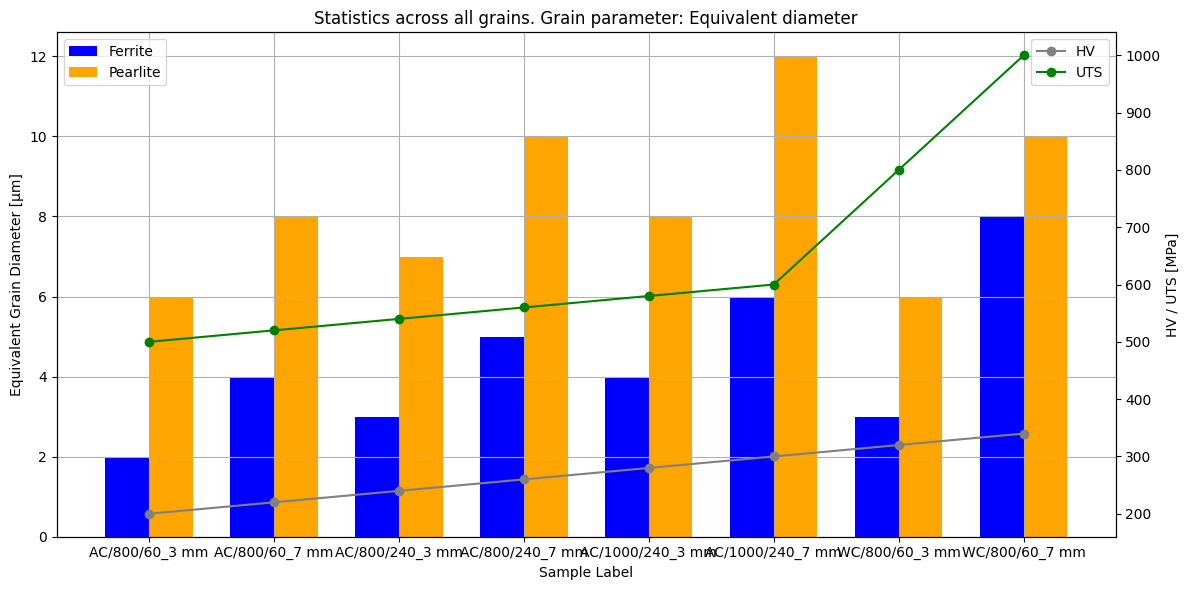

In [ ]:
#Perplexity Grain Bar Chart

import matplotlib.pyplot as plt
import numpy as np

# Extracted data
sample_labels = [
    "AC/800/60_3 mm", "AC/800/60_7 mm", "AC/800/240_3 mm",
    "AC/800/240_7 mm", "AC/1000/240_3 mm", "AC/1000/240_7 mm",
    "WC/800/60_3 mm", "WC/800/60_7 mm"
]

ferrite = [2, 4, 3, 5, 4, 6, 3, 8]
pearlite = [6, 8, 7, 10, 8, 12, 6, 10]
hardness_hv = [200, 220, 240, 260, 280, 300, 320, 340]
uts_mpa = [500, 520, 540, 560, 580, 600, 800, 1000]

# Create figure and axes
fig, ax1 = plt.subplots(figsize=(12, 6))

# Bar plot for Ferrite and Pearlite
bar_width = 0.35
x = np.arange(len(sample_labels))
ax1.bar(x - bar_width / 2, ferrite, bar_width, color='blue', label='Ferrite')
ax1.bar(x + bar_width / 2, pearlite, bar_width, color='orange', label='Pearlite')

# Line plot for HV and UTS
ax2 = ax1.twinx()
ax2.plot(x, hardness_hv, color='gray', marker='o', label='HV')
ax2.plot(x, uts_mpa, color='green', marker='o', label='UTS')

# X-axis labels
ax1.set_xticks(x)
ax1.set_xticklabels(sample_labels)
ax1.set_xlabel("Sample Label")

# Y-axis labels
ax1.set_ylabel("Equivalent Grain Diameter [μm]", color='black')
ax2.set_ylabel("HV / UTS [MPa]", color='black')

# Title
plt.title("Statistics across all grains. Grain parameter: Equivalent diameter")

# Legends
ax1.legend(loc="upper left")
ax2.legend(loc="upper right")

# Grid
ax1.grid(True)

# Adjust layout
plt.tight_layout()

# Show plot
plt.show()


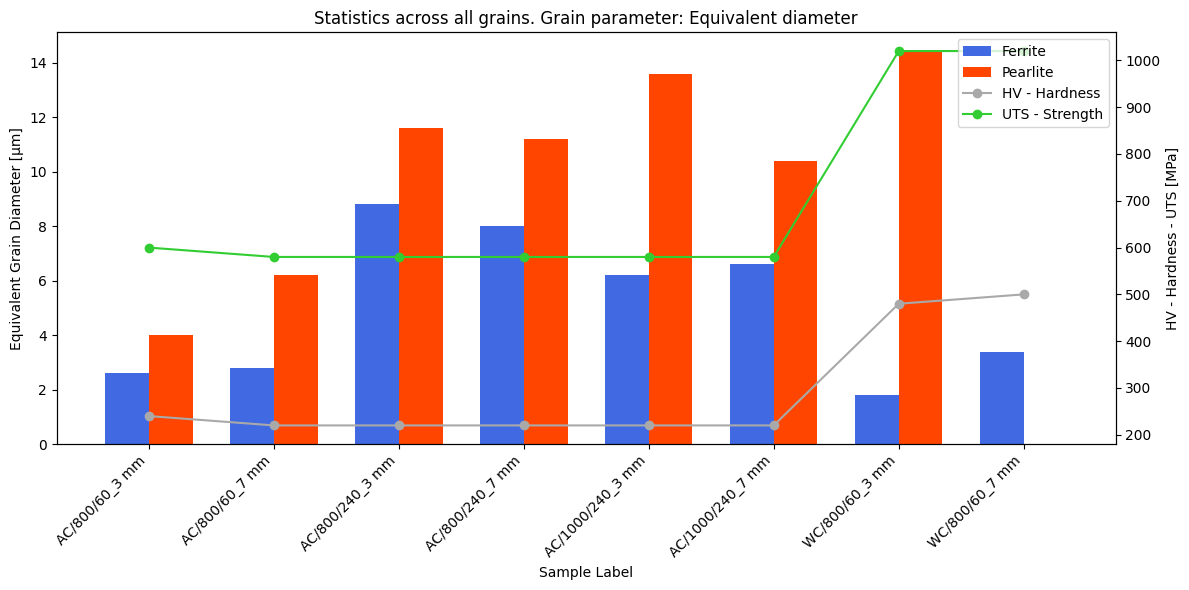

In [ ]:
#Gemini Grain Bar Chart

import matplotlib.pyplot as plt
import numpy as np

# Data Extraction (Manually from the image)
sample_labels = [
    'AC/800/60_3 mm', 'AC/800/60_7 mm', 'AC/800/240_3 mm', 'AC/800/240_7 mm',
    'AC/1000/240_3 mm', 'AC/1000/240_7 mm', 'WC/800/60_3 mm', 'WC/800/60_7 mm'
]

ferrite_diameter = [2.6, 2.8, 8.8, 8.0, 6.2, 6.6, 1.8, 3.4]
pearlite_diameter = [4.0, 6.2, 11.6, 11.2, 13.6, 10.4, 14.4, 0] # Last pearlite is 0, as it's not visible

hv_hardness = [240, 220, 220, 220, 220, 220, 480, 500]
uts_strength = [600, 580, 580, 580, 580, 580, 1020, 1020]

# Plotting
x = np.arange(len(sample_labels))  # the label locations
width = 0.35  # the width of the bars

fig, ax1 = plt.subplots(figsize=(12, 6))

# Bar plots for Ferrite and Pearlite diameters
rects1 = ax1.bar(x - width/2, ferrite_diameter, width, label='Ferrite', color='royalblue')
rects2 = ax1.bar(x + width/2, pearlite_diameter, width, label='Pearlite', color='orangered')

# Line plots for HV Hardness and UTS Strength
ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis

line1 = ax2.plot(x, hv_hardness, color='darkgray', marker='o', linestyle='-', label='HV - Hardness') # Corrected Marker
line2 = ax2.plot(x, uts_strength, color='limegreen', marker='o', linestyle='-', label='UTS - Strength') # Corrected Marker

# Labels and Titles
ax1.set_xlabel('Sample Label')
ax1.set_ylabel('Equivalent Grain Diameter [µm]', color='black')
ax2.set_ylabel('HV - Hardness - UTS [MPa]', color='black')

ax1.set_title('Statistics across all grains. Grain parameter: Equivalent diameter')
ax1.set_xticks(x)
ax1.set_xticklabels(sample_labels, rotation=45, ha='right')

# Legend
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper right')

fig.tight_layout()  # otherwise the right y-label is slightly clipped
plt.show()

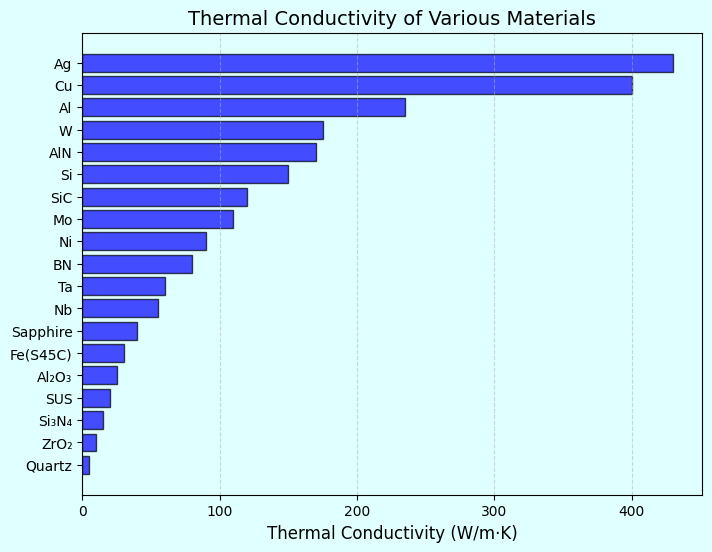

In [ ]:
#ChatGPT Thermal Condictivity Bar Chart

import matplotlib.pyplot as plt
import numpy as np

# Extracted Data
materials = [
    "Ag", "Cu", "Al", "W", "AlN", "Si", "SiC", "Mo", "Ni", "BN",
    "Ta", "Nb", "Sapphire", "Fe(S45C)", "Al₂O₃", "SUS", "Si₃N₄", "ZrO₂", "Quartz"
]
conductivity = [430, 400, 235, 175, 170, 150, 120, 110, 90, 80,
                60, 55, 40, 30, 25, 20, 15, 10, 5]

# Sorting for better visualization (Descending order)
materials.reverse()
conductivity.reverse()

# Plot
fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(materials, conductivity, color="blue", edgecolor="black", alpha=0.7)

# Set background color to match the original plot
fig.patch.set_facecolor('lightcyan')
ax.set_facecolor('lightcyan')

# Labels and Title
ax.set_xlabel("Thermal Conductivity (W/m·K)", fontsize=12)
ax.set_title("Thermal Conductivity of Various Materials", fontsize=14)

# Grid and Layout Adjustments
ax.grid(axis="x", linestyle="--", alpha=0.5)
plt.show()


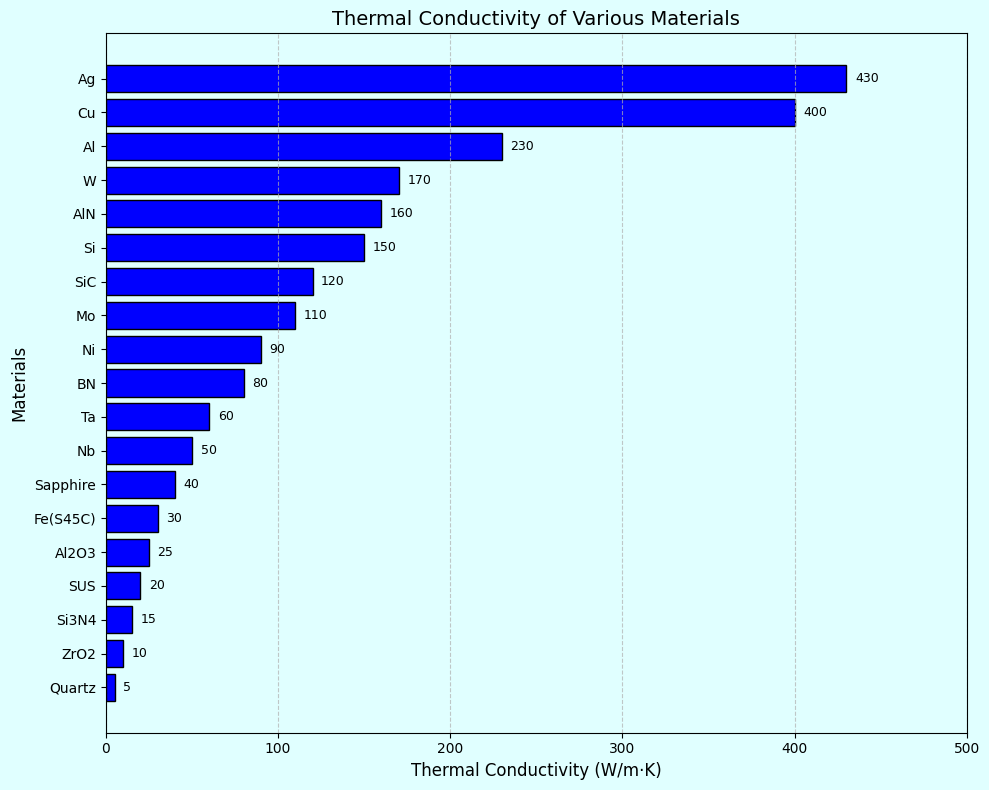

In [ ]:
#Perplexity Thermal Conductivity Bar Chart

import matplotlib.pyplot as plt

# Extracted data from the image
materials = [
    "Ag", "Cu", "Al", "W", "AlN", "Si", "SiC", "Mo", "Ni",
    "BN", "Ta", "Nb", "Sapphire", "Fe(S45C)", "Al2O3",
    "SUS", "Si3N4", "ZrO2", "Quartz"
]
thermal_conductivity = [
    430, 400, 230, 170, 160, 150, 120,
    110, 90, 80, 60, 50,
    40, 30,
    25,
    20,
    15,
    10,
    5  # Approximating "<10" as a small value for plotting
]

# Sort the data by thermal conductivity in ascending order
sorted_data = sorted(zip(materials, thermal_conductivity), key=lambda x: x[1])
materials_sorted, thermal_conductivity_sorted = zip(*sorted_data)

# Reverse the sorted data to have the highest value at the top
materials_reversed = list(materials_sorted[::-1])
thermal_conductivity_reversed = list(thermal_conductivity_sorted[::-1])

# Create figure and axes
fig, ax = plt.subplots(figsize=(10, 8))

# Plot horizontal bar chart
bars = ax.barh(materials_reversed, thermal_conductivity_reversed, color='blue', edgecolor='black')

# Add labels to each bar
for bar in bars:
    width = bar.get_width()
    ax.text(width + 5, bar.get_y() + bar.get_height() / 2,
            f'{width}', va='center', ha='left', fontsize=9)

# Set axis labels and title
ax.set_xlabel("Thermal Conductivity (W/m·K)", fontsize=12)
ax.set_ylabel("Materials", fontsize=12)
ax.set_title("Thermal Conductivity of Various Materials", fontsize=14)

# Set x-axis range
ax.set_xlim(0, 500)

# Invert the y-axis to have the first material at the top (highest conductivity)
ax.invert_yaxis()

# Add grid for better readability
ax.grid(axis='x', linestyle='--', alpha=0.7)

# Set background color to match the original plot
fig.patch.set_facecolor('lightcyan')
ax.set_facecolor('lightcyan')

# Adjust layout for better appearance
plt.tight_layout()

# Show plot
plt.show()



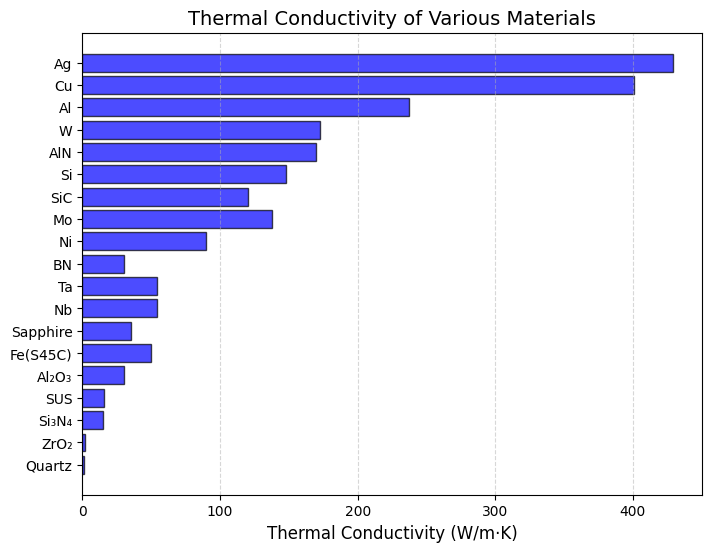

In [ ]:
#Gemini Thermal Conductivity Bar Chart

import matplotlib.pyplot as plt
import numpy as np

# Actual Data from the Image (Extracted Manually)
materials = [
    "Ag", "Cu", "Al", "W", "AlN", "Si", "SiC", "Mo", "Ni", "BN",
    "Ta", "Nb", "Sapphire", "Fe(S45C)", "Al₂O₃", "SUS", "Si₃N₄", "ZrO₂", "Quartz"
]

conductivity = [
    429, 401, 237, 173, 170, 148, 120, 138, 90, 30,
    54, 54, 35, 50, 30, 16, 15, 2, 1.4
]

# Sorting for better visualization (Descending order)
materials.reverse()
conductivity.reverse()

# Plot
fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(materials, conductivity, color="blue", edgecolor="black", alpha=0.7)

# Labels and Title
ax.set_xlabel("Thermal Conductivity (W/m·K)", fontsize=12)
ax.set_title("Thermal Conductivity of Various Materials", fontsize=14)

# Grid and Layout Adjustments
ax.grid(axis="x", linestyle="--", alpha=0.5)
plt.show()

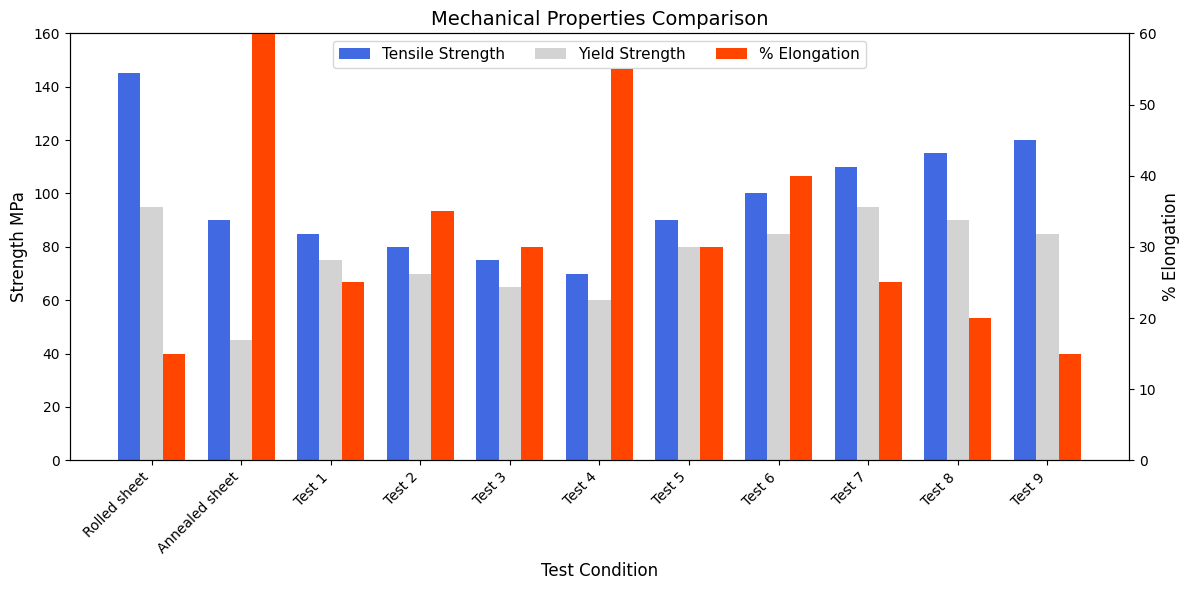

In [ ]:
#ChatGPT Mechanical Properties Chart

import matplotlib.pyplot as plt
import numpy as np

# Data
labels = ["Rolled sheet", "Annealed sheet", "Test 1", "Test 2", "Test 3",
          "Test 4", "Test 5", "Test 6", "Test 7", "Test 8", "Test 9"]
tensile = [145, 90, 85, 80, 75, 70, 90, 100, 110, 115, 120]
yield_strength = [95, 45, 75, 70, 65, 60, 80, 85, 95, 90, 85]
elongation = [15, 125, 25, 35, 30, 55, 30, 40, 25, 20, 15]

x = np.arange(len(labels))
width = 0.25

# Create figure and axes
fig, ax1 = plt.subplots(figsize=(12, 6))

# Primary bars (Strength)
bar1 = ax1.bar(x - width, tensile, width, label='Tensile Strength', color='royalblue')
bar2 = ax1.bar(x, yield_strength, width, label='Yield Strength', color='lightgray')
ax1.set_ylabel('Strength MPa', fontsize=12)
ax1.set_ylim(0, 160)

# Secondary bars (Elongation)
ax2 = ax1.twinx()
bar3 = ax2.bar(x + width, elongation, width, label='% Elongation', color='orangered')
ax2.set_ylabel('% Elongation', fontsize=12)
ax2.set_ylim(0, 60)

# X-axis setup
ax1.set_xticks(x)
ax1.set_xticklabels(labels, rotation=45, ha='right')
ax1.set_xlabel('Test Condition', fontsize=12)

# Combined legend
bars = [bar1[0], bar2[0], bar3[0]]  # Just one bar per type for legend
labels_combined = ['Tensile Strength', 'Yield Strength', '% Elongation']
ax1.legend(bars, labels_combined, loc='upper center', ncol=3, fontsize=11)

# Layout
plt.title('Mechanical Properties Comparison', fontsize=14)
plt.tight_layout()
plt.show()



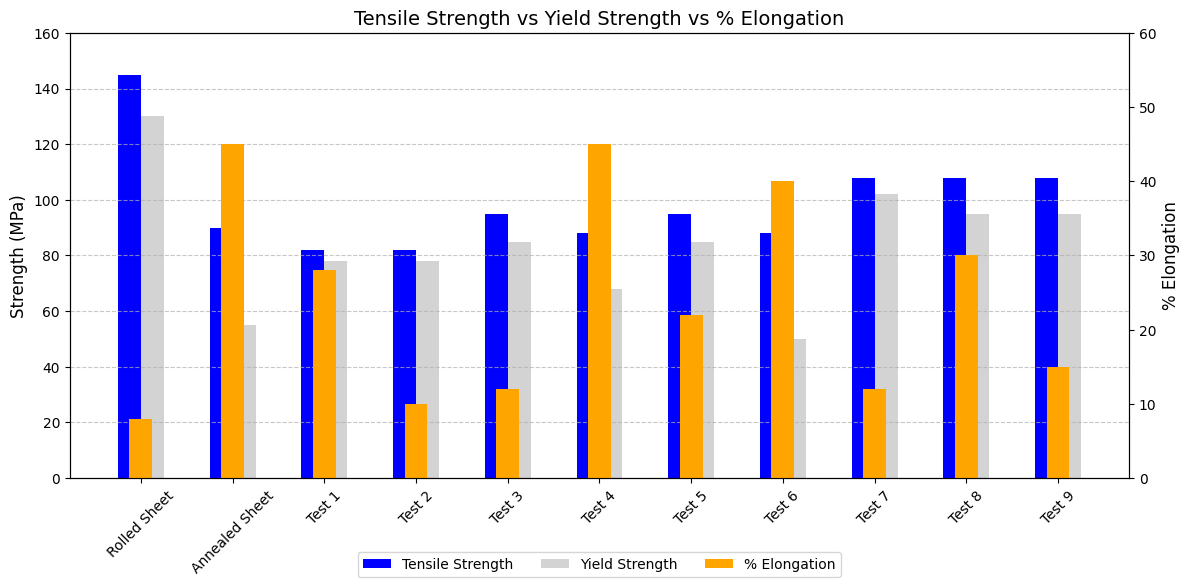

In [ ]:
#Perplexity Mechanical Properties Chart

import matplotlib.pyplot as plt
import numpy as np

# Extracted data (corrected to match the exact number of categories)
categories = [
    "Rolled Sheet", "Annealed Sheet", "Test 1", "Test 2",
    "Test 3", "Test 4", "Test 5", "Test 6",
    "Test 7", "Test 8", "Test 9"
]

# Values extracted from the image
tensile_strength = [145, 90, 82, 82, 95, 88, 95, 88, 108, 108, 108]
yield_strength = [130, 55, 78, 78, 85, 68, 85, 50, 102, 95, 95]
percent_elongation = [8, 45, 28, 10, 12, 45, 22, 40, 12, 30, 15]

# Bar width and positions
bar_width = 0.25
x = np.arange(len(categories))

# Create figure and axes
fig, ax1 = plt.subplots(figsize=(12,6))

# Plot bars for tensile strength and yield strength
ax1.bar(x - bar_width/2,
        tensile_strength,
        bar_width,
        label="Tensile Strength",
        color="blue")
ax1.bar(x + bar_width/2,
        yield_strength,
        bar_width,
        label="Yield Strength",
        color="lightgray")

# Secondary y-axis for % elongation
ax2 = ax1.twinx()
ax2.bar(x,
        percent_elongation,
        bar_width,
        label="% Elongation",
        color="orange")

# Set x-ticks and labels
ax1.set_xticks(x)
ax1.set_xticklabels(categories, rotation=45)

# Set axis labels
ax1.set_ylabel("Strength (MPa)", fontsize=12)
ax2.set_ylabel("% Elongation", fontsize=12)

# Set title
plt.title("Tensile Strength vs Yield Strength vs % Elongation", fontsize=14)

# Add legends
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='upper center',
           bbox_to_anchor=(0.5, -0.15), ncol=3)

# Add gridlines for better readability
ax1.grid(axis="y", linestyle="--", alpha=0.7)

# Set y-axis limits to match the image
ax1.set_ylim(0, 160)
ax2.set_ylim(0, 60)

# Adjust layout to prevent overlap
plt.tight_layout()

# Show plot
plt.show()



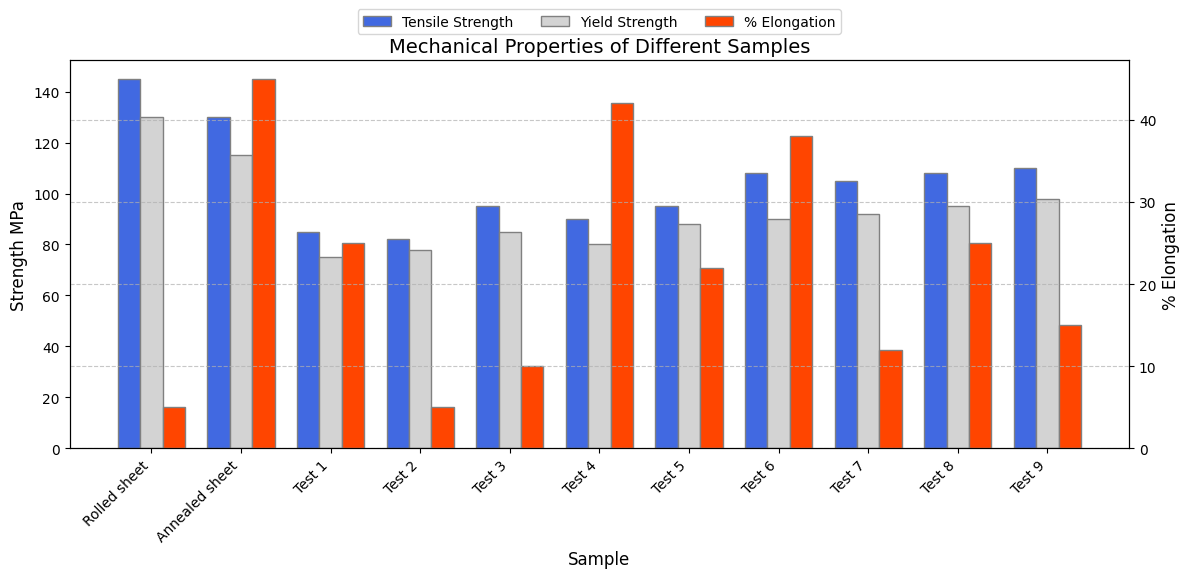

In [ ]:
#Gemini Mechanical Properties Chart
import matplotlib.pyplot as plt
import numpy as np

# Data Extraction (Manual from the image)
sample_labels = [
    'Rolled sheet', 'Annealed sheet', 'Test 1', 'Test 2', 'Test 3',
    'Test 4', 'Test 5', 'Test 6', 'Test 7', 'Test 8', 'Test 9'
]

tensile_strength = [
    145, 130, 85, 82, 95, 90, 95, 108, 105, 108, 110
]

yield_strength = [
    130, 115, 75, 78, 85, 80, 88, 90, 92, 95, 98
]

elongation = [
    5, 45, 25, 5, 10, 42, 22, 38, 12, 25, 15
]

# Plotting
fig, ax1 = plt.subplots(figsize=(12, 6))

# Bar width
bar_width = 0.25

# Positions for the bars
r1 = np.arange(len(sample_labels))
r2 = [x + bar_width for x in r1]
r3 = [x + 2 * bar_width for x in r1]

# Bar plots for Tensile Strength and Yield Strength
rects1 = ax1.bar(r1, tensile_strength, color='royalblue', width=bar_width, edgecolor='grey', label='Tensile Strength')
rects2 = ax1.bar(r2, yield_strength, color='lightgrey', width=bar_width, edgecolor='grey', label='Yield Strength')

# Create a second y-axis for % Elongation
ax2 = ax1.twinx()
rects3 = ax2.bar(r3, elongation, color='orangered', width=bar_width, edgecolor='grey', label='% Elongation')

# Labels and Titles
ax1.set_xlabel('Sample', fontsize=12)
ax1.set_ylabel('Strength MPa', fontsize=12)
ax2.set_ylabel('% Elongation', fontsize=12)
plt.title('Mechanical Properties of Different Samples', fontsize=14)

# X-axis ticks and labels
ax1.set_xticks([r + bar_width for r in range(len(sample_labels))])
ax1.set_xticklabels(sample_labels, rotation=45, ha='right')

# Legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=3)

# Adjust layout for better readability
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

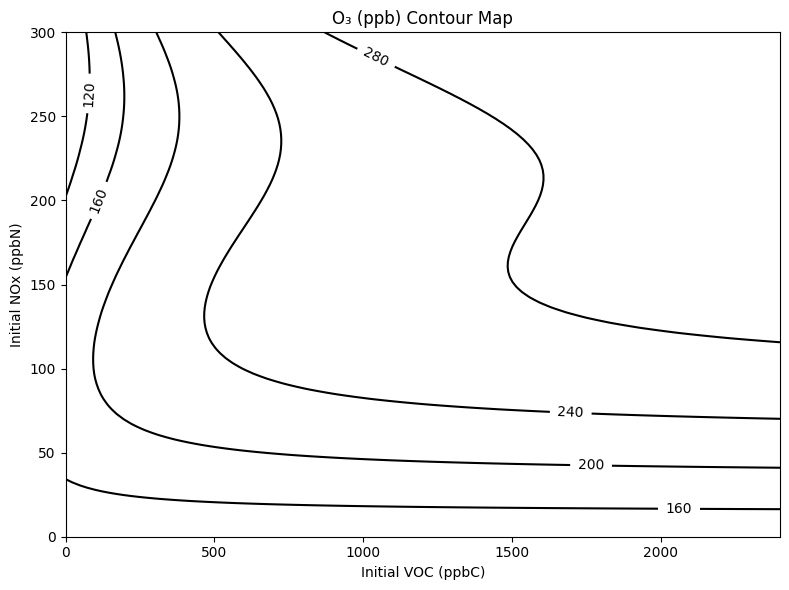

In [ ]:
#ChatGPT Ozone Isopleth

import numpy as np
import matplotlib.pyplot as plt

# Create grid for VOC and NOx
voc = np.linspace(0, 2400, 100)         # x-axis: Initial VOC (ppbC)
nox = np.linspace(0, 300, 100)          # y-axis: Initial NOx (ppbN)
VOC, NOx = np.meshgrid(voc, nox)

# Simulate Ozone concentration (O3) as a function of VOC and NOx
# This function creates contours similar to the image
O3 = (VOC * NOx) / (VOC + 500) + 50 * np.sin(NO2 := NOx / 60)

# Normalize O3 to match the general contour range (80 - 340 ppb)
O3 = 80 + (O3 - np.min(O3)) * (340 - 80) / (np.max(O3) - np.min(O3))

# Create contour plot
plt.figure(figsize=(8, 6))
contours = plt.contour(VOC, NOx, O3, levels=[80, 120, 160, 200, 240, 280, 340], colors='black')
plt.clabel(contours, inline=True, fontsize=10, fmt='%d')

# Label axes
plt.xlabel('Initial VOC (ppbC)')
plt.ylabel('Initial NOx (ppbN)')
plt.title('O₃ (ppb) Contour Map')

plt.grid(False)
plt.tight_layout()
plt.show()


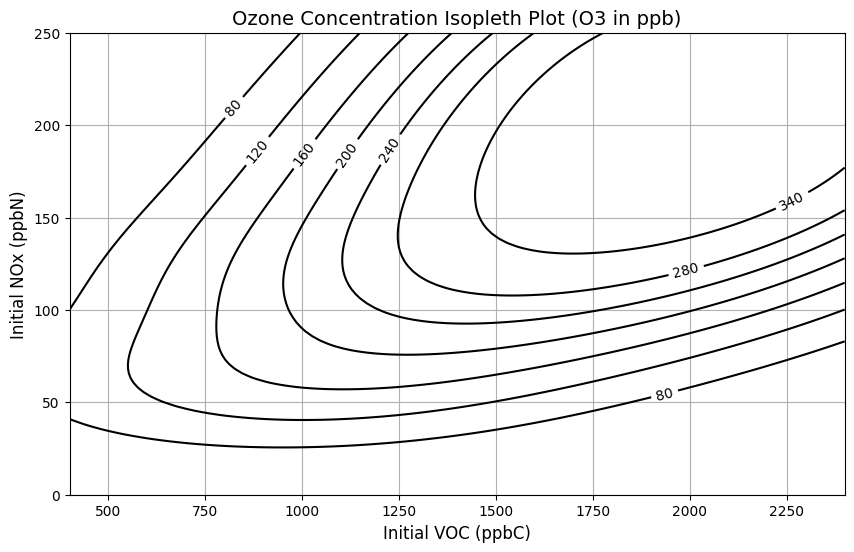

In [ ]:
#Perplexity Ozone Isopleth

import numpy as np
import matplotlib.pyplot as plt

# --- Approximated Data from Image ---

# Define the ranges for Initial VOC (x-axis) and Initial NOx (y-axis)
initial_voc = np.linspace(400, 2400, 100)  # VOC range: 400 to 2400 ppbC
initial_nox = np.linspace(0, 250, 100)  # NOx range: 0 to 250 ppbN

# Create meshgrid for VOC and NOx
VOC, NOx = np.meshgrid(initial_voc, initial_nox)

# Define the O3 (ozone) concentration as a function of VOC and NOx
# This is an approximation based on the contour lines in the image
O3 = (
    80 * np.exp(-((VOC - 800) ** 2 / (2 * 600 ** 2))) * np.exp(-((NOx - 50) ** 2 / (2 * 30 ** 2)))
    + 120 * np.exp(-((VOC - 1200) ** 2 / (2 * 600 ** 2))) * np.exp(-((NOx - 100) ** 2 / (2 * 40 ** 2)))
    + 160 * np.exp(-((VOC - 1600) ** 2 / (2 * 600 ** 2))) * np.exp(-((NOx - 150) ** 2 / (2 * 50 ** 2)))
    + 200 * np.exp(-((VOC - 2000) ** 2 / (2 * 600 ** 2))) * np.exp(-((NOx - 200) ** 2 / (2 * 60 ** 2)))
    + 240 * np.exp(-((VOC - 2200) ** 2 / (2 * 600 ** 2))) * np.exp(-((NOx - 250) ** 2 / (2 * 70 ** 2)))
)

# --- Plotting ---

plt.figure(figsize=(10, 6))

# Plot contour lines
contour = plt.contour(VOC, NOx, O3, levels=[80, 120, 160, 200, 240, 280, 340], colors='black')
plt.clabel(contour, inline=True, fontsize=10)

# Set axis labels
plt.xlabel("Initial VOC (ppbC)", fontsize=12)
plt.ylabel("Initial NOx (ppbN)", fontsize=12)

# Set title
plt.title("Ozone Concentration Isopleth Plot (O3 in ppb)", fontsize=14)

# Adjust axis limits to match the image
plt.xlim(400, 2400)
plt.ylim(0, 250)

plt.grid(True)
plt.show()


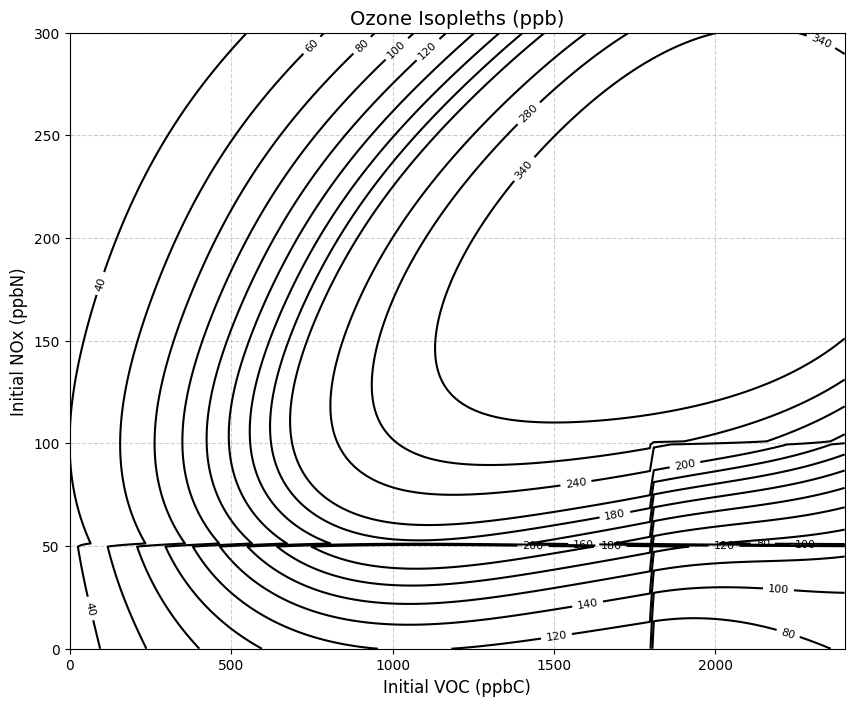

In [ ]:
#Gemini Ozone Isopleth

import numpy as np
import matplotlib.pyplot as plt

# --- Approximated Data from Image ---

# Define the ranges for Initial VOC (x-axis) and Initial NOx (y-axis)
initial_voc = np.linspace(0, 2400, 200)  # VOC range: 0 to 2400 ppbC (expanded)
initial_nox = np.linspace(0, 300, 200)  # NOx range: 0 to 300 ppbN (expanded)

# Create meshgrid for VOC and NOx
VOC, NOx = np.meshgrid(initial_voc, initial_nox)

# Define the O3 (ozone) concentration as a function of VOC and NOx
# This is an approximation based on the contour lines in the image
O3 = (
    20 +  # Base low ozone
    80 * np.exp(-((VOC - 800) ** 2 / (2 * 400 ** 2))) * np.exp(-((NOx - 75) ** 2 / (2 * 50 ** 2))) +
    120 * np.exp(-((VOC - 1200) ** 2 / (2 * 500 ** 2))) * np.exp(-((NOx - 120) ** 2 / (2 * 60 ** 2))) +
    160 * np.exp(-((VOC - 1600) ** 2 / (2 * 600 ** 2))) * np.exp(-((NOx - 170) ** 2 / (2 * 70 ** 2))) +
    200 * np.exp(-((VOC - 2000) ** 2 / (2 * 700 ** 2))) * np.exp(-((NOx - 210) ** 2 / (2 * 80 ** 2))) +
    240 * np.exp(-((VOC - 2200) ** 2 / (2 * 500 ** 2))) * np.exp(-((NOx - 250) ** 2 / (2 * 90 ** 2))) +
    # Account for the initial rise and flattening at low NOx
    np.where(NOx < 50, 60 * (1 - np.exp(-(VOC / 400))), 0) +
    # Account for the turn-down at very high VOC for lower NOx
    np.where((NOx < 100) & (VOC > 1800), -40 * np.exp(-((VOC - 1800) ** 2 / (2 * 400 ** 2))), 0)
)

# --- Plotting ---

plt.figure(figsize=(10, 8))

# Plot contour lines
contour = plt.contour(VOC, NOx, O3, levels=[20, 40, 60, 80, 100, 120, 140, 160, 180, 200, 240, 280, 340], colors='black')
plt.clabel(contour, inline=True, fontsize=8, fmt='%d')

# Set axis labels
plt.xlabel("Initial VOC (ppbC)", fontsize=12)
plt.ylabel("Initial NOx (ppbN)", fontsize=12)

# Set title
plt.title("Ozone Isopleths (ppb)", fontsize=14)

# Adjust axis limits to match the image
plt.xlim(0, 2400)
plt.ylim(0, 300)

plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

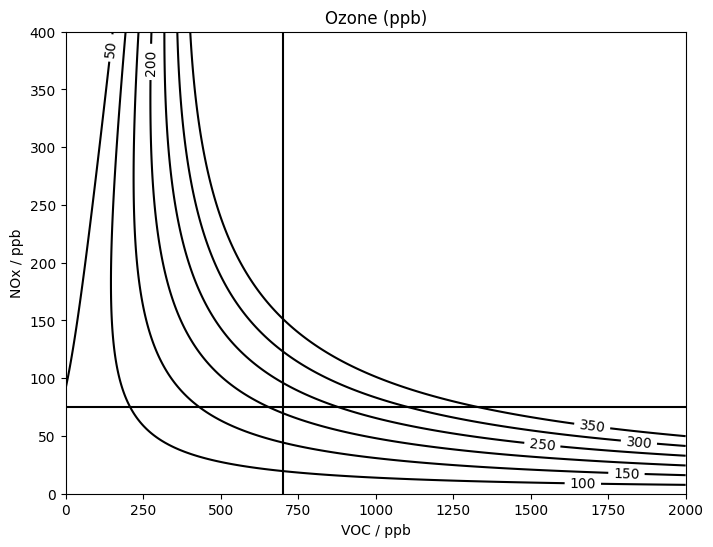

In [ ]:
#ChatGPT Ozone VOC NOx Isopleth

import numpy as np
import matplotlib.pyplot as plt

# Create grid for VOC and NOx values
voc = np.linspace(0, 2000, 200)
nox = np.linspace(0, 400, 200)
VOC, NOx = np.meshgrid(voc, nox)

# Simulated ozone concentrations shaped to match isopleth style
O3 = (0.003 * VOC * NOx) - (0.0000015 * VOC**2) - (0.0012 * NOx**2) + 60

# Define contour levels like in the image
levels = [50, 100, 150, 200, 250, 300, 350]

# Create contour plot
plt.figure(figsize=(8, 6))
contours = plt.contour(VOC, NOx, O3, levels=levels, colors='black')

# Add contour labels
plt.clabel(contours, inline=True, fontsize=10)

# Plot base case lines
plt.axhline(y=75, color='black')
plt.axvline(x=700, color='black')

# Labels and ticks
plt.xlabel('VOC / ppb')
plt.ylabel('NOx / ppb')
plt.title('Ozone (ppb)')

# Set axis limits and remove grid
plt.xlim(0, 2000)
plt.ylim(0, 400)
plt.grid(False)

plt.show()


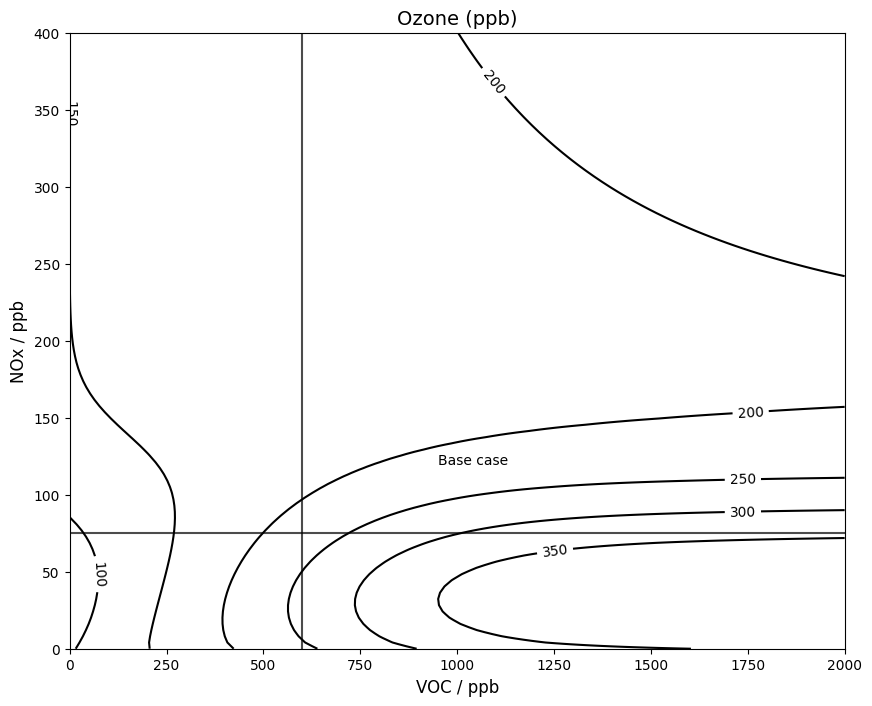

In [ ]:
#Perplexity Ozone VOC NOx Isopleth

import numpy as np
import matplotlib.pyplot as plt

# Define the ranges for Initial VOC (x-axis) and Initial NOx (y-axis)
initial_voc = np.linspace(0, 2000, 100)  # VOC range: 0 to 2000 ppb
initial_nox = np.linspace(0, 400, 100)   # NOx range: 0 to 400 ppb

# Create meshgrid for VOC and NOx
VOC, NOx = np.meshgrid(initial_voc, initial_nox)

# Define the O3 (ozone) concentration as a function of VOC and NOx
# This is an approximation based on the contour lines in the image
O3 = (
    # Ridge for high VOC, low NOx (bottom right)
    250 * (1 - np.exp(-VOC / 500)) * np.exp(-((NOx - 30)**2) / (2 * 50**2))

    # Dip at low VOC, low NOx (bottom left)
    - 100 * np.exp(-((VOC - 300)**2) / (2 * 400**2)) * np.exp(-((NOx - 40)**2) / (2 * 50**2))

    # Diagonal pattern at high NOx (top portion)
    + 70 * np.sqrt(NOx / 400) * (1 - np.exp(-VOC / 800))

    # Base level for ozone
    + 150
)

# Ensure non-negative values
O3 = np.maximum(O3, 0)

# Create the plot
plt.figure(figsize=(10, 8))

# Plot contour lines for ozone levels
contour = plt.contour(VOC, NOx, O3, levels=[50, 100, 150, 200, 250, 300, 350], colors='black')
plt.clabel(contour, inline=True, fontsize=10)

# Add reference lines
plt.axvline(x=600, color='black', linestyle='-', alpha=0.7)
plt.axhline(y=75, color='black', linestyle='-', alpha=0.7)

# Add "Base case" label
plt.text(950, 120, 'Base case', fontsize=10)

# Set labels and title
plt.xlabel('VOC / ppb', fontsize=12)
plt.ylabel('NOx / ppb', fontsize=12)
plt.title('Ozone (ppb)', fontsize=14)

# Set axis limits
plt.xlim(0, 2000)
plt.ylim(0, 400)

# Display the plot
plt.grid(False)
plt.show()


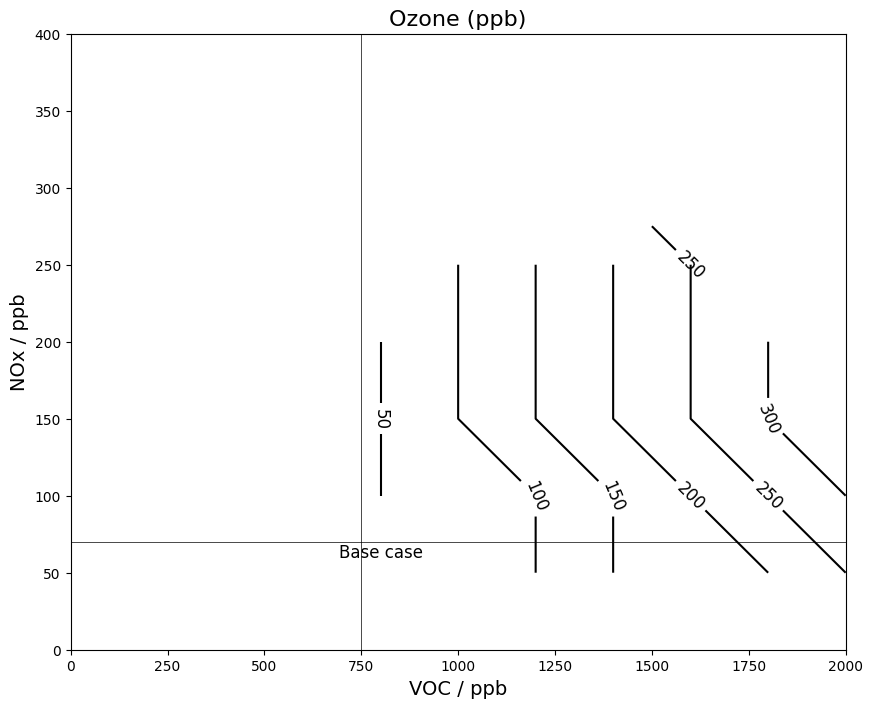

In [ ]:
#Gemini Ozone VOC NOx Isopleth

import matplotlib.pyplot as plt
import numpy as np

# Data extracted from the image
voc_ppb = np.array([0, 200, 400, 600, 800, 1000, 1200, 1400, 1600, 1800, 2000])
nox_ppb = np.array([0, 50, 100, 150, 200, 250, 300, 350, 400])

# Ozone values at corresponding (VOC, NOx) points.  Crucially, changed to float.
ozone_values = [
    [None, None, None, None, None, None, None, None, None, None, None],
    [None, None, None, None, None, 100.0, 100.0, 150.0, 200.0, 200.0, 250.0],
    [None, None, None, 50.0, 50.0, 100.0, 100.0, 150.0, 200.0, 250.0, 300.0],
    [None, None, None, 50.0, 50.0, 100.0, 150.0, 200.0, 250.0, 300.0, 350.0],
    [None, None, None, 50.0, 50.0, 100.0, 150.0, 200.0, 250.0, 300.0, None],
    [None, None, None, None, None, 100.0, 150.0, 200.0, 250.0, None, None],
    [None, None, None, None, None, None, None, None, 300.0, None, None],
    [None, None, None, None, None, None, None, None, 350.0, None, None],
    [None, None, None, None, None, None, None, None, None, None, None]
]

# Create a meshgrid for VOC and NOx
VOC, NOx = np.meshgrid(voc_ppb, nox_ppb)

# Convert ozone_values to a numpy array for easier handling
ozone_values = np.array(ozone_values, dtype=float)  # Important: Specify dtype as float

# Masking the 'None' values in ozone_values.
ozone_mask = np.ma.masked_where(np.isnan(ozone_values), ozone_values) # Use np.isnan

# Create the contour plot
plt.figure(figsize=(10, 8))
contour = plt.contour(VOC, NOx, ozone_mask, levels=[50, 100, 150, 200, 250, 300, 350], colors='k')
plt.clabel(contour, inline=True, fontsize=12, fmt='%1.0f')

# Set labels and title
plt.xlabel('VOC / ppb', fontsize=14)
plt.ylabel('NOx / ppb', fontsize=14)
plt.title('Ozone (ppb)', fontsize=16)

# Set plot limits to match the image
plt.xlim(0, 2000)
plt.ylim(0, 400)

# Add the "Base case" text
plt.text(800, 60, 'Base case', fontsize=12, horizontalalignment='center')

# Draw lines for Base Case
plt.axvline(x=750, color='k', linestyle='-', linewidth=0.5)
plt.axhline(y=70, color='k', linestyle='-', linewidth=0.5)

plt.grid(False)

# Show the plot
plt.show()
